

**Dyad-Specific Multimodal Affective Dynamics: Integrating Temporal Synchrony and Probabilistic Consistency**




In [ ]:
#@title 00. Install dependencies and the official Seamless Interaction package
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/seamless_interaction_repo')
if not REPO.exists():
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        'https://github.com/facebookresearch/seamless_interaction.git',
        str(REPO),
    ])

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO)])
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib',
    'tqdm', 'joblib', 'soundfile', 'requests', 'huggingface_hub',
])

SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Official files can contain trusted NumPy object arrays.
fs_file = SRC / 'seamless_interaction' / 'fs.py'
if fs_file.exists():
    text = fs_file.read_text(encoding='utf-8')
    old = 'data = np.load(tmp_file_path)'
    new = 'data = np.load(tmp_file_path, allow_pickle=True)'
    if old in text and new not in text:
        fs_file.write_text(text.replace(old, new), encoding='utf-8')
        print('Patched the official loader for trusted object arrays.')

print('Installation ready.')


Patched the official loader for trusted object arrays.
Installation ready.


In [ ]:
#@title 01. Imports and global configuration
from __future__ import annotations

import copy, json, math, random, re, shutil, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist, jensenshannon
from scipy.stats import wilcoxon, binomtest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    silhouette_score, adjusted_rand_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from seamless_interaction.fs import SeamlessInteractionFS, DatasetConfig

warnings.filterwarnings('ignore', category=RuntimeWarning)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

@dataclass
class Config:
    # Primary corpus
    label: str = 'improvised'
    split: str = 'dev'
    n_pairs: int = 30
    preferred_vendors_only: bool = True
    num_workers: int = 1

    # Windowing
    assumed_fps: float = 30.0
    window_seconds: float = 2.0
    stride_seconds: float = 0.5
    min_valid_fraction: float = 0.70

    # Main model
    selected_k: int = 3
    crossfit_folds: int = 5
    primary_group_column: str = 'pair_id'

    # PMCI
    pmci_k: int = 16
    pmci_tau: float = 0.25
    pmci_hidden: int = 96
    pmci_embed: int = 96
    pmci_epochs: int = 12
    pmci_batch_size: int = 64
    pmci_lr: float = 1e-3
    pmci_weight_decay: float = 1e-4
    pmci_window_frames: int = 12
    pmci_stride_frames: int = 12
    pmci_test_fraction: float = 0.30

    # Precursor analysis
    precursor_seconds: tuple = (2.0, 4.0, 6.0, 8.0)
    min_event_separation_seconds: float = 8.0
    bootstrap_iterations: int = 5000

    # Naturalistic transfer
    run_naturalistic_transfer: bool = True
    transfer_label: str = 'naturalistic'
    transfer_split: str = 'dev'
    transfer_n_pairs: int = 20

    random_state: int = SEED

CFG = Config()

ROOT = Path('/content/article3_q1_additional_experiments')
DATA_ROOT = ROOT / 'data_improvised'
TRANSFER_ROOT = ROOT / 'data_naturalistic'
PROCESSED = ROOT / 'processed'
RESULTS = ROOT / 'results'
MODELS = ROOT / 'models'
FIGURES = ROOT / 'figures'
for p in [ROOT, DATA_ROOT, TRANSFER_ROOT, PROCESSED, RESULTS, MODELS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(json.dumps(asdict(CFG), indent=2, default=list))
print('Device:', DEVICE)
print('Outputs:', ROOT)


{
  "label": "improvised",
  "split": "dev",
  "n_pairs": 30,
  "preferred_vendors_only": true,
  "num_workers": 1,
  "assumed_fps": 30.0,
  "window_seconds": 2.0,
  "stride_seconds": 0.5,
  "min_valid_fraction": 0.7,
  "selected_k": 3,
  "crossfit_folds": 5,
  "primary_group_column": "pair_id",
  "pmci_k": 16,
  "pmci_tau": 0.25,
  "pmci_hidden": 96,
  "pmci_embed": 96,
  "pmci_epochs": 12,
  "pmci_batch_size": 64,
  "pmci_lr": 0.001,
  "pmci_weight_decay": 0.0001,
  "pmci_window_frames": 12,
  "pmci_stride_frames": 12,
  "pmci_test_fraction": 0.3,
  "precursor_seconds": [
    2.0,
    4.0,
    6.0,
    8.0
  ],
  "min_event_separation_seconds": 8.0,
  "bootstrap_iterations": 5000,
  "run_naturalistic_transfer": true,
  "transfer_label": "naturalistic",
  "transfer_split": "dev",
  "transfer_n_pairs": 20,
  "random_state": 42
}
Device: cuda
Outputs: /content/article3_q1_additional_experiments


## 02. Download and identity-aware dataset preparation


In [ ]:
#@title 02A. Reusable official downloader

def download_complete_pairs(label: str, split: str, n_pairs: int, root: Path, seed: int):
    config = DatasetConfig(
        label=label,
        split=split,
        preferred_vendors_only=CFG.preferred_vendors_only,
        local_dir=root,
        seed=seed,
        num_workers=CFG.num_workers,
    )
    fs = SeamlessInteractionFS(config=config)
    pairs = fs.get_interaction_pairs(num_pairs=n_pairs)
    if not pairs:
        raise RuntimeError(f'No interaction pairs found for {label}/{split}.')

    ok, failed = [], []
    file_ids = [fid for pair in pairs for fid in pair]
    for fid in tqdm(file_ids, desc=f'Download {label}/{split}'):
        try:
            fs.gather_file_id_data_from_s3(
                fid, num_workers=CFG.num_workers, local_dir=root
            )
            ok.append(fid)
        except Exception as exc:
            failed.append({'file_id': fid, 'error': f'{type(exc).__name__}: {exc}'})

    print(f'{label}/{split}: requested={len(file_ids)}, downloaded={len(ok)}, failed={len(failed)}')
    if failed:
        display(pd.DataFrame(failed).head(20))
    return fs, pairs, pd.DataFrame(failed)

primary_fs, primary_pairs, primary_download_failures = download_complete_pairs(
    CFG.label, CFG.split, CFG.n_pairs, DATA_ROOT, CFG.random_state
)


Download improvised/dev:   0%|          | 0/60 [00:00<?, ?it/s]

improvised/dev: requested=60, downloaded=60, failed=0


In [ ]:
#@title 02B. Manifest and identity helpers

def find_local_file(file_id: str, suffix: str, root: Path) -> Optional[Path]:
    matches = list(root.rglob(f'{file_id}{suffix}'))
    return matches[0] if matches else None


def interaction_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:-1])


def participant_id_from_file_id(file_id: str) -> str:
    match = re.search(r'_(P[^_]+)$', file_id)
    if match is None:
        raise ValueError(f'Cannot parse participant ID from {file_id}')
    return match.group(1)


def session_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:2])


def prompt_id_from_file_id(file_id: str) -> str:
    parts = file_id.split('_')
    return parts[2] if len(parts) >= 3 else 'unknown'


def canonical_pair_id(participants) -> str:
    return '__'.join(sorted({str(x) for x in participants if pd.notna(x)}))


def build_raw_manifest(pairs, root: Path, label: str, split: str) -> pd.DataFrame:
    rows = []
    for pair_idx, pair in enumerate(pairs):
        pair_id = canonical_pair_id(participant_id_from_file_id(fid) for fid in pair)
        for fid in pair:
            row = {
                'pair_idx': pair_idx,
                'dataset_label': label,
                'dataset_split': split,
                'interaction_key': interaction_key_from_file_id(fid),
                'recording_session_id': session_key_from_file_id(fid),
                'interaction_prompt_id': prompt_id_from_file_id(fid),
                'participant_id': participant_id_from_file_id(fid),
                'pair_id': pair_id,
                'file_id': fid,
            }
            for suffix, name in [('.npz','npz_path'),('.json','json_path'),('.mp4','mp4_path'),('.wav','wav_path')]:
                path = find_local_file(fid, suffix, root)
                row[name] = str(path) if path else None
            rows.append(row)
    return pd.DataFrame(rows)

manifest_all = build_raw_manifest(primary_pairs, DATA_ROOT, CFG.label, CFG.split)
display(manifest_all.head())


,pair_idx,dataset_label,dataset_split,interaction_key,recording_session_id,interaction_prompt_id,participant_id,pair_id,file_id,npz_path,json_path,mp4_path,wav_path
0,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0799,P0299A__P0799,V00_S0644_I00000770_P0799,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
1,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0299A,P0299A__P0799,V00_S0644_I00000770_P0299A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
2,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1316,P1316__P1317,V01_S0172_I00001224_P1316,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
3,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1317,P1316__P1317,V01_S0172_I00001224_P1317,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
4,2,improvised,dev,V00_S2025_I00001082,V00_S2025,I00001082,P1281A,P1281A__P1282A,V00_S2025_I00001082_P1281A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...


In [ ]:
#@title 02C. Feature inventory and identity graph
FACE_KEYS = [
    'movement_v4:FAUValue', 'movement:FAUValue',
    'movement_v4:expression', 'movement:expression',
    'movement_v4:frame_latent', 'movement:frame_latent',
]
BODY_KEYS = ['boxes_and_keypoints:keypoints', 'smplh:body_pose']
AFFECT_SCORE_KEYS = ['movement_v4:emotion_scores', 'movement:emotion_scores']
VALENCE_KEYS = ['movement_v4:emotion_valence', 'movement:emotion_valence']
AROUSAL_KEYS = ['movement_v4:emotion_arousal', 'movement:emotion_arousal']
VALID_KEYS = ['movement_v4:is_valid', 'movement:is_valid', 'boxes_and_keypoints:is_valid_box']


def safe_numeric_array(npz, key):
    if key not in npz.files:
        return None
    try:
        arr = np.asarray(npz[key])
        if arr.size == 0 or arr.dtype == object:
            return None
        return arr
    except Exception:
        return None


def first_existing_numeric(npz, candidates):
    for key in candidates:
        arr = safe_numeric_array(npz, key)
        if arr is not None:
            return key, arr
    return None, None


class UnionFind:
    def __init__(self): self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.parent[rb] = ra


def prepare_identity_manifest(manifest_raw: pd.DataFrame):
    feature_rows = []
    for _, row in tqdm(manifest_raw.iterrows(), total=len(manifest_raw), desc='Feature inventory'):
        result = {'file_id': row.file_id, 'usable': False}
        if not row.npz_path:
            feature_rows.append(result); continue
        try:
            with np.load(row.npz_path, allow_pickle=True) as npz:
                face_key, face = first_existing_numeric(npz, FACE_KEYS)
                body_key, body = first_existing_numeric(npz, BODY_KEYS)
                affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
                valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
                arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
                valid_key, _ = first_existing_numeric(npz, VALID_KEYS)
            has_affect = affect is not None or (valence is not None and arousal is not None)
            result.update({
                'face_key': face_key, 'body_key': body_key, 'affect_key': affect_key,
                'valence_key': valence_key, 'arousal_key': arousal_key, 'valid_key': valid_key,
                'face_shape': None if face is None else str(face.shape),
                'body_shape': None if body is None else str(body.shape),
                'usable': face is not None and body is not None and has_affect,
            })
        except Exception as exc:
            result['error'] = f'{type(exc).__name__}: {exc}'
        feature_rows.append(result)

    inventory = pd.DataFrame(feature_rows)
    usable = manifest_raw[manifest_raw.file_id.isin(set(inventory.loc[inventory.usable, 'file_id']))].copy()
    counts = usable.groupby('interaction_key').agg(n_files=('file_id','nunique'), n_participants=('participant_id','nunique'))
    complete = counts.query('n_files == 2 and n_participants == 2').index
    manifest = usable[usable.interaction_key.isin(complete)].copy()

    verified_pairs = manifest.groupby('interaction_key')['participant_id'].agg(canonical_pair_id)
    manifest['pair_id'] = manifest.interaction_key.map(verified_pairs)

    uf = UnionFind()
    for _, g in manifest.groupby('interaction_key'):
        ids = sorted(g.participant_id.unique())
        if len(ids) == 2: uf.union(ids[0], ids[1])
    roots = {p: uf.find(p) for p in manifest.participant_id.unique()}
    root_names = {r: f'C{i:03d}' for i, r in enumerate(sorted(set(roots.values())))}
    manifest['participant_component'] = manifest.participant_id.map({p: root_names[r] for p,r in roots.items()})

    session_identity = manifest.groupby('interaction_key', as_index=False).agg(
        pair_id=('pair_id','first'),
        participant_component=('participant_component','first'),
        participant_A=('participant_id','min'), participant_B=('participant_id','max'),
        dataset_label=('dataset_label','first'), dataset_split=('dataset_split','first'),
    )
    return manifest, inventory, session_identity

manifest, feature_inventory, session_identity = prepare_identity_manifest(manifest_all)
if manifest.empty:
    raise RuntimeError('No complete usable sessions remain.')

identity_audit = pd.DataFrame([{
    'complete_sessions': manifest.interaction_key.nunique(),
    'unique_pairs': manifest.pair_id.nunique(),
    'unique_participants': manifest.participant_id.nunique(),
    'participant_components': manifest.participant_component.nunique(),
    'pairs_with_repeated_sessions': int((session_identity.groupby('pair_id').size() > 1).sum()),
}])
display(identity_audit)
display(session_identity.groupby('pair_id', as_index=False).agg(n_sessions=('interaction_key','nunique')).sort_values('n_sessions', ascending=False))

manifest.to_csv(PROCESSED/'primary_manifest.csv', index=False)
feature_inventory.to_csv(PROCESSED/'primary_feature_inventory.csv', index=False)
session_identity.to_csv(PROCESSED/'primary_session_identity.csv', index=False)


Feature inventory:   0%|          | 0/60 [00:00<?, ?it/s]

,complete_sessions,unique_pairs,unique_participants,participant_components,pairs_with_repeated_sessions
0,24,12,17,5,9


,pair_id,n_sessions
1,P0299A__P0801,3
11,P1346A__P1347A,3
9,P1281A__P1282A,3
2,P0383__P0731,2
8,P1275A__P1277A,2
6,P0844A__P0852,2
4,P0844A__P0845,2
5,P0844A__P0847,2
10,P1282A__P1347A,2
0,P0299A__P0799,1


## 03. Feature loading, CIAS and PMCI


In [ ]:
#@title 03A. Feature preprocessing and loader

def flatten_time_features(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1: x = x[:, None]
    elif x.ndim > 2: x = x.reshape(x.shape[0], -1)
    return x


def prepare_keypoints(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3 and x.shape[-1] >= 2:
        coords = x[..., :2]
        center = np.nanmedian(coords, axis=1, keepdims=True)
        coords = coords - center
        scale = np.nanmedian(np.linalg.norm(coords, axis=-1), axis=1, keepdims=True)
        scale = np.where(scale < 1e-6, 1.0, scale)
        coords = coords / scale[:, :, None]
        return coords.reshape(coords.shape[0], -1)
    return flatten_time_features(x)


def robust_standardize(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.nanmedian(x, axis=0, keepdims=True)
    mad = np.nanmedian(np.abs(x-med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return np.nan_to_num((x-med)/mad)


def align_min_length(**arrays):
    lengths = [len(a) for a in arrays.values() if a is not None]
    if not lengths: return arrays
    n = min(lengths)
    return {k: None if v is None else v[:n] for k,v in arrays.items()}


class SeamlessFeatureLoader:
    def load(self, npz_path: str) -> dict:
        with np.load(npz_path, allow_pickle=True) as npz:
            face_key, face = first_existing_numeric(npz, FACE_KEYS)
            body_key, body = first_existing_numeric(npz, BODY_KEYS)
            affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
            valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
            arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
            valid_key, valid = first_existing_numeric(npz, VALID_KEYS)
        if face is None or body is None:
            raise ValueError(f'Missing face/body features in {npz_path}')
        aligned = align_min_length(
            face=flatten_time_features(face), body=prepare_keypoints(body),
            affect=None if affect is None else flatten_time_features(affect),
            valence=None if valence is None else flatten_time_features(valence),
            arousal=None if arousal is None else flatten_time_features(arousal),
            valid=None if valid is None else flatten_time_features(valid),
        )
        aligned['keys'] = {'face':face_key,'body':body_key,'affect':affect_key,'valence':valence_key,'arousal':arousal_key,'valid':valid_key}
        return aligned

loader = SeamlessFeatureLoader()
print('Feature loader ready.')


Feature loader ready.


In [ ]:
#@title 03B. CIAS implementation used in the current Article 3 pipeline
class CIASReference:
    def _temporal_energy(self, x):
        x = flatten_time_features(x)
        if len(x) < 3: return np.zeros(max(len(x)-1, 1))
        dx = robust_standardize(np.diff(x, axis=0))
        return np.linalg.norm(dx, axis=1)

    def score(self, face_window, body_window):
        ef, eb = self._temporal_energy(face_window), self._temporal_energy(body_window)
        n = min(len(ef), len(eb)); ef, eb = ef[:n], eb[:n]
        if n < 4 or np.std(ef) < 1e-8 or np.std(eb) < 1e-8: return 0.5
        r = np.corrcoef(ef, eb)[0,1]
        return float(np.clip((r+1)/2, 0, 1))

cias_calculator = CIASReference()


In [ ]:
#@title 03C. PMCI K16 model and identity-disjoint training utilities
class PMCIModel(nn.Module):
    def __init__(self, face_dim, body_dim, hidden=96, embed=96, K=16, tau=0.25):
        super().__init__(); self.K=int(K); self.tau=float(tau)
        self.face_gru = nn.GRU(face_dim, hidden, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden, batch_first=True)
        self.face_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.body_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.prototypes = nn.Parameter(torch.randn(self.K, embed)*0.05)

    def encode(self, face, body):
        _, hf = self.face_gru(face); _, hb = self.body_gru(body)
        return F.normalize(self.face_proj(hf[-1]),dim=-1), F.normalize(self.body_proj(hb[-1]),dim=-1)

    def prototype_probabilities(self, face, body):
        zf, zb = self.encode(face, body)
        proto = F.normalize(self.prototypes, dim=-1)
        return F.softmax((zf@proto.T)/self.tau,dim=-1), F.softmax((zb@proto.T)/self.tau,dim=-1)

    def score(self, face, body):
        p,q = self.prototype_probabilities(face, body); m=0.5*(p+q); eps=1e-8
        jsd=0.5*(torch.sum(p*(torch.log(p+eps)-torch.log(m+eps)),dim=-1)+torch.sum(q*(torch.log(q+eps)-torch.log(m+eps)),dim=-1))
        return (1-jsd/math.log(2.0)).clamp(0,1)


def make_pmci_windows(manifest_df, window_frames, stride_frames):
    faces,bodies,groups,file_ids=[],[],[],[]
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc='PMCI windows'):
        try: data=loader.load(row.npz_path)
        except Exception as exc:
            print('Skip',row.file_id,type(exc).__name__,exc); continue
        face,body,valid=data['face'],data['body'],data.get('valid')
        n=min(len(face),len(body))
        for start in range(0,n-window_frames+1,stride_frames):
            end=start+window_frames
            if valid is not None and float(np.nanmean(valid[start:end])) < CFG.min_valid_fraction: continue
            fw,bw=face[start:end],body[start:end]
            if not np.isfinite(fw).all() or not np.isfinite(bw).all(): continue
            faces.append(fw); bodies.append(bw); groups.append(row.pair_id); file_ids.append(row.file_id)
    if not faces: raise RuntimeError('No PMCI windows were produced.')
    return {'face':np.stack(faces).astype('float32'),'body':np.stack(bodies).astype('float32'),'groups':np.asarray(groups),'file_ids':np.asarray(file_ids)}


def fit_standardizer(x):
    flat=x.reshape(-1,x.shape[-1]); mean=flat.mean(0,keepdims=True); std=flat.std(0,keepdims=True); std=np.where(std<1e-6,1,std)
    return mean.astype('float32'),std.astype('float32')


def apply_standardizer(x,mean,std): return ((x-mean[None,:,:])/std[None,:,:]).astype('float32')


def make_balanced_pairs(face, body, seed):
    rng=np.random.default_rng(seed); n=len(face); idx=np.arange(n); neg=rng.permutation(n)
    same=neg==idx
    if same.any(): neg[same]=np.roll(neg,1)[same]
    pf=np.concatenate([face,face]); pb=np.concatenate([body,body[neg]]); y=np.concatenate([np.ones(n),np.zeros(n)]).astype('float32')
    order=rng.permutation(len(y)); return pf[order],pb[order],y[order]


pmci_data = make_pmci_windows(manifest, CFG.pmci_window_frames, CFG.pmci_stride_frames)
indices=np.arange(len(pmci_data['face']))
splitter=GroupShuffleSplit(n_splits=1,test_size=CFG.pmci_test_fraction,random_state=CFG.random_state)
train_idx,test_idx=next(splitter.split(indices,groups=pmci_data['groups']))
assert set(pmci_data['groups'][train_idx]).isdisjoint(set(pmci_data['groups'][test_idx]))

face_mean,face_std=fit_standardizer(pmci_data['face'][train_idx]); body_mean,body_std=fit_standardizer(pmci_data['body'][train_idx])
face_all=apply_standardizer(pmci_data['face'],face_mean,face_std); body_all=apply_standardizer(pmci_data['body'],body_mean,body_std)
trf,trb,try_=make_balanced_pairs(face_all[train_idx],body_all[train_idx],CFG.random_state)
tef,teb,tey=make_balanced_pairs(face_all[test_idx],body_all[test_idx],CFG.random_state+100)

train_loader=DataLoader(TensorDataset(torch.from_numpy(trf),torch.from_numpy(trb),torch.from_numpy(try_)),batch_size=CFG.pmci_batch_size,shuffle=True)
pmci_model=PMCIModel(face_all.shape[-1],body_all.shape[-1],CFG.pmci_hidden,CFG.pmci_embed,CFG.pmci_k,CFG.pmci_tau).to(DEVICE)
optimizer=torch.optim.AdamW(pmci_model.parameters(),lr=CFG.pmci_lr,weight_decay=CFG.pmci_weight_decay)
best_state,best_loss=None,float('inf')
for epoch in range(1,CFG.pmci_epochs+1):
    pmci_model.train(); losses=[]
    for bf,bb,by in train_loader:
        bf,bb,by=bf.to(DEVICE),bb.to(DEVICE),by.to(DEVICE)
        score=pmci_model.score(bf,bb); loss=F.binary_cross_entropy(score.clamp(1e-5,1-1e-5),by)
        optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(pmci_model.parameters(),1.0); optimizer.step(); losses.append(float(loss.detach().cpu()))
    epoch_loss=float(np.mean(losses)); print(f'Epoch {epoch:02d}/{CFG.pmci_epochs}: loss={epoch_loss:.4f}')
    if epoch_loss<best_loss: best_loss=epoch_loss; best_state=copy.deepcopy(pmci_model.state_dict())
if best_state is not None: pmci_model.load_state_dict(best_state)
pmci_model.eval()

@torch.no_grad()
def pmci_predict(model,face,body,batch=256):
    out=[]
    for start in range(0,len(face),batch):
        f=torch.from_numpy(np.ascontiguousarray(face[start:start+batch])).to(DEVICE)
        b=torch.from_numpy(np.ascontiguousarray(body[start:start+batch])).to(DEVICE)
        out.append(model.score(f,b).cpu().numpy())
    return np.concatenate(out)

test_scores=pmci_predict(pmci_model,tef,teb)
pmci_metrics=pd.DataFrame([{
    'roc_auc':roc_auc_score(tey,test_scores),'pr_auc':average_precision_score(tey,test_scores),
    'accuracy':accuracy_score(tey,(test_scores>=.5).astype(int)),'f1':f1_score(tey,(test_scores>=.5).astype(int)),
    'matched_mean':float(test_scores[tey==1].mean()),'shuffled_mean':float(test_scores[tey==0].mean()),
    'train_pairs':len(set(pmci_data['groups'][train_idx])),'test_pairs':len(set(pmci_data['groups'][test_idx])),
}])
display(pmci_metrics.round(4))

PMCI_CHECKPOINT=MODELS/'pmci_K16_pair_disjoint.pt'
torch.save({'model_state_dict':pmci_model.state_dict(),'face_dim':face_all.shape[-1],'body_dim':body_all.shape[-1],
            'hidden':CFG.pmci_hidden,'embed':CFG.pmci_embed,'K':CFG.pmci_k,'tau':CFG.pmci_tau,
            'window_frames':CFG.pmci_window_frames,'face_mean':face_mean,'face_std':face_std,'body_mean':body_mean,'body_std':body_std,
            'metrics':pmci_metrics.iloc[0].to_dict()},PMCI_CHECKPOINT)
pmci_metrics.to_csv(RESULTS/'pmci_pair_disjoint_metrics.csv',index=False)
print('Saved:',PMCI_CHECKPOINT)


PMCI windows:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01/12: loss=0.5778
Epoch 02/12: loss=0.4571
Epoch 03/12: loss=0.4151
Epoch 04/12: loss=0.3892
Epoch 05/12: loss=0.3760
Epoch 06/12: loss=0.3651
Epoch 07/12: loss=0.3560
Epoch 08/12: loss=0.3496
Epoch 09/12: loss=0.3429
Epoch 10/12: loss=0.3371
Epoch 11/12: loss=0.3293
Epoch 12/12: loss=0.3248


,roc_auc,pr_auc,accuracy,f1,matched_mean,shuffled_mean,train_pairs,test_pairs
0,0.6876,0.6766,0.6484,0.6654,0.6722,0.4739,8,4


Saved: /content/article3_q1_additional_experiments/models/pmci_K16_pair_disjoint.pt


## 04. Build participant and dyadic CIAS–PMCI trajectories


In [ ]:
#@title 04A. Learned PMCI adapter and dynamic window generator

def resample_sequence(sequence,target_length):
    x=np.asarray(sequence,dtype='float32')
    if x.ndim!=2: x=x.reshape(x.shape[0],-1)
    if len(x)==target_length: return np.nan_to_num(x)
    if len(x)<2: return np.repeat(x[:1],target_length,axis=0)
    old=np.linspace(0,1,len(x)); new=np.linspace(0,1,target_length); out=np.empty((target_length,x.shape[1]),dtype='float32')
    for j in range(x.shape[1]):
        v=x[:,j]; finite=np.isfinite(v)
        out[:,j]=np.interp(new,old[finite],v[finite]) if finite.sum()>=2 else (np.nanmean(v) if finite.any() else 0.0)
    return np.nan_to_num(out)


class LearnedPMCIWindowCalculator:
    def __init__(self,model,input_frames,face_mean,face_std,body_mean,body_std):
        self.model=model; self.input_frames=input_frames
        self.face_mean=face_mean.reshape(1,-1); self.face_std=np.where(face_std.reshape(1,-1)<1e-6,1,face_std.reshape(1,-1))
        self.body_mean=body_mean.reshape(1,-1); self.body_std=np.where(body_std.reshape(1,-1)<1e-6,1,body_std.reshape(1,-1))
    @torch.no_grad()
    def score(self,face_window,body_window):
        f=(resample_sequence(face_window,self.input_frames)-self.face_mean)/self.face_std
        b=(resample_sequence(body_window,self.input_frames)-self.body_mean)/self.body_std
        ft=torch.from_numpy(np.ascontiguousarray(f[None],dtype='float32')).to(DEVICE)
        bt=torch.from_numpy(np.ascontiguousarray(b[None],dtype='float32')).to(DEVICE)
        return float(self.model.score(ft,bt).cpu().item())

learned_pmci=LearnedPMCIWindowCalculator(pmci_model,CFG.pmci_window_frames,face_mean,face_std,body_mean,body_std)


class Article3WindowGenerator:
    def __init__(self):
        self.window_frames=int(round(CFG.window_seconds*CFG.assumed_fps)); self.stride_frames=int(round(CFG.stride_seconds*CFG.assumed_fps))
    def transform(self,row,data):
        n=min(len(data['face']),len(data['body'])); rows=[]
        for start in range(0,n-self.window_frames+1,self.stride_frames):
            end=start+self.window_frames; fw=np.asarray(data['face'][start:end],dtype='float32'); bw=np.asarray(data['body'][start:end],dtype='float32')
            valid_fraction=1.0 if data['valid'] is None else float(np.nanmean(data['valid'][start:end]))
            if not np.isfinite(valid_fraction) or valid_fraction<CFG.min_valid_fraction: continue
            fw=np.nan_to_num(fw); bw=np.nan_to_num(bw)
            rows.append({'session_id':row.interaction_key,'file_id':row.file_id,'participant_id':row.participant_id,'pair_id':row.pair_id,
                         'participant_component':row.participant_component,'time_sec':start/CFG.assumed_fps,
                         'cias':cias_calculator.score(fw,bw),'pmci':learned_pmci.score(fw,bw),'valid_fraction':valid_fraction})
        return pd.DataFrame(rows)

article3_generator=Article3WindowGenerator()


In [ ]:
#@title 04B. Create primary dyadic state space

def build_dynamic_state_space(manifest_df: pd.DataFrame, description='Trajectories'):
    parts=[]; failures=[]
    for _,row in tqdm(manifest_df.iterrows(),total=len(manifest_df),desc=description):
        try:
            data=loader.load(row.npz_path); part=article3_generator.transform(row,data)
            if not part.empty: parts.append(part)
        except Exception as exc: failures.append({'file_id':row.file_id,'error':f'{type(exc).__name__}: {exc}'})
    if not parts: raise RuntimeError('No trajectories were produced.')
    long=pd.concat(parts,ignore_index=True)

    mapped=[]
    for session_id,g in long.groupby('session_id'):
        ids=sorted(g.participant_id.unique())
        if len(ids)!=2: continue
        temp=g.copy(); temp['participant']=temp.participant_id.map({ids[0]:'A',ids[1]:'B'}); mapped.append(temp)
    long=pd.concat(mapped,ignore_index=True).sort_values(['session_id','participant','time_sec']).reset_index(drop=True)
    long['d_cias']=long.groupby(['session_id','participant']).cias.diff(); long['d_pmci']=long.groupby(['session_id','participant']).pmci.diff()

    score_cols=['cias','pmci','valid_fraction','d_cias','d_pmci']
    a=long[long.participant=='A'].rename(columns={c:f'{c}_A' for c in score_cols})
    b=long[long.participant=='B'].rename(columns={c:f'{c}_B' for c in score_cols})
    dyad=a[['session_id','pair_id','participant_component','time_sec']+[f'{c}_A' for c in score_cols]].merge(
        b[['session_id','time_sec']+[f'{c}_B' for c in score_cols]],on=['session_id','time_sec'],how='inner')
    dyad=dyad.sort_values(['session_id','time_sec']).reset_index(drop=True)
    dyad['joint_consistency']=dyad[['cias_A','pmci_A','cias_B','pmci_B']].mean(axis=1)
    dyad['state_asymmetry']=np.sqrt((dyad.cias_A-dyad.cias_B)**2+(dyad.pmci_A-dyad.pmci_B)**2)
    dyad['joint_velocity']=np.sqrt(dyad[['d_cias_A','d_pmci_A','d_cias_B','d_pmci_B']].fillna(0).pow(2).sum(axis=1))
    return long,dyad,pd.DataFrame(failures)

scores_long,dyad,trajectory_failures=build_dynamic_state_space(manifest,'Primary CIAS–PMCI trajectories')
print('Participant windows:',len(scores_long),'Dyadic windows:',len(dyad),'Sessions:',dyad.session_id.nunique(),'Pairs:',dyad.pair_id.nunique())
display(dyad.head())
scores_long.to_csv(PROCESSED/'primary_scores_long.csv',index=False)
dyad.to_csv(PROCESSED/'primary_dyadic_state_space.csv',index=False)


Primary CIAS–PMCI trajectories:   0%|          | 0/48 [00:00<?, ?it/s]

Participant windows: 20144 Dyadic windows: 9903 Sessions: 24 Pairs: 12


,session_id,pair_id,participant_component,time_sec,cias_A,pmci_A,valid_fraction_A,d_cias_A,d_pmci_A,cias_B,pmci_B,valid_fraction_B,d_cias_B,d_pmci_B,joint_consistency,state_asymmetry,joint_velocity
0,V00_S0644_I00000770,P0299A__P0799,C000,65.5,0.540411,0.909524,0.750000,0.012788,0.065215,0.500000,0.176179,0.733333,NaN,NaN,0.531529,0.734457,0.066457
1,V00_S0644_I00000770,P0299A__P0799,C000,69.0,0.557783,0.850779,0.933333,0.017372,-0.058745,0.458981,0.868326,1.000000,-0.080099,0.217353,0.683967,0.100348,0.239606
2,V00_S0644_I00000770,P0299A__P0799,C000,69.5,0.421145,0.882375,0.950000,-0.136638,0.031596,0.634238,0.920868,1.000000,0.175257,0.052541,0.714656,0.216541,0.230529
3,V00_S0644_I00000770,P0299A__P0799,C000,70.0,0.484249,0.877209,1.000000,0.063104,-0.005167,0.449541,0.880386,1.000000,-0.184697,-0.040482,0.672846,0.034853,0.199401
4,V00_S0644_I00000770,P0299A__P0799,C000,70.5,0.539053,0.881641,1.000000,0.054804,0.004432,0.437738,0.701030,1.000000,-0.011802,-0.179356,0.639865,0.207087,0.187966


## 05. Cross-fitting and pair-level inference utilities


In [ ]:
#@title 05A. Statistical helpers

def bh_adjust(p_values):
    p=np.asarray(p_values,dtype=float); out=np.full(len(p),np.nan); valid=np.where(np.isfinite(p))[0]
    if len(valid)==0: return out
    vals=p[valid]; order=np.argsort(vals); ranked=vals[order]; adj=ranked*len(ranked)/np.arange(1,len(ranked)+1); adj=np.minimum.accumulate(adj[::-1])[::-1]
    out[valid[order]]=np.clip(adj,0,1); return out


def bootstrap_mean_ci(values,n_boot=5000,seed=42):
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if len(x)==0: return np.nan,np.nan,np.nan
    rng=np.random.default_rng(seed); boot=np.array([rng.choice(x,len(x),replace=True).mean() for _ in range(n_boot)])
    return float(x.mean()),float(np.quantile(boot,.025)),float(np.quantile(boot,.975))


def infer_stride(frame):
    diffs=frame.sort_values(['session_id','time_sec']).groupby('session_id').time_sec.diff().dropna()
    return float(diffs.median()) if len(diffs) else CFG.stride_seconds


In [ ]:
#@title 05B. Cross-fitted regime discovery on held-out identity groups

def crossfit_regimes(frame,feature_cols,group_col='pair_id',k=3,n_splits=5,seed=42,label_col='regime_cf'):
    data=frame.copy().reset_index(drop=True); groups=data[group_col].astype(str); unique=groups.nunique()
    if unique<2: raise RuntimeError(f'Need at least 2 {group_col} groups.')
    n_splits=max(2,min(n_splits,unique)); splitter=GroupKFold(n_splits=n_splits)
    labels=np.full(len(data),-1,dtype=int); fold_ids=np.full(len(data),-1,dtype=int); margins=np.full(len(data),np.nan)
    fold_rows=[]; ref_centers=None

    X=data[feature_cols].to_numpy(float)
    for fold,(train_idx,test_idx) in enumerate(splitter.split(X,groups=groups)):
        scaler=StandardScaler().fit(X[train_idx]); Xtr=scaler.transform(X[train_idx]); Xte=scaler.transform(X[test_idx])
        km=KMeans(n_clusters=k,n_init=50,max_iter=500,random_state=seed+fold).fit(Xtr)
        local=km.predict(Xte); raw_centers=scaler.inverse_transform(km.cluster_centers_)
        if ref_centers is None:
            ref_centers=raw_centers.copy(); mapping={i:i for i in range(k)}
        else:
            rows,cols=linear_sum_assignment(cdist(raw_centers,ref_centers)); mapping={int(r):int(c) for r,c in zip(rows,cols)}
        labels[test_idx]=np.array([mapping[int(x)] for x in local]); fold_ids[test_idx]=fold
        distances=cdist(Xte,km.cluster_centers_); sorted_d=np.sort(distances,axis=1); margins[test_idx]=sorted_d[:,1]-sorted_d[:,0]
        sil=np.nan
        if len(np.unique(local))>1 and len(local)>k:
            sample=min(5000,len(local)); sil=silhouette_score(Xte,local,sample_size=sample,random_state=seed)
        fold_rows.append({'fold':fold,'train_groups':groups.iloc[train_idx].nunique(),'test_groups':groups.iloc[test_idx].nunique(),'test_rows':len(test_idx),'silhouette_test':sil})

    if np.any(labels<0): raise AssertionError('Some rows did not receive cross-fitted labels.')
    data[label_col]=labels; data[f'{label_col}_fold']=fold_ids; data[f'{label_col}_boundary_margin']=margins
    return data,pd.DataFrame(fold_rows)


In [ ]:
#@title 05C. Strict matched precursor analysis with pair-level statistics

def dwell_age(labels):
    labels=np.asarray(labels); ages=np.ones(len(labels),dtype=int)
    for i in range(1,len(labels)): ages[i]=ages[i-1]+1 if labels[i]==labels[i-1] else 1
    return ages


def strict_precursor_analysis(frame,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),
                              pair_col='pair_id',boundary_col=None,boundary_weight=0.0):
    stride=infer_stride(frame); max_steps=max(2,int(round(max(pre_seconds)/stride)))
    min_sep=max(2*max_steps,int(round(CFG.min_event_separation_seconds/stride)))
    rows=[]; matches=[]
    for session_id,g in frame.groupby('session_id',sort=False):
        g=g.sort_values('time_sec').reset_index(drop=True); labels=g[label_col].to_numpy(int); ages=dwell_age(labels)
        transitions=np.where(labels[1:]!=labels[:-1])[0]+1; filtered=[]
        for idx in transitions:
            if idx<max_steps: continue
            if not filtered or idx-filtered[-1]>=min_sep: filtered.append(int(idx))
        used=set()
        for event_id,idx in enumerate(filtered):
            source=int(labels[idx-1]); event_age=int(ages[idx-1]); event_boundary=float(g[boundary_col].iloc[idx-1]) if boundary_col else np.nan
            candidates=[]
            for cidx in range(max_steps,len(g)):
                if cidx in used or int(labels[cidx-1])!=source: continue
                local=labels[cidx-max_steps:cidx+1]
                if len(local)<max_steps+1 or not np.all(local==source): continue
                if len(transitions) and np.min(np.abs(transitions-cidx))<max_steps: continue
                cage=int(ages[cidx-1]); cost=abs(cage-event_age)/max(event_age,1)+0.10*abs(cidx-idx)/max(len(g),1)
                if boundary_col and np.isfinite(event_boundary):
                    cb=float(g[boundary_col].iloc[cidx-1]); scale=max(np.nanstd(g[boundary_col]),1e-6); cost+=boundary_weight*abs(cb-event_boundary)/scale
                candidates.append((cost,cidx,cage))
            if not candidates: continue
            _,cidx,cage=min(candidates,key=lambda x:x[0]); used.add(cidx)
            matches.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'event_index':idx,'control_index':cidx,'source_regime':source})
            for seconds in pre_seconds:
                steps=max(2,int(round(seconds/stride)))
                for signal in signals:
                    ev=g[signal].iloc[idx-steps:idx].to_numpy(float); ct=g[signal].iloc[cidx-steps:cidx].to_numpy(float)
                    if len(ev)<steps or len(ct)<steps: continue
                    rows.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'signal':signal,'pre_seconds':float(seconds),
                                 'transition_variance':float(np.nanvar(ev,ddof=1)),'control_variance':float(np.nanvar(ct,ddof=1))})
    events=pd.DataFrame(rows); matches=pd.DataFrame(matches)
    if events.empty: return events,pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),matches
    events['variance_difference']=events.transition_variance-events.control_variance
    session_effects=events.groupby(['session_id',pair_col,'signal','pre_seconds'],as_index=False).agg(n_events=('event_id','nunique'),mean_effect=('variance_difference','mean'))
    pair_effects=session_effects.groupby([pair_col,'signal','pre_seconds'],as_index=False).agg(n_sessions=('session_id','nunique'),n_events=('n_events','sum'),mean_effect=('mean_effect','mean'))
    summaries=[]
    for (signal,seconds),g in pair_effects.groupby(['signal','pre_seconds']):
        v=g.mean_effect.dropna().to_numpy(float); mean,lo,hi=bootstrap_mean_ci(v,CFG.bootstrap_iterations,CFG.random_state)
        stat,p=(wilcoxon(v) if len(v)>=5 and not np.allclose(v,0) else (np.nan,np.nan)); nz=v[v!=0]; pos=int((nz>0).sum())
        signp=binomtest(pos,len(nz),.5,alternative='greater').pvalue if len(nz) else np.nan
        summaries.append({'signal':signal,'pre_seconds':seconds,'n_pairs':len(v),'n_sessions':int(g.n_sessions.sum()),'n_events':int(g.n_events.sum()),
                          'mean_effect':mean,'bootstrap_ci_low':lo,'bootstrap_ci_high':hi,'n_positive_pairs':int((v>0).sum()),'wilcoxon_p':p,'sign_test_p':signp})
    summary=pd.DataFrame(summaries); summary['p_fdr_bh']=bh_adjust(summary.wilcoxon_p)
    return events,session_effects,pair_effects,summary,matches


# B. Discovery and precursor experiments

These are the earlier reviewer-oriented experiments: cross-fitted regimes, representation ablation, boundary-matched controls, leave-one-pair-out sensitivity, pair-cluster bootstrap, optional participant-component robustness, and frozen naturalistic transfer.


## 06. Experiment 1 — cross-fitted joint CIAS–PMCI regimes


In [ ]:
#@title 06A. Main cross-fitted three-regime model
STATE_COLUMNS=['cias_A','pmci_A','cias_B','pmci_B']
regime_data,main_fold_metrics=crossfit_regimes(
    dyad,STATE_COLUMNS,group_col=CFG.primary_group_column,k=CFG.selected_k,n_splits=CFG.crossfit_folds,seed=CFG.random_state,label_col='regime_cf'
)
main_events,main_session_effects,main_pair_effects,main_precursor_summary,main_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry','joint_velocity'),pre_seconds=CFG.precursor_seconds,
    pair_col='pair_id',boundary_col=None
)
print('Cross-fitted fold metrics'); display(main_fold_metrics.round(4))
print('Pair-level precursor results'); display(main_precursor_summary.round(6))

regime_data.to_csv(PROCESSED/'crossfitted_joint_regimes.csv',index=False)
main_fold_metrics.to_csv(RESULTS/'crossfitted_joint_fold_metrics.csv',index=False)
main_pair_effects.to_csv(RESULTS/'crossfitted_joint_pair_effects.csv',index=False)
main_precursor_summary.to_csv(RESULTS/'crossfitted_joint_precursor_summary.csv',index=False)


Cross-fitted fold metrics


,fold,train_groups,test_groups,test_rows,silhouette_test
0,0,9,3,2119,0.2839
1,1,10,2,1910,0.1112
2,2,10,2,1915,0.2744
3,3,10,2,1899,0.2591
4,4,9,3,2060,0.3888


Pair-level precursor results


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,2.0,10,17,121,0.001046,0.000692,0.001419,10,0.001953,0.000977,0.005859
1,joint_consistency,4.0,10,17,121,0.001075,0.000614,0.001741,10,0.001953,0.000977,0.005859
2,joint_consistency,6.0,10,17,121,0.001176,0.000679,0.001895,10,0.001953,0.000977,0.005859
3,joint_consistency,8.0,10,17,121,0.001188,0.000691,0.001985,10,0.001953,0.000977,0.005859
4,joint_velocity,2.0,10,17,121,0.003111,0.000817,0.006285,8,0.019531,0.054688,0.029297
5,joint_velocity,4.0,10,17,121,0.002954,0.000710,0.005039,9,0.037109,0.010742,0.044531
6,joint_velocity,6.0,10,17,121,0.003803,0.001490,0.006104,9,0.027344,0.010742,0.036458
7,joint_velocity,8.0,10,17,121,0.003165,0.001543,0.004833,9,0.013672,0.010742,0.027344
8,state_asymmetry,2.0,10,17,121,0.001961,-0.000181,0.003940,8,0.083984,0.054688,0.091619
9,state_asymmetry,4.0,10,17,121,0.002045,-0.001633,0.004882,8,0.105469,0.054688,0.105469


## 07. Experiment 2 — CIAS-only vs PMCI-only vs joint ablation


In [ ]:
#@title 07A. Representation ablation under the same cross-fitted protocol
REPRESENTATIONS={
    'CIAS_only':['cias_A','cias_B'],
    'PMCI_only':['pmci_A','pmci_B'],
    'CIAS_PMCI_joint':['cias_A','pmci_A','cias_B','pmci_B'],
}
ablation_rows=[]; ablation_pair_tables={}
for name,cols in REPRESENTATIONS.items():
    cf,folds=crossfit_regimes(dyad,cols,group_col='pair_id',k=CFG.selected_k,n_splits=CFG.crossfit_folds,seed=CFG.random_state,label_col='regime_cf')
    _,_,pair_effects,summary,matches=strict_precursor_analysis(cf,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id')
    ablation_pair_tables[name]=pair_effects
    for _,r in summary.iterrows():
        ablation_rows.append({'representation':name,'n_features':len(cols),'mean_test_silhouette':folds.silhouette_test.mean(),
                              'signal':r.signal,'n_pairs':r.n_pairs,'n_events':r.n_events,'mean_effect':r.mean_effect,
                              'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'wilcoxon_p':r.wilcoxon_p,'p_fdr_bh':r.p_fdr_bh})
ablation_summary=pd.DataFrame(ablation_rows)
display(ablation_summary.round(6))
ablation_summary.to_csv(RESULTS/'ablation_cias_pmci_joint.csv',index=False)
for name,table in ablation_pair_tables.items(): table.to_csv(RESULTS/f'ablation_pair_effects_{name}.csv',index=False)


,representation,n_features,mean_test_silhouette,signal,n_pairs,n_events,mean_effect,ci_low,ci_high,wilcoxon_p,p_fdr_bh
0,PMCI_only,2,0.645806,joint_consistency,12,166,0.000655,0.000356,0.000981,0.001465,0.002930
1,PMCI_only,2,0.645806,state_asymmetry,12,166,0.003223,0.001237,0.005326,0.016113,0.016113
2,CIAS_PMCI_joint,4,0.263484,joint_consistency,11,145,0.000598,0.000386,0.000857,0.000977,0.001953
3,CIAS_PMCI_joint,4,0.263484,state_asymmetry,11,145,0.002758,0.001139,0.004516,0.009766,0.009766


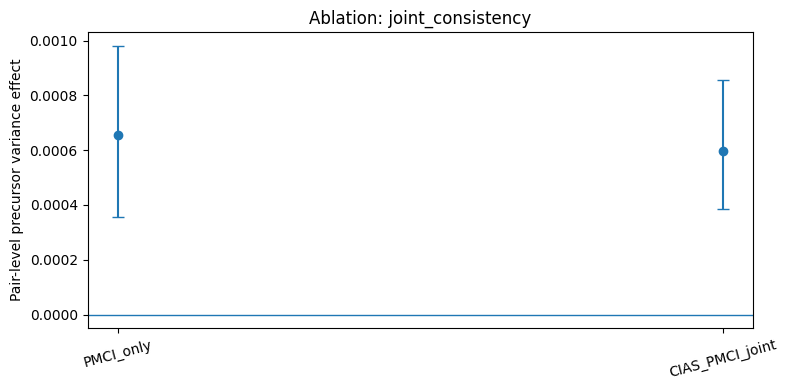

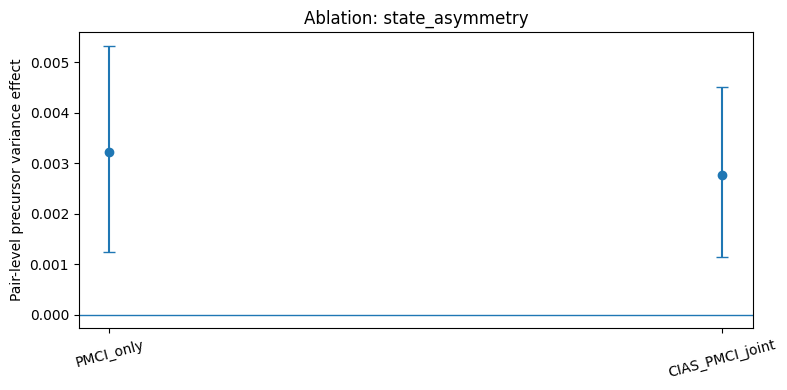

In [ ]:
#@title 07B. Ablation figures
for signal in ablation_summary.signal.unique():
    p=ablation_summary[ablation_summary.signal==signal].copy(); x=np.arange(len(p))
    yerr=np.vstack([p.mean_effect-p.ci_low,p.ci_high-p.mean_effect])
    plt.figure(figsize=(8,4)); plt.errorbar(x,p.mean_effect,yerr=yerr,fmt='o',capsize=4); plt.axhline(0,linewidth=1)
    plt.xticks(x,p.representation,rotation=15); plt.ylabel('Pair-level precursor variance effect'); plt.title(f'Ablation: {signal}'); plt.tight_layout(); plt.show()


## 08. Experiment 3 — boundary-matched control


In [ ]:
#@title 08A. Match stable controls by source regime, dwell age, time and cluster-boundary proximity
boundary_col='regime_cf_boundary_margin'
b_events,b_session,b_pair,b_summary,b_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id',
    boundary_col=boundary_col,boundary_weight=2.0
)
standard_6s=main_precursor_summary[(main_precursor_summary.pre_seconds==6.0)&(main_precursor_summary.signal.isin(['joint_consistency','state_asymmetry']))].copy()
standard_6s['control']='standard_matched'
b_comp=b_summary.copy(); b_comp['control']='boundary_matched'
boundary_comparison=pd.concat([standard_6s,b_comp],ignore_index=True,sort=False)
display(boundary_comparison[['control','signal','n_pairs','n_events','mean_effect','bootstrap_ci_low','bootstrap_ci_high','wilcoxon_p','p_fdr_bh']].round(6))
boundary_comparison.to_csv(RESULTS/'boundary_artifact_control_summary.csv',index=False)
b_pair.to_csv(RESULTS/'boundary_matched_pair_effects.csv',index=False)


,control,signal,n_pairs,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p,p_fdr_bh
0,standard_matched,joint_consistency,10,121,0.001176,0.000679,0.001895,0.001953,0.005859
1,standard_matched,state_asymmetry,10,121,0.003559,0.001555,0.005514,0.019531,0.029297
2,boundary_matched,joint_consistency,11,145,0.000324,0.000058,0.000588,0.083008,0.083008
3,boundary_matched,state_asymmetry,11,145,0.001997,0.000812,0.003105,0.009766,0.019531


## 09. Experiment 4 — pair-level bootstrap and leave-one-pair-out sensitivity


In [ ]:
#@title 09A. Leave one unique pair out
loo_rows=[]
for (signal,seconds),g in main_pair_effects.groupby(['signal','pre_seconds']):
    for omitted in sorted(g.pair_id.unique()):
        v=g.loc[g.pair_id!=omitted,'mean_effect'].to_numpy(float)
        loo_rows.append({'signal':signal,'pre_seconds':seconds,'omitted_pair':omitted,'remaining_pairs':len(v),'mean_effect':float(np.mean(v)) if len(v) else np.nan})
loo=pd.DataFrame(loo_rows)
loo_summary=loo.groupby(['signal','pre_seconds'],as_index=False).agg(min_loo_effect=('mean_effect','min'),max_loo_effect=('mean_effect','max'),fraction_positive=('mean_effect',lambda x:float(np.mean(np.asarray(x)>0))))
display(loo_summary.round(6))
loo.to_csv(RESULTS/'leave_one_pair_out_runs.csv',index=False); loo_summary.to_csv(RESULTS/'leave_one_pair_out_summary.csv',index=False)


,signal,pre_seconds,min_loo_effect,max_loo_effect,fraction_positive
0,joint_consistency,2.0,0.000952,0.001138,1.0
1,joint_consistency,4.0,0.000784,0.001176,1.0
2,joint_consistency,6.0,0.000866,0.001277,1.0
3,joint_consistency,8.0,0.000825,0.001280,1.0
4,joint_velocity,2.0,0.001749,0.003601,1.0
5,joint_velocity,4.0,0.002367,0.003762,1.0
6,joint_velocity,6.0,0.003108,0.004643,1.0
7,joint_velocity,8.0,0.002731,0.003710,1.0
8,state_asymmetry,2.0,0.001321,0.002709,1.0
9,state_asymmetry,4.0,0.001240,0.003589,1.0


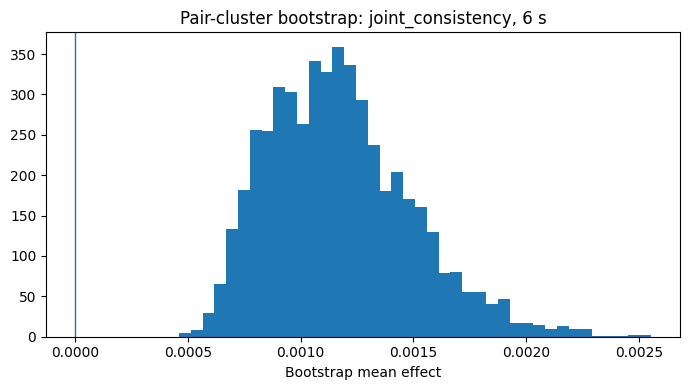

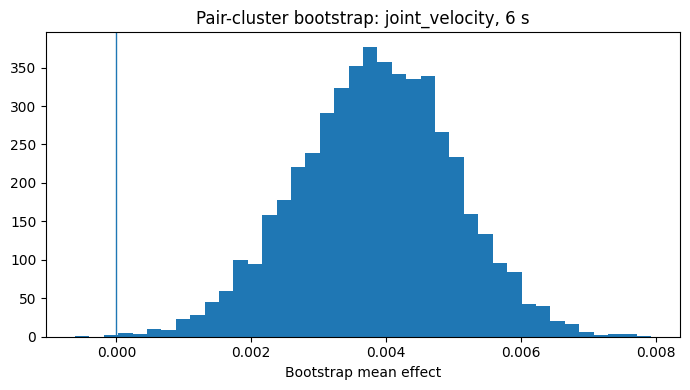

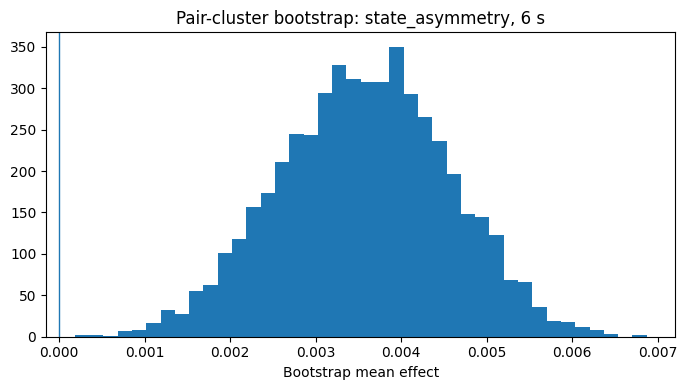

In [ ]:
#@title 09B. Pair-cluster bootstrap distributions
rng=np.random.default_rng(CFG.random_state); boot_rows=[]
for (signal,seconds),g in main_pair_effects.groupby(['signal','pre_seconds']):
    v=g.mean_effect.to_numpy(float)
    for i in range(CFG.bootstrap_iterations):
        boot_rows.append({'signal':signal,'pre_seconds':seconds,'iteration':i,'mean_effect':float(rng.choice(v,len(v),replace=True).mean())})
pair_bootstrap=pd.DataFrame(boot_rows)
pair_bootstrap.to_csv(RESULTS/'pair_cluster_bootstrap.csv',index=False)

for signal in pair_bootstrap.signal.unique():
    p=pair_bootstrap[(pair_bootstrap.signal==signal)&(pair_bootstrap.pre_seconds==6.0)]
    plt.figure(figsize=(7,4)); plt.hist(p.mean_effect,bins=40); plt.axvline(0,linewidth=1); plt.xlabel('Bootstrap mean effect'); plt.title(f'Pair-cluster bootstrap: {signal}, 6 s'); plt.tight_layout(); plt.show()


## 10. Optional strict participant-disjoint cross-fitting


In [ ]:
#@title 10A. Participant-component-disjoint robustness
if dyad.participant_component.nunique() < 2:
    print('Not enough participant components for participant-disjoint analysis.')
else:
    participant_cf,participant_folds=crossfit_regimes(
        dyad,STATE_COLUMNS,group_col='participant_component',k=CFG.selected_k,
        n_splits=min(CFG.crossfit_folds,dyad.participant_component.nunique()),seed=CFG.random_state+500,label_col='regime_participant_cf'
    )
    _,_,participant_pair_effects,participant_summary,_=strict_precursor_analysis(
        participant_cf,label_col='regime_participant_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id'
    )
    display(participant_folds.round(4)); display(participant_summary.round(6))
    participant_summary.to_csv(RESULTS/'participant_disjoint_precursor_summary.csv',index=False)
    participant_pair_effects.to_csv(RESULTS/'participant_disjoint_pair_effects.csv',index=False)


,fold,train_groups,test_groups,test_rows,silhouette_test
0,0,4,1,3475,0.1266
1,1,4,1,2217,0.3750
2,2,4,1,1434,0.3050
3,3,4,1,1404,0.3584
4,4,4,1,1373,0.2414


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,6.0,9,13,93,0.000617,-0.000023,0.001502,7,0.164062,0.089844,0.203125
1,state_asymmetry,6.0,9,13,93,0.001973,-0.000806,0.004323,7,0.203125,0.089844,0.203125


## 11. Experiment 5 — naturalistic transfer without refitting


In [ ]:
#@title 11A. Download and prepare naturalistic sessions
if not CFG.run_naturalistic_transfer:
    print('Naturalistic transfer disabled in CFG.')
else:
    transfer_fs,transfer_pairs,transfer_download_failures=download_complete_pairs(
        CFG.transfer_label,CFG.transfer_split,CFG.transfer_n_pairs,TRANSFER_ROOT,CFG.random_state+1000
    )
    transfer_manifest_all=build_raw_manifest(transfer_pairs,TRANSFER_ROOT,CFG.transfer_label,CFG.transfer_split)
    transfer_manifest,transfer_inventory,transfer_session_identity=prepare_identity_manifest(transfer_manifest_all)
    print('Naturalistic sessions:',transfer_manifest.interaction_key.nunique(),'pairs:',transfer_manifest.pair_id.nunique())
    transfer_manifest.to_csv(PROCESSED/'naturalistic_manifest.csv',index=False)


Download naturalistic/dev:   0%|          | 0/40 [00:00<?, ?it/s]

naturalistic/dev: requested=40, downloaded=40, failed=0


Feature inventory:   0%|          | 0/40 [00:00<?, ?it/s]

Naturalistic sessions: 17 pairs: 12


In [ ]:
#@title 11B. Project naturalistic data with fixed PMCI and fixed improvised regime model
if CFG.run_naturalistic_transfer:
    transfer_long,transfer_dyad,transfer_failures=build_dynamic_state_space(transfer_manifest,'Naturalistic CIAS–PMCI trajectories')

    # Final regime model is fitted once on the complete primary corpus and then frozen for external transfer.
    final_scaler=StandardScaler().fit(dyad[STATE_COLUMNS]); final_X=final_scaler.transform(dyad[STATE_COLUMNS])
    final_kmeans=KMeans(n_clusters=CFG.selected_k,n_init=100,max_iter=500,random_state=CFG.random_state).fit(final_X)
    transfer_X=final_scaler.transform(transfer_dyad[STATE_COLUMNS]); transfer_dyad['regime_transfer']=final_kmeans.predict(transfer_X)
    dist=cdist(transfer_X,final_kmeans.cluster_centers_); sd=np.sort(dist,axis=1); transfer_dyad['regime_transfer_boundary_margin']=sd[:,1]-sd[:,0]

    _,_,transfer_pair_effects,transfer_summary,_=strict_precursor_analysis(
        transfer_dyad,label_col='regime_transfer',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id'
    )
    occupancy=transfer_dyad.groupby('regime_transfer',as_index=False).size(); occupancy['fraction']=occupancy['size']/occupancy['size'].sum()
    print('Naturalistic regime occupancy'); display(occupancy)
    print('Naturalistic pair-level precursor'); display(transfer_summary.round(6))
    transfer_dyad.to_csv(PROCESSED/'naturalistic_projected_state_space.csv',index=False)
    transfer_summary.to_csv(RESULTS/'naturalistic_transfer_precursor_summary.csv',index=False)
    transfer_pair_effects.to_csv(RESULTS/'naturalistic_transfer_pair_effects.csv',index=False)
    occupancy.to_csv(RESULTS/'naturalistic_regime_occupancy.csv',index=False)


Naturalistic CIAS–PMCI trajectories:   0%|          | 0/34 [00:00<?, ?it/s]

Naturalistic regime occupancy


,regime_transfer,size,fraction
0,0,929,0.147601
1,1,2416,0.383858
2,2,2949,0.468541


Naturalistic pair-level precursor


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,6.0,11,15,104,0.001251,0.000603,0.001991,10,0.002930,0.005859,0.004883
1,state_asymmetry,6.0,11,15,104,0.008773,0.003927,0.015207,9,0.004883,0.032715,0.004883


## 12. Final reviewer table and export


In [ ]:
#@title 12A. Assemble the final evidence table
final_rows=[]
for _,r in pmci_metrics.iterrows():
    final_rows.append({'experiment':'PMCI pair-disjoint validation','signal':'ROC-AUC','estimate':r.roc_auc,'ci_low':np.nan,'ci_high':np.nan,'n_pairs':r.test_pairs})
for _,r in main_precursor_summary[main_precursor_summary.pre_seconds==6.0].iterrows():
    final_rows.append({'experiment':'Cross-fitted precursor','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
for _,r in b_summary.iterrows():
    final_rows.append({'experiment':'Boundary-matched precursor','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
for _,r in ablation_summary.iterrows():
    final_rows.append({'experiment':f'Ablation {r.representation}','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.ci_low,'ci_high':r.ci_high,'n_pairs':r.n_pairs})
if CFG.run_naturalistic_transfer and 'transfer_summary' in globals():
    for _,r in transfer_summary.iterrows():
        final_rows.append({'experiment':'Naturalistic transfer','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
final_evidence=pd.DataFrame(final_rows)
display(final_evidence.round(6))
final_evidence.to_csv(RESULTS/'FINAL_EVIDENCE_TABLE.csv',index=False)


,experiment,signal,estimate,ci_low,ci_high,n_pairs
0,PMCI pair-disjoint validation,ROC-AUC,0.687581,NaN,NaN,4.0
1,Cross-fitted precursor,joint_consistency,0.001176,0.000679,0.001895,10.0
2,Cross-fitted precursor,joint_velocity,0.003803,0.001490,0.006104,10.0
3,Cross-fitted precursor,state_asymmetry,0.003559,0.001555,0.005514,10.0
4,Boundary-matched precursor,joint_consistency,0.000324,0.000058,0.000588,11.0
5,Boundary-matched precursor,state_asymmetry,0.001997,0.000812,0.003105,11.0
6,Ablation PMCI_only,joint_consistency,0.000655,0.000356,0.000981,12.0
7,Ablation PMCI_only,state_asymmetry,0.003223,0.001237,0.005326,12.0
8,Ablation CIAS_PMCI_joint,joint_consistency,0.000598,0.000386,0.000857,11.0
9,Ablation CIAS_PMCI_joint,state_asymmetry,0.002758,0.001139,0.004516,11.0


Feature groups:
  state_usage: 9 features
  transition_topology: 9 features
  absolute_signal_levels: 6 features
  signal_dynamics: 8 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features

STATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS


,state,cias_A,pmci_A,cias_B,pmci_B,centroid_joint_consistency,centroid_state_asymmetry
0,0,0.523375,0.873644,0.525661,0.919008,0.710422,0.045421
1,1,0.527902,0.376774,0.527237,0.883917,0.578958,0.507143
2,2,0.523366,0.790895,0.522612,0.370853,0.551932,0.420043



TIME-GAP AUDIT


,condition,session_id,n_rows,n_segments,median_dt,max_dt,n_large_gaps
14,improvised,V00_S2022_I00001202,430,8,0.5,28.0,7
0,improvised,V00_S0644_I00000770,205,6,0.5,11.5,5
10,improvised,V00_S0809_I00000581,292,4,0.5,2.5,3
12,improvised,V00_S1061_I00000166,516,4,0.5,4.0,3
1,improvised,V00_S0648_I00000376,495,3,0.5,4.5,2
2,improvised,V00_S0648_I00000541,241,3,0.5,16.0,2
7,improvised,V00_S0696_I00000375,398,2,0.5,2.0,1
8,improvised,V00_S0700_I00000307,399,2,0.5,3.5,1
15,improvised,V00_S2022_I00001203,501,2,0.5,2.5,1
3,improvised,V00_S0648_I00000542,493,1,0.5,0.5,0



MINIMUM-DWELL AUDIT


...

,condition,minimum_dwell_seconds,adjustment,feature_group,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,same_pair_confirmed,dyad_specific_confirmed,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
9,improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.608505,0.009198,-1.391210,0.080384,True,False,0.458333,0.000600
8,improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,-0.990953,0.140132,-0.560190,0.377025,False,False,0.375000,0.000800
21,improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.338518,0.027195,-0.989201,0.098140,True,False,0.291667,0.005999
20,improvised,3.0,raw_with_technical_covariate,dynamics_without_levels,-0.955153,0.117876,-0.222479,0.443911,False,False,0.166667,0.099340
33,naturalistic,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.614944,0.028794,-2.549663,0.002400,True,True,0.235294,0.027295
32,naturalistic,2.0,raw_with_technical_covariate,dynamics_without_levels,-1.952751,0.017397,-2.055004,0.023995,True,True,0.176471,0.100480
45,naturalistic,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-2.017967,0.011398,-2.466974,0.003299,True,True,0.352941,0.002400
44,naturalistic,3.0,raw_with_technical_covariate,dynamics_without_levels,-2.322122,0.007598,-1.880583,0.035193,True,True,0.176471,0.075585
11,improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,-1.888864,0.008998,-1.638672,0.080384,True,False,0.458333,0.000800
10,improvised,2.0,raw_with_technical_covariate,full_fingerprint,-1.125875,0.140132,-0.647055,0.377025,False,False,0.458333,0.000600



FINGERPRINT ROBUSTNESS SUMMARY


,feature_group,n_tests,n_same_pair_confirmed,n_dyad_specific_confirmed,fraction_same_pair_confirmed,fraction_dyad_specific_confirmed,median_nearest_pair_accuracy
0,dynamics_without_levels,8,6,4,0.75,0.500,0.263480
1,full_fingerprint,8,6,4,0.75,0.500,0.313725
2,state_usage,8,4,3,0.50,0.375,0.192402
3,transition_topology,8,0,0,0.00,0.000,0.121324



GATEWAY VS FIRST-ORDER MARKOV NULL


,condition,minimum_dwell_seconds,gateway_state,n_pairs,mean_observed_gateway_ratio,mean_markov_null_ratio,mean_gateway_excess_over_markov,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_greater_p,p_fdr_bh
1,improvised,2.0,1,8,0.678309,0.581457,0.096852,0.000234,0.205033,4,0.109375,0.656250
0,improvised,2.0,0,11,0.045651,0.145228,-0.099577,-0.144878,-0.056503,0,1.000000,1.000000
2,improvised,2.0,2,9,0.171744,0.160750,0.010994,-0.071166,0.127529,2,0.787109,1.000000
7,naturalistic,2.0,1,10,0.477384,0.462022,0.015363,-0.027122,0.059241,5,0.278320,0.834961
6,naturalistic,2.0,0,12,0.124433,0.155489,-0.031055,-0.058236,-0.012664,1,0.999512,1.000000
8,naturalistic,2.0,2,10,0.309965,0.346113,-0.036149,-0.149158,0.043709,6,0.539062,1.000000
4,improvised,3.0,1,5,0.580000,0.478266,0.101734,-0.127176,0.369313,2,0.406250,0.910156
3,improvised,3.0,0,9,0.050980,0.146508,-0.095528,-0.184486,-0.031337,0,1.000000,1.000000
5,improvised,3.0,2,7,0.075255,0.158974,-0.083719,-0.144240,-0.022870,2,0.976562,1.000000
10,naturalistic,3.0,1,9,0.459436,0.417461,0.041975,-0.001915,0.094828,6,0.125000,0.750000


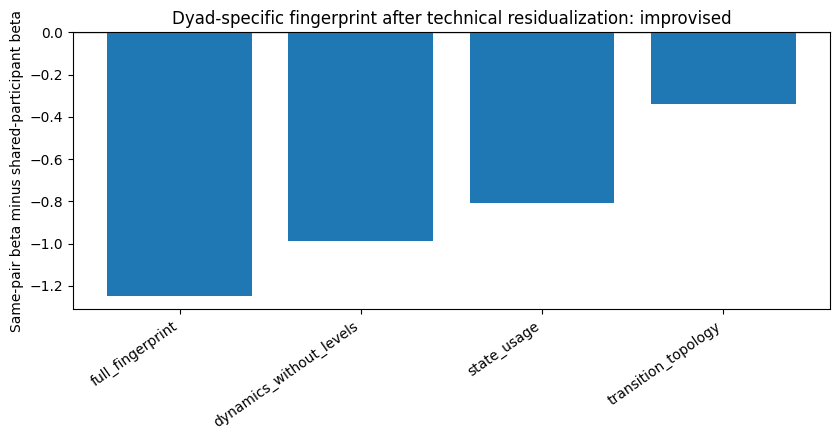

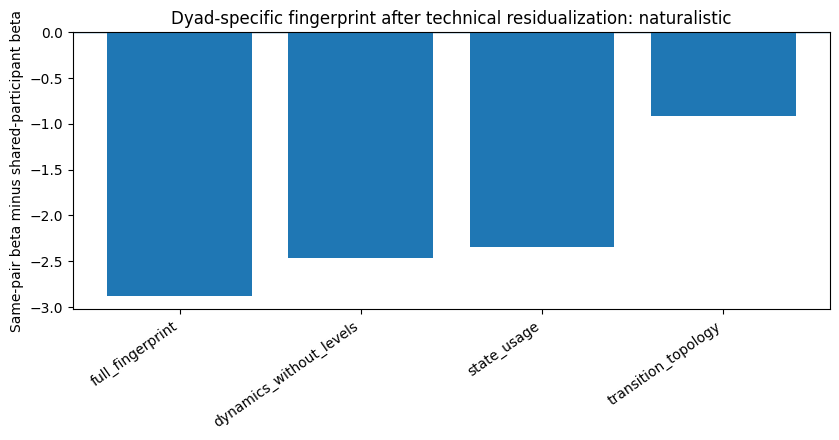


Saved final confirmatory outputs to: /content/article3_q1_additional_experiments/results
Primary interpretation rule:
  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint
  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05
  -> fingerprint is more dyad-specific than participant-specific
  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors


In [ ]:
#@title 13. FINAL confirmatory validation: pair fingerprint, technical controls, and Markov gateway null

from __future__ import annotations

from itertools import combinations
from pathlib import Path
import math
import zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

CONFIRM_DWELL_SECONDS = (2.0, 3.0)
CONFIRM_QAP_PERMUTATIONS = 5000       # final manuscript run
CONFIRM_MARKOV_SIMULATIONS = 2000
CONFIRM_RIDGE_ALPHA = 10.0
CONFIRM_RANDOM_STATE = int(getattr(CFG, 'random_state', 42))
CONFIRM_STATE_COLUMNS = ['cias_A', 'pmci_A', 'cias_B', 'pmci_B']
CONFIRM_K = int(getattr(CFG, 'selected_k', 3))

# The cell is intentionally independent of earlier experimental add-on cells.
# It only requires the original ALL-IN-ONE notebook to have completed through 11B.
_required = [
    'dyad', 'regime_data', 'transfer_dyad', 'manifest', 'transfer_manifest',
    'CFG', 'RESULTS', 'final_scaler', 'final_kmeans'
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Run the original notebook through cell 11B first. Missing objects: '
        + ', '.join(_missing)
    )

RESULTS = Path(RESULTS)
RESULTS.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def confirm_bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan, dtype=float)
    valid = np.flatnonzero(np.isfinite(p))
    if len(valid) == 0:
        return out
    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    out[valid] = restored
    return out


def confirm_parse_pair(pair_id):
    parts = str(pair_id).split('__')
    if len(parts) >= 2:
        return parts[0], parts[1]
    return str(pair_id), ''


def confirm_safe_matrix(frame_or_array):
    X = np.asarray(frame_or_array, dtype=float).copy()
    X[~np.isfinite(X)] = np.nan
    med = np.nanmedian(X, axis=0)
    med[~np.isfinite(med)] = 0.0
    rr, cc = np.where(~np.isfinite(X))
    if len(rr):
        X[rr, cc] = med[cc]
    sd = np.std(X, axis=0)
    keep = np.isfinite(sd) & (sd > 1e-10)
    if not np.any(keep):
        return np.zeros((len(X), 1), dtype=float)
    return X[:, keep]


def confirm_standardize(frame_or_array):
    X = confirm_safe_matrix(frame_or_array)
    if X.shape[1] == 0:
        return np.zeros((len(X), 1), dtype=float)
    return StandardScaler().fit_transform(X)


def confirm_infer_step(times, fallback=0.5):
    times = np.asarray(times, dtype=float)
    dt = np.diff(times)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(np.median(dt)) if len(dt) else float(fallback)


def confirm_run_length(labels):
    labels = np.asarray(labels, dtype=int)
    if len(labels) == 0:
        return []
    starts = [0]
    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            starts.append(i)
    starts.append(len(labels))
    return [
        {'start': starts[i], 'end': starts[i + 1] - 1, 'label': int(labels[starts[i]])}
        for i in range(len(starts) - 1)
    ]


def confirm_run_duration(times, run):
    start, end = int(run['start']), int(run['end'])
    local = np.asarray(times[start:end + 1], dtype=float)
    step = confirm_infer_step(local, getattr(CFG, 'stride_seconds', 0.5))
    return float(local[-1] - local[0] + step)

# ---------------------------------------------------------------------
# Time-aware preparation and frozen shared state model
# ---------------------------------------------------------------------

def confirm_prepare_timeaware(frame, condition):
    data = frame.copy().sort_values(['session_id', 'time_sec']).reset_index(drop=True)

    prepared = []
    audit_rows = []
    for session_id, g in data.groupby('session_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True).copy()
        t = g['time_sec'].to_numpy(float)
        step = confirm_infer_step(t, getattr(CFG, 'stride_seconds', 0.5))
        max_gap = max(0.75, 1.5 * step)
        dt = np.r_[np.nan, np.diff(t)]
        segment_break = np.zeros(len(g), dtype=int)
        segment_break[0] = 1
        if len(g) > 1:
            segment_break[1:] = (np.diff(t) > max_gap).astype(int)
        g['continuous_segment_local'] = np.cumsum(segment_break) - 1
        g['continuous_segment_id'] = (
            condition + '::' + g['session_id'].astype(str) + '::' +
            g['continuous_segment_local'].astype(str)
        )
        g['dt_seconds'] = dt

        for person in ['A', 'B']:
            for signal in ['cias', 'pmci']:
                col = f'{signal}_{person}'
                dcol = f'd_{signal}_{person}_dt'
                diff = g.groupby('continuous_segment_id')[col].diff()
                local_dt = g.groupby('continuous_segment_id')['time_sec'].diff()
                g[dcol] = diff / local_dt.replace(0, np.nan)

        derivative_cols = [
            'd_cias_A_dt', 'd_pmci_A_dt', 'd_cias_B_dt', 'd_pmci_B_dt'
        ]
        g['joint_velocity_timeaware'] = np.sqrt(
            g[derivative_cols].fillna(0.0).pow(2).sum(axis=1)
        )

        audit_rows.append({
            'condition': condition,
            'session_id': session_id,
            'n_rows': len(g),
            'n_segments': int(g['continuous_segment_id'].nunique()),
            'median_dt': step,
            'max_dt': float(np.nanmax(dt)) if np.any(np.isfinite(dt)) else np.nan,
            'n_large_gaps': int(np.sum(np.isfinite(dt) & (dt > max_gap))),
        })
        prepared.append(g)

    return pd.concat(prepared, ignore_index=True), pd.DataFrame(audit_rows)


def confirm_apply_state_labels(frame, condition):
    data = frame.copy()
    X = final_scaler.transform(data[CONFIRM_STATE_COLUMNS])
    distances = cdist(X, final_kmeans.cluster_centers_)
    sorted_d = np.sort(distances, axis=1)

    # Primary labels are genuinely out-of-pair-fold labels from the original notebook.
    # Naturalistic labels use the final frozen model trained only on improvised data.
    if condition == 'improvised' and 'regime_cf' in data.columns:
        data['regime_frozen'] = data['regime_cf'].astype(int)
        if 'regime_cf_boundary_margin' in data.columns:
            data['regime_boundary_margin'] = data['regime_cf_boundary_margin'].astype(float)
        else:
            data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]
    else:
        data['regime_frozen'] = final_kmeans.predict(X)
        data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]

    data['regime_nearest_distance'] = sorted_d[:, 0]
    data['condition'] = condition
    return data


primary_prepared, primary_gap_audit = confirm_prepare_timeaware(regime_data, 'improvised')
transfer_prepared, transfer_gap_audit = confirm_prepare_timeaware(transfer_dyad, 'naturalistic')
primary_prepared = confirm_apply_state_labels(primary_prepared, 'improvised')
transfer_prepared = confirm_apply_state_labels(transfer_prepared, 'naturalistic')
confirm_time_gap_audit = pd.concat([primary_gap_audit, transfer_gap_audit], ignore_index=True)

# Raw-state centroids in interpretable units
confirm_state_centroids = pd.DataFrame(
    final_scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=CONFIRM_STATE_COLUMNS,
)
confirm_state_centroids.insert(0, 'state', np.arange(CONFIRM_K))
confirm_state_centroids['centroid_joint_consistency'] = confirm_state_centroids[
    CONFIRM_STATE_COLUMNS
].mean(axis=1)
confirm_state_centroids['centroid_state_asymmetry'] = np.sqrt(
    (confirm_state_centroids['cias_A'] - confirm_state_centroids['cias_B']) ** 2
    + (confirm_state_centroids['pmci_A'] - confirm_state_centroids['pmci_B']) ** 2
)

# ---------------------------------------------------------------------
# Minimum-dwell smoothing in real time
# ---------------------------------------------------------------------

def confirm_smooth_segment(labels, times, minimum_dwell_seconds):
    labels = np.asarray(labels, dtype=int).copy()
    times = np.asarray(times, dtype=float)
    if minimum_dwell_seconds <= 0 or len(labels) < 2:
        return labels

    for _ in range(1000):
        runs = confirm_run_length(labels)
        durations = [confirm_run_duration(times, run) for run in runs]
        short_indices = [i for i, duration in enumerate(durations) if duration < minimum_dwell_seconds]
        if not short_indices or len(runs) == 1:
            break

        # Fix the shortest unstable run first, then recompute runs.
        i = min(short_indices, key=lambda idx: durations[idx])
        run = runs[i]
        left = runs[i - 1] if i > 0 else None
        right = runs[i + 1] if i + 1 < len(runs) else None

        if left is not None and right is not None and left['label'] == right['label']:
            replacement = left['label']
        elif left is None and right is not None:
            replacement = right['label']
        elif right is None and left is not None:
            replacement = left['label']
        elif left is not None and right is not None:
            left_duration = durations[i - 1]
            right_duration = durations[i + 1]
            replacement = left['label'] if left_duration >= right_duration else right['label']
        else:
            break

        labels[int(run['start']):int(run['end']) + 1] = int(replacement)

    return labels


def confirm_apply_minimum_dwell(frame, dwell_seconds):
    data = frame.copy()
    output_labels = np.full(len(data), -1, dtype=int)
    audit = []

    for segment_id, idx in data.groupby('continuous_segment_id', sort=False).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        idx = idx[np.argsort(data.loc[idx, 'time_sec'].to_numpy(float))]
        labels = data.loc[idx, 'regime_frozen'].to_numpy(int)
        times = data.loc[idx, 'time_sec'].to_numpy(float)
        smoothed = confirm_smooth_segment(labels, times, dwell_seconds)
        output_labels[idx] = smoothed
        audit.append({
            'condition': data.loc[idx[0], 'condition'],
            'minimum_dwell_seconds': float(dwell_seconds),
            'continuous_segment_id': segment_id,
            'original_switches': int(np.sum(labels[1:] != labels[:-1])),
            'smoothed_switches': int(np.sum(smoothed[1:] != smoothed[:-1])),
            'changed_rows': int(np.sum(smoothed != labels)),
        })

    if np.any(output_labels < 0):
        raise AssertionError('Some rows did not receive minimum-dwell labels.')
    label_col = f'regime_dwell_{str(dwell_seconds).replace(".", "p")}'
    data[label_col] = output_labels
    return data, label_col, pd.DataFrame(audit)

# ---------------------------------------------------------------------
# Runs, transitions, and session fingerprints
# ---------------------------------------------------------------------

def confirm_extract_runs_and_transitions(frame, label_col):
    run_rows, transition_rows = [], []

    for segment_id, g in frame.groupby('continuous_segment_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True)
        labels = g[label_col].to_numpy(int)
        times = g['time_sec'].to_numpy(float)
        runs = confirm_run_length(labels)
        local_runs = []

        for run_index, run in enumerate(runs):
            start, end = int(run['start']), int(run['end'])
            row = {
                'condition': g['condition'].iloc[0],
                'session_id': g['session_id'].iloc[0],
                'pair_id': g['pair_id'].iloc[0],
                'continuous_segment_id': segment_id,
                'run_index': run_index,
                'state': int(run['label']),
                'start_time': float(times[start]),
                'end_time': float(times[end]),
                'duration_seconds': confirm_run_duration(times, run),
            }
            for signal in [
                'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
                'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
                'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            ]:
                if signal in g.columns:
                    row[f'mean_{signal}'] = float(pd.to_numeric(
                        g.loc[start:end, signal], errors='coerce'
                    ).mean())
            run_rows.append(row)
            local_runs.append(row)

        for source, target in zip(local_runs[:-1], local_runs[1:]):
            transition_rows.append({
                'condition': source['condition'],
                'session_id': source['session_id'],
                'pair_id': source['pair_id'],
                'continuous_segment_id': segment_id,
                'source_state': int(source['state']),
                'target_state': int(target['state']),
                'edge': f"{source['state']}->{target['state']}",
                'transition_time': float(target['start_time']),
            })

    return pd.DataFrame(run_rows), pd.DataFrame(transition_rows)


def confirm_normalized_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    if len(counts) <= 1:
        return 0.0
    p = counts / counts.sum()
    return float(-np.sum(p * np.log(p)) / np.log(len(counts)))


def confirm_build_fingerprints(frame, runs, transitions, dwell_seconds):
    rows = []
    for (session_id, pair_id), sf in frame.groupby(['session_id', 'pair_id'], sort=False):
        sr = runs[runs['session_id'] == session_id].copy()
        st = transitions[transitions['session_id'] == session_id].copy()
        total_duration = float(sr['duration_seconds'].sum())
        pa, pb = confirm_parse_pair(pair_id)

        row = {
            'condition': sf['condition'].iloc[0],
            'minimum_dwell_seconds': float(dwell_seconds),
            'session_id': str(session_id),
            'pair_id': str(pair_id),
            'participant_a': pa,
            'participant_b': pb,
            'session_duration_seconds': total_duration,
            'n_rows': len(sf),
            'n_segments': int(sf['continuous_segment_id'].nunique()),
            'n_runs': len(sr),
            'n_transitions': len(st),
            'switching_rate_per_minute': 60.0 * len(st) / max(total_duration, 1e-8),
        }

        for state in range(CONFIRM_K):
            state_runs = sr[sr['state'] == state]
            state_duration = float(state_runs['duration_seconds'].sum())
            row[f'occupancy_state_{state}'] = state_duration / max(total_duration, 1e-8)
            row[f'mean_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].mean()) if len(state_runs) else 0.0
            )
            row[f'median_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].median()) if len(state_runs) else 0.0
            )

        edge_counts = []
        for source in range(CONFIRM_K):
            source_rows = st[st['source_state'] == source]
            source_total = len(source_rows)
            for target in range(CONFIRM_K):
                if source == target:
                    continue
                count = int(np.sum(source_rows['target_state'] == target)) if source_total else 0
                edge_counts.append(count)
                row[f'transition_p_{source}_{target}'] = count / source_total if source_total else 0.0

        row['transition_entropy'] = confirm_normalized_entropy(edge_counts)

        returns, triplets = 0, 0
        for _, segment_runs in sr.groupby('continuous_segment_id', sort=False):
            seq = segment_runs.sort_values('run_index')['state'].to_numpy(int)
            for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
                triplets += 1
                returns += int(a == c and a != b)
        row['return_probability'] = returns / triplets if triplets else 0.0

        for signal in [
            'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
            'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
            'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            'regime_nearest_distance',
        ]:
            if signal in sf.columns:
                values = pd.to_numeric(sf[signal], errors='coerce')
                row[f'session_mean_{signal}'] = float(values.mean())
                row[f'session_std_{signal}'] = float(values.std())

        rows.append(row)

    return pd.DataFrame(rows)

# ---------------------------------------------------------------------
# Manifest metadata and technical design
# ---------------------------------------------------------------------

def confirm_manifest_metadata(manifest_df, condition):
    m = manifest_df.copy()
    session_key = 'interaction_key' if 'interaction_key' in m.columns else 'session_id'
    keep_candidates = [
        'recording_session_id', 'interaction_prompt_id', 'dataset_label',
        'dataset_split', 'pair_id'
    ]
    keep = [c for c in keep_candidates if c in m.columns]
    meta = m[[session_key] + keep].groupby(session_key, as_index=False).first()
    meta = meta.rename(columns={session_key: 'session_id'})
    meta['session_id'] = meta['session_id'].astype(str)
    meta['condition'] = condition
    return meta


def confirm_add_metadata(fingerprints):
    primary_meta = confirm_manifest_metadata(manifest, 'improvised')
    transfer_meta = confirm_manifest_metadata(transfer_manifest, 'naturalistic')
    meta = pd.concat([primary_meta, transfer_meta], ignore_index=True)
    out = fingerprints.merge(meta, on=['session_id', 'condition'], how='left', suffixes=('', '_manifest'))
    out['vendor'] = out['session_id'].astype(str).str.split('_').str[0]
    return out


def confirm_technical_columns(frame):
    numeric = [
        c for c in [
            'session_duration_seconds', 'n_rows', 'n_segments',
            'session_mean_valid_fraction_A', 'session_mean_valid_fraction_B',
            'session_std_valid_fraction_A', 'session_std_valid_fraction_B',
            'session_mean_regime_nearest_distance', 'session_std_regime_nearest_distance',
        ] if c in frame.columns
    ]
    categorical = [
        c for c in ['vendor', 'recording_session_id', 'interaction_prompt_id']
        if c in frame.columns and 1 < frame[c].nunique(dropna=True) <= 30
    ]
    return numeric, categorical


def confirm_build_technical_matrix(frame):
    numeric, categorical = confirm_technical_columns(frame)
    parts = []
    names = []

    if numeric:
        num = frame[numeric].apply(pd.to_numeric, errors='coerce').copy()
        for c in numeric:
            med = num[c].median()
            num[c] = num[c].fillna(float(med) if np.isfinite(med) else 0.0)
        num_values = confirm_standardize(num.to_numpy(float))
        parts.append(num_values)
        names.extend([f'numeric_{i}' for i in range(num_values.shape[1])])

    if categorical:
        cat = pd.get_dummies(frame[categorical].fillna('missing').astype(str), drop_first=True, dtype=float)
        if cat.shape[1]:
            parts.append(cat.to_numpy(float))
            names.extend(cat.columns.astype(str).tolist())

    if not parts:
        return np.zeros((len(frame), 0), dtype=float), []
    return np.column_stack(parts), names

# ---------------------------------------------------------------------
# Relationship matrices, grouped residualization, and MRQAP
# ---------------------------------------------------------------------

def confirm_relationship_matrices(frame):
    n = len(frame)
    same_pair = np.zeros((n, n), dtype=float)
    shared_participant = np.zeros((n, n), dtype=float)
    participant_sets = []
    for pair_id in frame['pair_id'].astype(str):
        participant_sets.append(set(confirm_parse_pair(pair_id)))

    pair_ids = frame['pair_id'].astype(str).to_numpy()
    for i in range(n):
        for j in range(i + 1, n):
            if pair_ids[i] == pair_ids[j]:
                same_pair[i, j] = same_pair[j, i] = 1.0
            elif len(participant_sets[i] & participant_sets[j]) > 0:
                shared_participant[i, j] = shared_participant[j, i] = 1.0
    return same_pair, shared_participant


def confirm_group_crossfitted_residuals(features, technical, groups, alpha=10.0):
    Y = confirm_safe_matrix(features)
    if technical.shape[1] == 0:
        return Y.copy()

    groups = np.asarray(groups).astype(str)
    predictions = np.zeros_like(Y, dtype=float)
    for group in np.unique(groups):
        test = groups == group
        train = ~test
        if np.sum(train) < 3:
            predictions[test] = np.mean(Y[train], axis=0) if np.any(train) else 0.0
            continue
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(technical[train], Y[train])
        predictions[test] = model.predict(technical[test])
    return Y - predictions


def confirm_mrqap(distance_matrix, same_pair, shared_participant, technical_distance=None,
                   permutations=5000, seed=42):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]

    predictors = [np.ones(len(y)), same_pair[upper], shared_participant[upper]]
    names = ['intercept', 'same_pair', 'shared_participant']
    if technical_distance is not None:
        tv = technical_distance[upper]
        if np.nanstd(tv) > 1e-10:
            tv = (tv - np.nanmean(tv)) / np.nanstd(tv)
            predictors.append(tv)
            names.append('technical_distance')
    X = np.column_stack(predictors)
    observed = np.linalg.lstsq(X, y, rcond=None)[0]
    i_pair = names.index('same_pair')
    i_shared = names.index('shared_participant')
    observed_pair = float(observed[i_pair])
    observed_shared = float(observed[i_shared])
    observed_contrast = observed_pair - observed_shared

    rng = np.random.default_rng(seed)
    null_pair = np.empty(permutations)
    null_shared = np.empty(permutations)
    null_contrast = np.empty(permutations)

    for b in range(permutations):
        perm = rng.permutation(n)
        yp = distance_matrix[np.ix_(perm, perm)][upper]
        beta = np.linalg.lstsq(X, yp, rcond=None)[0]
        null_pair[b] = beta[i_pair]
        null_shared[b] = beta[i_shared]
        null_contrast[b] = beta[i_pair] - beta[i_shared]

    return {
        'same_pair_beta': observed_pair,
        'same_pair_qap_p': float((1 + np.sum(null_pair <= observed_pair)) / (permutations + 1)),
        'shared_participant_beta': observed_shared,
        'shared_participant_qap_p': float((1 + np.sum(null_shared <= observed_shared)) / (permutations + 1)),
        'same_pair_minus_shared_beta': observed_contrast,
        'pair_specificity_qap_p': float((1 + np.sum(null_contrast <= observed_contrast)) / (permutations + 1)),
    }


def confirm_nearest_pair_accuracy(distance_matrix, pair_ids, permutations=5000, seed=42):
    D = distance_matrix.copy()
    np.fill_diagonal(D, np.inf)
    pair_ids = np.asarray(pair_ids).astype(str)
    nearest = np.argmin(D, axis=1)
    observed = float(np.mean(pair_ids[nearest] == pair_ids))
    rng = np.random.default_rng(seed)
    null = np.empty(permutations)
    for b in range(permutations):
        labels = rng.permutation(pair_ids)
        null[b] = np.mean(labels[nearest] == labels)
    p = float((1 + np.sum(null >= observed)) / (permutations + 1))
    return observed, p

# ---------------------------------------------------------------------
# Feature groups
# ---------------------------------------------------------------------

def confirm_feature_groups(frame):
    numeric = [
        c for c in frame.columns
        if pd.api.types.is_numeric_dtype(frame[c])
    ]
    state_usage = [c for c in numeric if c.startswith(('occupancy_state_', 'mean_dwell_state_', 'median_dwell_state_'))]
    topology = [
        c for c in numeric
        if c.startswith('transition_p_') or c in {
            'switching_rate_per_minute', 'transition_entropy', 'return_probability'
        }
    ]
    absolute_levels = [
        c for c in numeric
        if c.startswith('session_mean_')
        and not any(token in c for token in ['valid_fraction', 'regime_', 'joint_velocity'])
    ]
    signal_dynamics = [
        c for c in numeric
        if (
            c.startswith('session_std_')
            or c == 'session_mean_joint_velocity_timeaware'
        )
        and not any(token in c for token in ['valid_fraction', 'regime_'])
    ]
    dynamics_without_levels = sorted(set(state_usage + topology + signal_dynamics))
    full = sorted(set(state_usage + topology + absolute_levels + signal_dynamics))
    return {
        'state_usage': state_usage,
        'transition_topology': topology,
        'absolute_signal_levels': absolute_levels,
        'signal_dynamics': signal_dynamics,
        'dynamics_without_levels': dynamics_without_levels,
        'full_fingerprint': full,
    }

# ---------------------------------------------------------------------
# Build all dwell-specific fingerprints
# ---------------------------------------------------------------------

confirm_store = {}
all_fingerprints, all_runs, all_transitions, all_smoothing_audits = [], [], [], []

for condition, base_frame in [
    ('improvised', primary_prepared),
    ('naturalistic', transfer_prepared),
]:
    for dwell in CONFIRM_DWELL_SECONDS:
        smoothed, label_col, smoothing_audit = confirm_apply_minimum_dwell(base_frame, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fingerprints = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
        confirm_store[(condition, dwell)] = {
            'frame': smoothed,
            'label_col': label_col,
            'runs': runs,
            'transitions': transitions,
            'fingerprints': fingerprints,
        }
        all_fingerprints.append(fingerprints)
        all_runs.append(runs.assign(minimum_dwell_seconds=float(dwell)))
        all_transitions.append(transitions.assign(minimum_dwell_seconds=float(dwell)))
        all_smoothing_audits.append(smoothing_audit)

confirm_fingerprints = confirm_add_metadata(pd.concat(all_fingerprints, ignore_index=True))
confirm_runs = pd.concat(all_runs, ignore_index=True)
confirm_transitions = pd.concat(all_transitions, ignore_index=True)
confirm_smoothing_audit = pd.concat(all_smoothing_audits, ignore_index=True)
CONFIRM_FEATURE_GROUPS = confirm_feature_groups(confirm_fingerprints)

print('Feature groups:')
for name, columns in CONFIRM_FEATURE_GROUPS.items():
    print(f'  {name}: {len(columns)} features')

# ---------------------------------------------------------------------
# Confirmatory fingerprint analyses
# ---------------------------------------------------------------------

confirm_rows = []
confirm_technical_rows = []

for condition in ['improvised', 'naturalistic']:
    for dwell in CONFIRM_DWELL_SECONDS:
        data = confirm_fingerprints[
            (confirm_fingerprints['condition'] == condition)
            & (confirm_fingerprints['minimum_dwell_seconds'] == float(dwell))
        ].sort_values('session_id').reset_index(drop=True)

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            technical_test = confirm_mrqap(
                technical_distance, same_pair, shared_participant,
                permutations=CONFIRM_QAP_PERMUTATIONS,
                seed=CONFIRM_RANDOM_STATE + int(dwell * 100) + (0 if condition == 'improvised' else 10000),
            )
            confirm_technical_rows.append({
                'condition': condition,
                'minimum_dwell_seconds': float(dwell),
                'n_sessions': len(data),
                'n_pairs': data['pair_id'].nunique(),
                'n_technical_predictors': technical_matrix.shape[1],
                **technical_test,
            })

        for feature_group, columns in CONFIRM_FEATURE_GROUPS.items():
            columns = [c for c in columns if c in data.columns]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors='coerce').to_numpy(float)

            for adjustment in ['raw_with_technical_covariate', 'pair_crossfitted_technical_residuals']:
                if adjustment == 'raw_with_technical_covariate':
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw, technical_matrix, data['pair_id'].astype(str).to_numpy(),
                        alpha=CONFIRM_RIDGE_ALPHA,
                    )

                standardized = confirm_standardize(features)
                distance = pairwise_distances(standardized)
                result = confirm_mrqap(
                    distance, same_pair, shared_participant,
                    technical_distance=technical_distance,
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=(
                        CONFIRM_RANDOM_STATE
                        + len(confirm_rows) * 17
                        + int(dwell * 100)
                        + (0 if condition == 'improvised' else 20000)
                    ),
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance, data['pair_id'],
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=CONFIRM_RANDOM_STATE + 30000 + len(confirm_rows),
                )
                confirm_rows.append({
                    'condition': condition,
                    'minimum_dwell_seconds': float(dwell),
                    'adjustment': adjustment,
                    'feature_group': feature_group,
                    'n_features': len(columns),
                    'n_sessions': len(data),
                    'n_pairs': data['pair_id'].nunique(),
                    'nearest_pair_accuracy': accuracy,
                    'nearest_pair_accuracy_p': accuracy_p,
                    **result,
                })

confirm_fingerprint_results = pd.DataFrame(confirm_rows)
confirm_technical_confound_results = pd.DataFrame(confirm_technical_rows)

for keys, idx in confirm_fingerprint_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'adjustment']
).groups.items():
    confirm_fingerprint_results.loc[idx, 'same_pair_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'same_pair_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p']
    )

# ---------------------------------------------------------------------
# First-order Markov null for gateway motifs
# ---------------------------------------------------------------------

def confirm_gateway_counts_from_sequences(sequences, gateway_state):
    others = [state for state in range(CONFIRM_K) if state != gateway_state]
    if len(others) != 2:
        return 0, 0
    x, y = others
    mediated, direct = 0, 0
    for seq in sequences:
        seq = np.asarray(seq, dtype=int)
        for a, b in zip(seq[:-1], seq[1:]):
            direct += int({int(a), int(b)} == {x, y})
        for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
            mediated += int(int(b) == gateway_state and {int(a), int(c)} == {x, y})
    return mediated, direct


def confirm_pair_sequences(runs_for_pair):
    sequences = []
    for _, g in runs_for_pair.groupby('continuous_segment_id', sort=False):
        seq = g.sort_values('run_index')['state'].to_numpy(int)
        if len(seq):
            sequences.append(seq)
    return sequences


def confirm_transition_matrix(sequences, pseudocount=0.5):
    counts = np.full((CONFIRM_K, CONFIRM_K), float(pseudocount))
    np.fill_diagonal(counts, 0.0)
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            if a != b:
                counts[int(a), int(b)] += 1.0
    matrix = np.zeros_like(counts)
    for state in range(CONFIRM_K):
        total = counts[state].sum()
        if total > 0:
            matrix[state] = counts[state] / total
        else:
            choices = [x for x in range(CONFIRM_K) if x != state]
            matrix[state, choices] = 1.0 / len(choices)
    return matrix


def confirm_simulate_markov_sequences(observed_sequences, transition_matrix, rng):
    simulated = []
    for observed in observed_sequences:
        observed = np.asarray(observed, dtype=int)
        if len(observed) == 0:
            simulated.append(observed)
            continue
        seq = np.empty(len(observed), dtype=int)
        seq[0] = int(observed[0])
        for i in range(1, len(seq)):
            seq[i] = int(rng.choice(np.arange(CONFIRM_K), p=transition_matrix[seq[i - 1]]))
        simulated.append(seq)
    return simulated


gateway_rows = []
for (condition, dwell, pair_id), pair_runs in confirm_runs.groupby(
    ['condition', 'minimum_dwell_seconds', 'pair_id'], sort=False
):
    sequences = confirm_pair_sequences(pair_runs)
    transition_matrix = confirm_transition_matrix(sequences)
    rng = np.random.default_rng(
        CONFIRM_RANDOM_STATE + zlib.crc32(f'{condition}|{float(dwell)}|{pair_id}'.encode('utf-8')) % 1_000_000
    )

    for gateway_state in range(CONFIRM_K):
        observed_mediated, observed_direct = confirm_gateway_counts_from_sequences(sequences, gateway_state)
        denominator = observed_mediated + observed_direct
        if denominator == 0:
            continue
        observed_ratio = observed_mediated / denominator
        null_ratios = []
        for _ in range(CONFIRM_MARKOV_SIMULATIONS):
            simulated = confirm_simulate_markov_sequences(sequences, transition_matrix, rng)
            mediated, direct = confirm_gateway_counts_from_sequences(simulated, gateway_state)
            if mediated + direct > 0:
                null_ratios.append(mediated / (mediated + direct))
        null_ratios = np.asarray(null_ratios, dtype=float)
        if len(null_ratios) == 0:
            continue
        null_mean = float(np.mean(null_ratios))
        null_sd = float(np.std(null_ratios, ddof=1)) if len(null_ratios) > 1 else np.nan
        gateway_rows.append({
            'condition': condition,
            'minimum_dwell_seconds': float(dwell),
            'pair_id': pair_id,
            'gateway_state': gateway_state,
            'observed_gateway_ratio': observed_ratio,
            'markov_null_mean': null_mean,
            'gateway_excess_over_markov': observed_ratio - null_mean,
            'markov_null_sd': null_sd,
            'pair_markov_p_greater': float((1 + np.sum(null_ratios >= observed_ratio)) / (len(null_ratios) + 1)),
            'observed_mediated_count': observed_mediated,
            'observed_direct_count': observed_direct,
        })

confirm_gateway_pair_results = pd.DataFrame(gateway_rows)

gateway_summary_rows = []
for (condition, dwell, state), g in confirm_gateway_pair_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'gateway_state']
):
    values = g['gateway_excess_over_markov'].dropna().to_numpy(float)
    if len(values) >= 5 and not np.allclose(values, 0):
        stat, p = wilcoxon(values, alternative='greater')
    else:
        p = np.nan
    rng = np.random.default_rng(CONFIRM_RANDOM_STATE + len(gateway_summary_rows))
    boot = np.array([
        np.mean(rng.choice(values, size=len(values), replace=True))
        for _ in range(5000)
    ]) if len(values) else np.array([])
    gateway_summary_rows.append({
        'condition': condition,
        'minimum_dwell_seconds': float(dwell),
        'gateway_state': int(state),
        'n_pairs': len(values),
        'mean_observed_gateway_ratio': float(g['observed_gateway_ratio'].mean()),
        'mean_markov_null_ratio': float(g['markov_null_mean'].mean()),
        'mean_gateway_excess_over_markov': float(np.mean(values)) if len(values) else np.nan,
        'bootstrap_ci_low': float(np.quantile(boot, 0.025)) if len(boot) else np.nan,
        'bootstrap_ci_high': float(np.quantile(boot, 0.975)) if len(boot) else np.nan,
        'n_positive_pairs': int(np.sum(values > 0)),
        'wilcoxon_greater_p': float(p) if np.isfinite(p) else np.nan,
    })

confirm_gateway_markov_summary = pd.DataFrame(gateway_summary_rows)
for dwell, idx in confirm_gateway_markov_summary.groupby('minimum_dwell_seconds').groups.items():
    confirm_gateway_markov_summary.loc[idx, 'p_fdr_bh'] = confirm_bh_adjust(
        confirm_gateway_markov_summary.loc[idx, 'wilcoxon_greater_p']
    )

# ---------------------------------------------------------------------
# Compact decision table
# ---------------------------------------------------------------------

core_groups = ['state_usage', 'transition_topology', 'dynamics_without_levels', 'full_fingerprint']
confirm_core_results = confirm_fingerprint_results[
    confirm_fingerprint_results['feature_group'].isin(core_groups)
].copy()
confirm_core_results['same_pair_confirmed'] = (
    (confirm_core_results['same_pair_beta'] < 0)
    & (confirm_core_results['same_pair_qap_p_fdr'] < 0.05)
)
confirm_core_results['dyad_specific_confirmed'] = (
    confirm_core_results['same_pair_confirmed']
    & (confirm_core_results['same_pair_minus_shared_beta'] < 0)
    & (confirm_core_results['pair_specificity_qap_p_fdr'] < 0.05)
)

confirm_robustness_summary = confirm_core_results.groupby('feature_group', as_index=False).agg(
    n_tests=('dyad_specific_confirmed', 'size'),
    n_same_pair_confirmed=('same_pair_confirmed', 'sum'),
    n_dyad_specific_confirmed=('dyad_specific_confirmed', 'sum'),
    fraction_same_pair_confirmed=('same_pair_confirmed', 'mean'),
    fraction_dyad_specific_confirmed=('dyad_specific_confirmed', 'mean'),
    median_nearest_pair_accuracy=('nearest_pair_accuracy', 'median'),
)

# ---------------------------------------------------------------------
# Display
# ---------------------------------------------------------------------

print('\nSTATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS')
display(confirm_state_centroids.round(6))

print('\nTIME-GAP AUDIT')
display(confirm_time_gap_audit.sort_values(['condition', 'n_large_gaps'], ascending=[True, False]).round(6))

print('\nMINIMUM-DWELL AUDIT')
display(
    confirm_smoothing_audit.groupby(['condition', 'minimum_dwell_seconds'], as_index=False).agg(
        original_switches=('original_switches', 'sum'),
        smoothed_switches=('smoothed_switches', 'sum'),
        changed_rows=('changed_rows', 'sum'),
        represented_segments=('continuous_segment_id', 'nunique'),
    )
)

print('\nTECHNICAL-CONFOUND QAP')
if len(confirm_technical_confound_results):
    display(confirm_technical_confound_results.round(6))
else:
    print('No usable technical predictors were available.')

print('\nFINAL CONFIRMATORY FINGERPRINT RESULTS')
display(
    confirm_fingerprint_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'n_features', 'n_sessions', 'n_pairs',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'shared_participant_beta',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values([
        'feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'
    ]).round(6)
)

print('\nCORE DECISION TABLE')
display(
    confirm_core_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'same_pair_confirmed', 'dyad_specific_confirmed',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values(['feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'])
)

print('\nFINGERPRINT ROBUSTNESS SUMMARY')
display(confirm_robustness_summary.round(6))

print('\nGATEWAY VS FIRST-ORDER MARKOV NULL')
display(
    confirm_gateway_markov_summary.sort_values(
        ['minimum_dwell_seconds', 'condition', 'p_fdr_bh']
    ).round(6)
)

# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

plot_data = confirm_core_results[
    (confirm_core_results['minimum_dwell_seconds'] == 3.0)
    & (confirm_core_results['adjustment'] == 'pair_crossfitted_technical_residuals')
].copy()

for condition, g in plot_data.groupby('condition'):
    g = g.sort_values('same_pair_minus_shared_beta')
    plt.figure(figsize=(8.5, 4.5))
    plt.bar(g['feature_group'], g['same_pair_minus_shared_beta'])
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=35, ha='right')
    plt.ylabel('Same-pair beta minus shared-participant beta')
    plt.title(f'Dyad-specific fingerprint after technical residualization: {condition}')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Save every final result
# ---------------------------------------------------------------------

confirm_state_centroids.to_csv(RESULTS / 'FINAL_confirmatory_state_centroids.csv', index=False)
confirm_time_gap_audit.to_csv(RESULTS / 'FINAL_confirmatory_time_gap_audit.csv', index=False)
confirm_smoothing_audit.to_csv(RESULTS / 'FINAL_confirmatory_minimum_dwell_audit.csv', index=False)
confirm_fingerprints.to_csv(RESULTS / 'FINAL_confirmatory_session_fingerprints.csv', index=False)
confirm_runs.to_csv(RESULTS / 'FINAL_confirmatory_state_runs.csv', index=False)
confirm_transitions.to_csv(RESULTS / 'FINAL_confirmatory_transitions.csv', index=False)
confirm_technical_confound_results.to_csv(RESULTS / 'FINAL_confirmatory_technical_confound_qap.csv', index=False)
confirm_fingerprint_results.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_mrqap.csv', index=False)
confirm_core_results.to_csv(RESULTS / 'FINAL_confirmatory_core_decision_table.csv', index=False)
confirm_robustness_summary.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_robustness.csv', index=False)
confirm_gateway_pair_results.to_csv(RESULTS / 'FINAL_confirmatory_gateway_pair_markov_null.csv', index=False)
confirm_gateway_markov_summary.to_csv(RESULTS / 'FINAL_confirmatory_gateway_markov_summary.csv', index=False)

print('\nSaved final confirmatory outputs to:', RESULTS)
print('Primary interpretation rule:')
print('  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint')
print('  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05')
print('  -> fingerprint is more dyad-specific than participant-specific')
print('  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors')


In [ ]:
#@title 14A. Discovery-composition and primary-result sanity check
STRICT_DISCOVERY_REPRO = True

discovery_audit = pd.DataFrame([{
    "improvised_sessions": int(manifest["interaction_key"].nunique()),
    "improvised_dyads": int(manifest["pair_id"].nunique()),
    "improvised_participants": int(manifest["participant_id"].nunique()),
    "naturalistic_sessions": int(transfer_manifest["interaction_key"].nunique()),
    "naturalistic_dyads": int(transfer_manifest["pair_id"].nunique()),
    "naturalistic_participants": int(transfer_manifest["participant_id"].nunique()),
    "all_discovery_participants": int(
        len(set(manifest["participant_id"].astype(str)) |
            set(transfer_manifest["participant_id"].astype(str)))
    ),
}])

display(discovery_audit)

expected_discovery = {
    "improvised_sessions": 24,
    "improvised_dyads": 12,
    "improvised_participants": 17,
    "naturalistic_sessions": 17,
    "naturalistic_dyads": 12,
    "naturalistic_participants": 21,
    "all_discovery_participants": 38,
}

mismatches = {
    k: (int(discovery_audit.iloc[0][k]), v)
    for k, v in expected_discovery.items()
    if int(discovery_audit.iloc[0][k]) != int(v)
}

if mismatches:
    print("DISCOVERY COMPOSITION MISMATCH:", mismatches)
    if STRICT_DISCOVERY_REPRO:
        raise RuntimeError(
            "Discovery sampling no longer reproduces the manuscript composition. "
            "Set STRICT_DISCOVERY_REPRO=False only if you intentionally want a fresh-sample analysis."
        )
else:
    print("Discovery composition matches the manuscript: 24/12/17 and 17/12/21.")

# The final confirmatory cell should already have generated the primary manuscript rows.
primary_sanity = confirm_core_results[
    (confirm_core_results["feature_group"] == "dynamics_without_levels")
    & (confirm_core_results["adjustment"] == "pair_crossfitted_technical_residuals")
][[
    "condition", "minimum_dwell_seconds", "same_pair_beta", "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta", "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy", "nearest_pair_accuracy_p_fdr",
]].sort_values(["condition", "minimum_dwell_seconds"]).reset_index(drop=True)

print("\nPRIMARY MANUSCRIPT SANITY ROWS")
display(primary_sanity.round(6))
primary_sanity.to_csv(RESULTS / "primary_manuscript_sanity_rows.csv", index=False)

,improvised_sessions,improvised_dyads,improvised_participants,naturalistic_sessions,naturalistic_dyads,naturalistic_participants,all_discovery_participants
0,24,12,17,17,12,21,38


Discovery composition matches the manuscript: 24/12/17 and 17/12/21.

PRIMARY MANUSCRIPT SANITY ROWS


,condition,minimum_dwell_seconds,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
0,improvised,2.0,-1.608505,0.009198,-1.391210,0.080384,0.458333,0.000600
1,improvised,3.0,-1.338518,0.027195,-0.989201,0.098140,0.291667,0.005999
2,naturalistic,2.0,-1.614944,0.028794,-2.549663,0.002400,0.235294,0.027295
3,naturalistic,3.0,-2.017967,0.011398,-2.466974,0.003299,0.352941,0.002400


# D. Fingerprint-level ablation and same-dimensional CIAS controls


In [ ]:
# ============================================================
# FINGERPRINT-LEVEL ABLATION:
# CIAS-only vs PMCI-only vs CIAS+PMCI
#
# Paste this ONE cell at the end of the working
# Article3_Q1_ALL_IN_ONE_FINAL_CONFIRMATORY notebook.
# Run the original notebook through the final confirmatory cell first.
# ============================================================

from pathlib import Path
import math
import shutil
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


# ------------------------------------------------------------
# 0. Preconditions
# ------------------------------------------------------------

REQUIRED_OBJECTS = [
    "dyad",
    "transfer_dyad",
    "manifest",
    "transfer_manifest",
    "CFG",
    "crossfit_regimes",
    "confirm_prepare_timeaware",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_add_metadata",
    "confirm_build_technical_matrix",
    "confirm_relationship_matrices",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

missing_objects = [name for name in REQUIRED_OBJECTS if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the original notebook through its final confirmatory cell first.\n"
        "Missing objects/functions:\n- " + "\n- ".join(missing_objects)
    )

REQUIRED_COLUMNS = {
    "session_id",
    "pair_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
}

for frame_name, frame in [("dyad", dyad), ("transfer_dyad", transfer_dyad)]:
    missing_columns = REQUIRED_COLUMNS - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{frame_name} is missing required columns: {sorted(missing_columns)}"
        )


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

REPRESENTATIONS = {
    "CIAS_only": ["cias_A", "cias_B"],
    "PMCI_only": ["pmci_A", "pmci_B"],
    "CIAS_PMCI_joint": ["cias_A", "pmci_A", "cias_B", "pmci_B"],
}

K = 3
DWELL_VALUES = (2.0, 3.0)
DISTANCE_METRIC = "euclidean"

# Smoke test: 499. Final manuscript run: 5000.
N_PERMUTATIONS = 5000
N_ADDED_VALUE_PERMUTATIONS = 5000

SEED = int(getattr(CFG, "random_state", 42))
N_FOLDS = int(getattr(CFG, "crossfit_folds", 5))
RIDGE_ALPHA = float(globals().get("CONFIRM_RIDGE_ALPHA", 10.0))

RESULT_ROOT = Path(
    globals().get(
        "RESULTS",
        "/content/article3_q1_additional_experiments/results",
    )
)
OUTPUT_DIR = RESULT_ROOT / "reviewer_defense_ablation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:")
print(OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Representation-specific observables
# ------------------------------------------------------------

def add_representation_observables(frame, active_columns):
    """Recalculate summary observables using only the active representation."""
    data = (
        frame.copy()
        .sort_values(["session_id", "time_sec"])
        .reset_index(drop=True)
    )

    data["joint_consistency"] = data[active_columns].mean(axis=1)

    if active_columns == ["cias_A", "cias_B"]:
        data["state_asymmetry"] = np.abs(data["cias_A"] - data["cias_B"])
    elif active_columns == ["pmci_A", "pmci_B"]:
        data["state_asymmetry"] = np.abs(data["pmci_A"] - data["pmci_B"])
    else:
        data["state_asymmetry"] = np.sqrt(
            (data["cias_A"] - data["cias_B"]) ** 2
            + (data["pmci_A"] - data["pmci_B"]) ** 2
        )

    prepared_sessions = []
    for _, session in data.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        derivatives = []

        for column in active_columns:
            numerator = session.groupby("continuous_segment_id")[column].diff()
            denominator = session.groupby("continuous_segment_id")["time_sec"].diff()
            derivative = numerator / denominator.replace(0, np.nan)
            derivative = derivative.replace([np.inf, -np.inf], np.nan)
            derivatives.append(derivative)

        session["joint_velocity_timeaware"] = np.sqrt(
            pd.concat(derivatives, axis=1)
            .fillna(0.0)
            .pow(2)
            .sum(axis=1)
        )
        prepared_sessions.append(session)

    return pd.concat(prepared_sessions, ignore_index=True)


# ------------------------------------------------------------
# 3. Representation-specific state models
# ------------------------------------------------------------

def fit_full_improvised_model(active_columns, k, seed):
    """Final frozen model fitted only on improvised trajectories."""
    scaler = StandardScaler().fit(dyad[active_columns].to_numpy(float))
    x_train = scaler.transform(dyad[active_columns].to_numpy(float))
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=seed,
    ).fit(x_train)
    return scaler, model


def prepare_improvised(active_columns, k, seed):
    """Pair-group cross-fitted labels for the improvised condition."""
    crossfitted, fold_metrics = crossfit_regimes(
        dyad,
        active_columns,
        group_col="pair_id",
        k=k,
        n_splits=N_FOLDS,
        seed=seed,
        label_col="reviewer_state",
    )

    prepared, gap_audit = confirm_prepare_timeaware(crossfitted, "improvised")

    # FIX FOR THE REPORTED KeyError:
    # confirm_prepare_timeaware uses the condition in segment IDs,
    # but it does not preserve it as a DataFrame column.
    prepared = prepared.copy()
    prepared["condition"] = "improvised"

    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)

    if "reviewer_state_boundary_margin" in prepared.columns:
        prepared["regime_boundary_margin"] = pd.to_numeric(
            prepared["reviewer_state_boundary_margin"], errors="coerce"
        )
    else:
        prepared["regime_boundary_margin"] = np.nan

    # Use the full improvised model only to estimate distance-to-state;
    # the actual improvised labels remain out-of-pair-fold labels.
    scaler, model = fit_full_improvised_model(active_columns, k, seed)
    x = scaler.transform(prepared[active_columns].to_numpy(float))
    distances = cdist(x, model.cluster_centers_)
    prepared["regime_nearest_distance"] = np.min(distances, axis=1)

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "improvised"

    return prepared, fold_metrics, gap_audit


def prepare_naturalistic(active_columns, k, seed):
    """Frozen transfer: fit on improvised, project naturalistic without refitting."""
    scaler, model = fit_full_improvised_model(active_columns, k, seed)

    projected = transfer_dyad.copy().reset_index(drop=True)
    x_test = scaler.transform(projected[active_columns].to_numpy(float))
    distances = cdist(x_test, model.cluster_centers_)
    sorted_distances = np.sort(distances, axis=1)

    projected["reviewer_state"] = model.predict(x_test)
    projected["reviewer_state_boundary_margin"] = (
        sorted_distances[:, 1] - sorted_distances[:, 0]
        if k > 1
        else np.zeros(len(projected), dtype=float)
    )
    projected["reviewer_state_nearest_distance"] = sorted_distances[:, 0]

    prepared, gap_audit = confirm_prepare_timeaware(projected, "naturalistic")

    # Same fix as above.
    prepared = prepared.copy()
    prepared["condition"] = "naturalistic"
    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)
    prepared["regime_boundary_margin"] = pd.to_numeric(
        prepared["reviewer_state_boundary_margin"], errors="coerce"
    )
    prepared["regime_nearest_distance"] = pd.to_numeric(
        prepared["reviewer_state_nearest_distance"], errors="coerce"
    )

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "naturalistic"

    return prepared, pd.DataFrame(), gap_audit


def prepare_condition(condition, active_columns, k, seed):
    if condition == "improvised":
        return prepare_improvised(active_columns, k, seed)
    if condition == "naturalistic":
        return prepare_naturalistic(active_columns, k, seed)
    raise ValueError(f"Unknown condition: {condition}")


# ------------------------------------------------------------
# 4. Representation-specific fingerprint groups
# ------------------------------------------------------------

def get_feature_groups(fingerprints, active_columns):
    numeric_columns = [
        column
        for column in fingerprints.columns
        if pd.api.types.is_numeric_dtype(fingerprints[column])
    ]

    state_usage = [
        column
        for column in numeric_columns
        if column.startswith(
            ("occupancy_state_", "mean_dwell_state_", "median_dwell_state_")
        )
    ]

    transition_topology = [
        column
        for column in numeric_columns
        if column.startswith("transition_p_")
        or column
        in {
            "switching_rate_per_minute",
            "transition_entropy",
            "return_probability",
        }
    ]

    absolute_levels = [
        f"session_mean_{column}"
        for column in active_columns
        if f"session_mean_{column}" in fingerprints.columns
    ]
    absolute_levels += [
        column
        for column in [
            "session_mean_joint_consistency",
            "session_mean_state_asymmetry",
        ]
        if column in fingerprints.columns
    ]

    signal_dynamics = [
        f"session_std_{column}"
        for column in active_columns
        if f"session_std_{column}" in fingerprints.columns
    ]
    signal_dynamics += [
        column
        for column in [
            "session_std_joint_consistency",
            "session_std_state_asymmetry",
            "session_mean_joint_velocity_timeaware",
            "session_std_joint_velocity_timeaware",
        ]
        if column in fingerprints.columns
    ]

    state_usage = sorted(set(state_usage))
    transition_topology = sorted(set(transition_topology))
    absolute_levels = sorted(set(absolute_levels))
    signal_dynamics = sorted(set(signal_dynamics))

    dynamics_without_levels = sorted(
        set(state_usage + transition_topology + signal_dynamics)
    )
    full_fingerprint = sorted(
        set(
            state_usage
            + transition_topology
            + absolute_levels
            + signal_dynamics
        )
    )

    return {
        "dynamics_without_levels": dynamics_without_levels,
        "full_fingerprint": full_fingerprint,
    }


# ------------------------------------------------------------
# 5. One complete evaluation
# ------------------------------------------------------------

def evaluate_representation(
    condition,
    representation,
    active_columns,
    dwell_seconds,
    seed,
):
    global CONFIRM_K

    previous_k = globals().get("CONFIRM_K", 3)
    CONFIRM_K = int(K)

    try:
        prepared, fold_metrics, gap_audit = prepare_condition(
            condition=condition,
            active_columns=active_columns,
            k=K,
            seed=seed,
        )

        # Defensive fix immediately before the function that raised KeyError.
        prepared = prepared.copy()
        prepared["condition"] = str(condition)

        smoothed, label_column, smoothing_audit = confirm_apply_minimum_dwell(
            prepared,
            dwell_seconds,
        )

        runs, transitions = confirm_extract_runs_and_transitions(
            smoothed,
            label_column,
        )

        fingerprints = confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            dwell_seconds,
        )
        fingerprints = confirm_add_metadata(fingerprints)
        fingerprints = (
            fingerprints.sort_values("session_id").reset_index(drop=True)
        )

        feature_groups = get_feature_groups(fingerprints, active_columns)
        same_pair, shared_participant = confirm_relationship_matrices(fingerprints)
        technical_matrix, technical_names = confirm_build_technical_matrix(
            fingerprints
        )

        output_rows = []
        output_objects = {}

        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            feature_columns = [
                column
                for column in feature_groups[feature_group]
                if column in fingerprints.columns
            ]

            if len(feature_columns) < 2:
                print(
                    f"SKIP {condition} {representation} {feature_group}: "
                    f"only {len(feature_columns)} usable features"
                )
                continue

            raw_features = (
                fingerprints[feature_columns]
                .apply(pd.to_numeric, errors="coerce")
                .to_numpy(float)
            )

            residual_features = confirm_group_crossfitted_residuals(
                raw_features,
                technical_matrix,
                fingerprints["pair_id"].astype(str).to_numpy(),
                alpha=RIDGE_ALPHA,
            )

            standardized_features = confirm_standardize(residual_features)
            n_effective_features = int(standardized_features.shape[1])

            raw_distance = pairwise_distances(
                standardized_features,
                metric=DISTANCE_METRIC,
            )

            # Raw distance reproduces the article-style Euclidean analysis.
            raw_mrqap = confirm_mrqap(
                raw_distance,
                same_pair,
                shared_participant,
                technical_distance=None,
                permutations=N_PERMUTATIONS,
                seed=seed + len(output_rows) * 101,
            )

            accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                raw_distance,
                fingerprints["pair_id"],
                permutations=N_PERMUTATIONS,
                seed=seed + 10_000 + len(output_rows) * 101,
            )

            # Divide coefficients by sqrt(p) for a fair direct comparison
            # between representations with different numbers of features.
            scale = math.sqrt(max(n_effective_features, 1))

            row = {
                "condition": condition,
                "representation": representation,
                "active_columns": "|".join(active_columns),
                "k": int(K),
                "minimum_dwell_seconds": float(dwell_seconds),
                "distance_metric": DISTANCE_METRIC,
                "technical_adjustment": "pair_crossfitted_technical_residuals",
                "feature_group": feature_group,
                "n_declared_features": len(feature_columns),
                "n_effective_features": n_effective_features,
                "n_sessions": len(fingerprints),
                "n_pairs": fingerprints["pair_id"].nunique(),
                "mean_crossfitted_silhouette": (
                    float(fold_metrics["silhouette_test"].mean())
                    if len(fold_metrics)
                    and "silhouette_test" in fold_metrics.columns
                    else np.nan
                ),
                "nearest_pair_accuracy": accuracy,
                "nearest_pair_accuracy_p": accuracy_p,
                **raw_mrqap,
                "same_pair_beta_rms": raw_mrqap["same_pair_beta"] / scale,
                "shared_participant_beta_rms": (
                    raw_mrqap["shared_participant_beta"] / scale
                ),
                "same_pair_minus_shared_beta_rms": (
                    raw_mrqap["same_pair_minus_shared_beta"] / scale
                ),
            }
            output_rows.append(row)

            output_objects[feature_group] = {
                "fingerprints": fingerprints.copy(),
                "distance": raw_distance.copy(),
                "same_pair": same_pair.copy(),
                "shared_participant": shared_participant.copy(),
                "n_effective_features": n_effective_features,
            }

        return output_rows, output_objects

    finally:
        CONFIRM_K = previous_k


# ------------------------------------------------------------
# 6. Direct permutation test: joint vs PMCI-only
# ------------------------------------------------------------

def mrqap_coefficients_only(distance_matrix, same_pair, shared_participant):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]
    X = np.column_stack(
        [
            np.ones(len(y)),
            same_pair[upper],
            shared_participant[upper],
        ]
    )
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    same_beta = float(beta[1])
    shared_beta = float(beta[2])
    return same_beta, same_beta - shared_beta


def direct_joint_vs_pmci_test(
    joint_object,
    pmci_object,
    permutations,
    seed,
):
    joint_fp = joint_object["fingerprints"].reset_index(drop=True)
    pmci_fp = pmci_object["fingerprints"].reset_index(drop=True)

    if not np.array_equal(
        joint_fp["session_id"].astype(str).to_numpy(),
        pmci_fp["session_id"].astype(str).to_numpy(),
    ):
        raise RuntimeError("Joint and PMCI session order does not match.")

    same_pair = joint_object["same_pair"]
    shared = joint_object["shared_participant"]
    d_joint = joint_object["distance"]
    d_pmci = pmci_object["distance"]

    p_joint = max(joint_object["n_effective_features"], 1)
    p_pmci = max(pmci_object["n_effective_features"], 1)

    same_joint, spec_joint = mrqap_coefficients_only(d_joint, same_pair, shared)
    same_pmci, spec_pmci = mrqap_coefficients_only(d_pmci, same_pair, shared)

    observed_same_delta = (
        same_joint / math.sqrt(p_joint) - same_pmci / math.sqrt(p_pmci)
    )
    observed_spec_delta = (
        spec_joint / math.sqrt(p_joint) - spec_pmci / math.sqrt(p_pmci)
    )

    pair_ids = joint_fp["pair_id"].astype(str).to_numpy()
    d_joint_nn = d_joint.copy()
    d_pmci_nn = d_pmci.copy()
    np.fill_diagonal(d_joint_nn, np.inf)
    np.fill_diagonal(d_pmci_nn, np.inf)
    joint_nn = np.argmin(d_joint_nn, axis=1)
    pmci_nn = np.argmin(d_pmci_nn, axis=1)
    observed_accuracy_delta = float(
        np.mean(pair_ids[joint_nn] == pair_ids)
        - np.mean(pair_ids[pmci_nn] == pair_ids)
    )

    rng = np.random.default_rng(seed)
    null_same = np.empty(permutations, dtype=float)
    null_spec = np.empty(permutations, dtype=float)
    null_accuracy = np.empty(permutations, dtype=float)

    for b in range(permutations):
        permutation = rng.permutation(len(d_joint))

        dj = d_joint[np.ix_(permutation, permutation)]
        dp = d_pmci[np.ix_(permutation, permutation)]

        sj, spj = mrqap_coefficients_only(dj, same_pair, shared)
        sm, spm = mrqap_coefficients_only(dp, same_pair, shared)

        null_same[b] = sj / math.sqrt(p_joint) - sm / math.sqrt(p_pmci)
        null_spec[b] = spj / math.sqrt(p_joint) - spm / math.sqrt(p_pmci)

        shuffled_labels = rng.permutation(pair_ids)
        null_accuracy[b] = float(
            np.mean(shuffled_labels[joint_nn] == shuffled_labels)
            - np.mean(shuffled_labels[pmci_nn] == shuffled_labels)
        )

    return {
        "joint_minus_PMCI_same_pair_beta_rms": observed_same_delta,
        "joint_better_same_pair_p": float(
            (1 + np.sum(null_same <= observed_same_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_specificity_beta_rms": observed_spec_delta,
        "joint_better_specificity_p": float(
            (1 + np.sum(null_spec <= observed_spec_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_accuracy": observed_accuracy_delta,
        "joint_better_accuracy_p": float(
            (1 + np.sum(null_accuracy >= observed_accuracy_delta))
            / (permutations + 1)
        ),
    }


# ------------------------------------------------------------
# 7. Run all ablations
# ------------------------------------------------------------

all_rows = []
all_objects = {}

for condition in ["improvised", "naturalistic"]:
    for representation_index, (representation, active_columns) in enumerate(
        REPRESENTATIONS.items()
    ):
        for dwell_seconds in DWELL_VALUES:
            print(
                "\nRUN:",
                condition,
                representation,
                f"dwell={dwell_seconds:g}s",
            )

            run_seed = (
                SEED
                + representation_index * 1_000
                + int(dwell_seconds * 100)
                + (0 if condition == "improvised" else 20_000)
            )

            rows, objects = evaluate_representation(
                condition=condition,
                representation=representation,
                active_columns=active_columns,
                dwell_seconds=dwell_seconds,
                seed=run_seed,
            )

            all_rows.extend(rows)
            all_objects[(condition, representation, dwell_seconds)] = objects

ablation_results = pd.DataFrame(all_rows)
if ablation_results.empty:
    raise RuntimeError("Ablation produced no result rows.")


# ------------------------------------------------------------
# 8. FDR correction for representation-level tests
# ------------------------------------------------------------

for _, indices in ablation_results.groupby(
    ["condition", "minimum_dwell_seconds", "feature_group"]
).groups.items():
    ablation_results.loc[indices, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        ablation_results.loc[indices, "same_pair_qap_p"]
    )
    ablation_results.loc[
        indices, "pair_specificity_qap_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "pair_specificity_qap_p"]
    )
    ablation_results.loc[
        indices, "nearest_pair_accuracy_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "nearest_pair_accuracy_p"]
    )


# ------------------------------------------------------------
# 9. Added-value table and direct tests
# ------------------------------------------------------------

added_value_rows = []

for condition in ["improvised", "naturalistic"]:
    for dwell_seconds in DWELL_VALUES:
        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            joint_key = (condition, "CIAS_PMCI_joint", dwell_seconds)
            pmci_key = (condition, "PMCI_only", dwell_seconds)

            if joint_key not in all_objects or pmci_key not in all_objects:
                continue
            if feature_group not in all_objects[joint_key]:
                continue
            if feature_group not in all_objects[pmci_key]:
                continue

            direct = direct_joint_vs_pmci_test(
                joint_object=all_objects[joint_key][feature_group],
                pmci_object=all_objects[pmci_key][feature_group],
                permutations=N_ADDED_VALUE_PERMUTATIONS,
                seed=(
                    SEED
                    + 50_000
                    + int(dwell_seconds * 100)
                    + (0 if condition == "improvised" else 10_000)
                    + (0 if feature_group == "dynamics_without_levels" else 1_000)
                ),
            )

            subset = ablation_results[
                (ablation_results["condition"] == condition)
                & (
                    ablation_results["minimum_dwell_seconds"]
                    == float(dwell_seconds)
                )
                & (ablation_results["feature_group"] == feature_group)
            ].set_index("representation")

            if not {
                "CIAS_only",
                "PMCI_only",
                "CIAS_PMCI_joint",
            }.issubset(subset.index):
                continue

            cias = subset.loc["CIAS_only"]
            pmci = subset.loc["PMCI_only"]
            joint = subset.loc["CIAS_PMCI_joint"]

            added_value_rows.append(
                {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell_seconds),
                    "feature_group": feature_group,
                    "CIAS_only_same_pair_beta_rms": cias["same_pair_beta_rms"],
                    "PMCI_only_same_pair_beta_rms": pmci["same_pair_beta_rms"],
                    "joint_same_pair_beta_rms": joint["same_pair_beta_rms"],
                    "CIAS_only_specificity_beta_rms": cias[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "PMCI_only_specificity_beta_rms": pmci[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "joint_specificity_beta_rms": joint[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "CIAS_only_accuracy": cias["nearest_pair_accuracy"],
                    "PMCI_only_accuracy": pmci["nearest_pair_accuracy"],
                    "joint_accuracy": joint["nearest_pair_accuracy"],
                    "joint_same_pair_q": joint["same_pair_qap_p_fdr"],
                    "joint_specificity_q": joint[
                        "pair_specificity_qap_p_fdr"
                    ],
                    "joint_accuracy_q": joint[
                        "nearest_pair_accuracy_p_fdr"
                    ],
                    **direct,
                }
            )

joint_added_value = pd.DataFrame(added_value_rows)

if not joint_added_value.empty:
    joint_added_value["joint_better_same_pair_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_same_pair_p"]
    )
    joint_added_value["joint_better_specificity_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_specificity_p"]
    )
    joint_added_value["joint_better_accuracy_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_accuracy_p"]
    )


# ------------------------------------------------------------
# 10. Display and save
# ------------------------------------------------------------

DISPLAY_COLUMNS = [
    "condition",
    "representation",
    "minimum_dwell_seconds",
    "feature_group",
    "n_effective_features",
    "same_pair_beta",
    "same_pair_beta_rms",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "same_pair_minus_shared_beta_rms",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]

print("\nFULL REPRESENTATION ABLATION")
display(
    ablation_results[DISPLAY_COLUMNS]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "feature_group",
            "representation",
        ]
    )
    .round(6)
)

print("\nDIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY")
display(joint_added_value.round(6))

ablation_csv = OUTPUT_DIR / "fingerprint_CIAS_PMCI_ablation.csv"
added_value_csv = OUTPUT_DIR / "joint_added_value_over_PMCI.csv"

ablation_results.to_csv(ablation_csv, index=False)
joint_added_value.to_csv(added_value_csv, index=False)

zip_path = shutil.make_archive(
    str(RESULT_ROOT / "reviewer_defense_ablation_results"),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("\nSAVED FILES")
print(ablation_csv)
print(added_value_csv)
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "1. same_pair_beta_rms: more negative = stronger same-dyad similarity.\n"
    "2. specificity_beta_rms: more negative = stronger dyad-specificity.\n"
    "3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.\n"
    "4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.\n"
    "5. Use the direct added-value FDR p-values before claiming that CIAS "
    "adds significant information beyond PMCI."
)

Results will be saved to:
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation

RUN: improvised CIAS_only dwell=2s

RUN: improvised CIAS_only dwell=3s

RUN: improvised PMCI_only dwell=2s

RUN: improvised PMCI_only dwell=3s

RUN: improvised CIAS_PMCI_joint dwell=2s

RUN: improvised CIAS_PMCI_joint dwell=3s

RUN: naturalistic CIAS_only dwell=2s

RUN: naturalistic CIAS_only dwell=3s

RUN: naturalistic PMCI_only dwell=2s

RUN: naturalistic PMCI_only dwell=3s

RUN: naturalistic CIAS_PMCI_joint dwell=2s

RUN: naturalistic CIAS_PMCI_joint dwell=3s

FULL REPRESENTATION ABLATION


,condition,representation,minimum_dwell_seconds,feature_group,n_effective_features,same_pair_beta,same_pair_beta_rms,same_pair_qap_p_fdr,same_pair_minus_shared_beta,same_pair_minus_shared_beta_rms,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
8,improvised,CIAS_PMCI_joint,2.0,dynamics_without_levels,26,-2.551982,-0.500485,0.000300,-2.371740,-0.465137,0.001200,0.458333,0.000600
0,improvised,CIAS_only,2.0,dynamics_without_levels,24,-1.067869,-0.217978,0.003599,-0.677957,-0.138387,0.126775,0.125000,0.161568
4,improvised,PMCI_only,2.0,dynamics_without_levels,24,-2.046869,-0.417815,0.000300,-1.424738,-0.290823,0.040192,0.250000,0.006899
9,improvised,CIAS_PMCI_joint,2.0,full_fingerprint,32,-3.021271,-0.534090,0.000300,-2.788318,-0.492910,0.000600,0.458333,0.000600
1,improvised,CIAS_only,2.0,full_fingerprint,28,-1.315089,-0.248528,0.000600,-1.019193,-0.192609,0.050190,0.125000,0.168166
5,improvised,PMCI_only,2.0,full_fingerprint,28,-2.468364,-0.466477,0.000300,-1.819051,-0.343768,0.019796,0.291667,0.003899
10,improvised,CIAS_PMCI_joint,3.0,dynamics_without_levels,26,-2.236410,-0.438596,0.000600,-1.838651,-0.360589,0.005999,0.291667,0.009598
2,improvised,CIAS_only,3.0,dynamics_without_levels,24,-0.788656,-0.160984,0.011798,-0.962559,-0.196481,0.039292,0.125000,0.180564
6,improvised,PMCI_only,3.0,dynamics_without_levels,24,-1.686286,-0.344212,0.000600,-0.833550,-0.170148,0.102380,0.250000,0.017097
11,improvised,CIAS_PMCI_joint,3.0,full_fingerprint,32,-2.732204,-0.482990,0.000300,-2.278574,-0.402799,0.001200,0.333333,0.002400



DIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY


,condition,minimum_dwell_seconds,feature_group,CIAS_only_same_pair_beta_rms,PMCI_only_same_pair_beta_rms,joint_same_pair_beta_rms,CIAS_only_specificity_beta_rms,PMCI_only_specificity_beta_rms,joint_specificity_beta_rms,CIAS_only_accuracy,...,joint_accuracy_q,joint_minus_PMCI_same_pair_beta_rms,joint_better_same_pair_p,joint_minus_PMCI_specificity_beta_rms,joint_better_specificity_p,joint_minus_PMCI_accuracy,joint_better_accuracy_p,joint_better_same_pair_p_fdr,joint_better_specificity_p_fdr,joint_better_accuracy_p_fdr
0,improvised,2.0,dynamics_without_levels,-0.217978,-0.417815,-0.500485,-0.138387,-0.290823,-0.465137,0.125000,...,0.000600,-0.082669,0.129174,-0.174313,0.041192,0.208333,0.004199,0.223270,0.084783,0.011198
1,improvised,2.0,full_fingerprint,-0.248528,-0.466477,-0.534090,-0.192609,-0.343768,-0.492910,0.125000,...,0.000600,-0.067613,0.143971,-0.149141,0.042392,0.166667,0.011798,0.223270,0.084783,0.023595
2,improvised,3.0,dynamics_without_levels,-0.160984,-0.344212,-0.438596,-0.196481,-0.170148,-0.360589,0.125000,...,0.009598,-0.094384,0.036193,-0.190442,0.004399,0.041667,0.158768,0.150370,0.017596,0.158768
3,improvised,3.0,full_fingerprint,-0.197746,-0.399309,-0.482990,-0.236467,-0.232692,-0.402799,0.125000,...,0.002400,-0.083681,0.037592,-0.170107,0.003199,0.125000,0.044991,0.150370,0.017596,0.071986
4,naturalistic,2.0,dynamics_without_levels,-0.191535,-0.350359,-0.409443,-0.169695,-0.523067,-0.583371,0.117647,...,0.047990,-0.059084,0.147770,-0.060304,0.136973,0.117647,0.079384,0.223270,0.201293,0.105845
5,naturalistic,2.0,full_fingerprint,-0.180280,-0.383778,-0.441921,-0.147424,-0.573121,-0.601915,0.117647,...,0.010198,-0.058144,0.189562,-0.028794,0.323335,0.117647,0.115977,0.223270,0.355729,0.132545
6,naturalistic,3.0,dynamics_without_levels,-0.247871,-0.424971,-0.470984,-0.146371,-0.494452,-0.549227,0.176471,...,0.001200,-0.046012,0.195361,-0.054775,0.150970,0.117647,0.002200,0.223270,0.201293,0.011198
7,naturalistic,3.0,full_fingerprint,-0.234311,-0.451030,-0.491977,-0.131455,-0.549073,-0.570614,0.176471,...,0.001800,-0.040947,0.269146,-0.021541,0.355729,0.117647,0.003999,0.269146,0.355729,0.011198



SAVED FILES
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/fingerprint_CIAS_PMCI_ablation.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/joint_added_value_over_PMCI.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation_results.zip

INTERPRETATION
1. same_pair_beta_rms: more negative = stronger same-dyad similarity.
2. specificity_beta_rms: more negative = stronger dyad-specificity.
3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.
4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.
5. Use the direct added-value FDR p-values before claiming that CIAS adds significant information beyond PMCI.


In [ ]:
# ============================================================
# PMCI + SHUFFLED CIAS / PMCI + MATCHED NOISE CONTROL
# Вставить ОДНОЙ ячейкой сразу после выполненной абляции
# CIAS-only / PMCI-only / CIAS+PMCI.
# ============================================================

from pathlib import Path
import math, shutil
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import pairwise_distances

# ---------- prerequisites ----------
required = [
    "dyad", "transfer_dyad", "all_objects", "ablation_results",
    "prepare_condition", "get_feature_groups", "mrqap_coefficients_only",
    "direct_joint_vs_pmci_test", "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions", "confirm_build_fingerprints",
    "confirm_add_metadata", "confirm_relationship_matrices",
    "confirm_build_technical_matrix", "confirm_group_crossfitted_residuals",
    "confirm_standardize", "confirm_bh_adjust",
]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(
        "Сначала выполни полную ячейку CIAS/PMCI ablation.\nНе найдены:\n- "
        + "\n- ".join(missing)
    )

# ---------- settings ----------
N_CONTROL_REPEATS = 20       # 5 для smoke test; 20 для итогового запуска
N_DIRECT_PERMUTATIONS = 5000
CONTROL_TYPES = ("PMCI_plus_shuffled_CIAS", "PMCI_plus_matched_noise")
DWELLS = (2.0, 3.0)
FEATURE_GROUPS = ("dynamics_without_levels", "full_fingerprint")
JOINT_COLUMNS = ["cias_A", "pmci_A", "cias_B", "pmci_B"]

BASE_SEED = int(globals().get("SEED", 42)) + 900_000
CONTROL_K = int(globals().get("K", 3))
CONTROL_RIDGE_ALPHA = float(globals().get("RIDGE_ALPHA", 10.0))
CONTROL_DISTANCE = str(globals().get("DISTANCE_METRIC", "euclidean"))
ROOT = Path(globals().get(
    "RESULT_ROOT",
    "/content/article3_q1_additional_experiments/results",
))
OUT = ROOT / "cias_content_controls"
OUT.mkdir(parents=True, exist_ok=True)

print("Results:", OUT)
print("Control ensemble repeats:", N_CONTROL_REPEATS)

# ---------- small utilities ----------
def resample_1d(values, n):
    x = np.asarray(values, float)
    finite = np.isfinite(x)
    if n <= 0:
        return np.empty(0)
    if finite.sum() == 0:
        return np.zeros(n)
    if finite.sum() == 1:
        return np.full(n, x[finite][0])
    if len(x) == n:
        return np.nan_to_num(x)
    old = np.linspace(0, 1, len(x))
    new = np.linspace(0, 1, n)
    return np.interp(new, old[finite], x[finite])

def lag1(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 4 or np.std(x[:-1]) < 1e-12 or np.std(x[1:]) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

def nearest_accuracy(distance, pair_ids):
    d = np.asarray(distance, float).copy()
    np.fill_diagonal(d, np.inf)
    labels = np.asarray(pair_ids).astype(str)
    return float(np.mean(labels[np.argmin(d, axis=1)] == labels))

# ---------- control 1: real CIAS trajectories reassigned across dyads ----------
def shuffled_cias_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    meta = source.groupby("session_id", sort=False).agg(pair_id=("pair_id", "first"))
    meta.index = meta.index.astype(str)
    session_ids = meta.index.tolist()
    chunks = []

    for recipient_id in session_ids:
        recipient = source[source["session_id"].astype(str) == recipient_id].copy()
        recipient = recipient.sort_values("time_sec")
        recipient_pair = str(meta.loc[recipient_id, "pair_id"])
        donors = [s for s in session_ids if str(meta.loc[s, "pair_id"]) != recipient_pair]
        if not donors:
            raise RuntimeError("No donor session from another dyad.")
        donor_id = str(rng.choice(donors))
        donor = source[source["session_id"].astype(str) == donor_id].sort_values("time_sec")
        a = donor["cias_A"].to_numpy(float)
        b = donor["cias_B"].to_numpy(float)
        if rng.random() < 0.5:
            a, b = b, a
        recipient["cias_A"] = np.clip(resample_1d(a, len(recipient)), 0, 1)
        recipient["cias_B"] = np.clip(resample_1d(b, len(recipient)), 0, 1)
        recipient["control_cias_source"] = donor_id
        chunks.append(recipient)

    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)

# ---------- control 2: bivariate AR(1) noise matched to CIAS ----------
def noise_parameters(frame):
    data = frame.copy().sort_values(["session_id", "time_sec"])
    means = data[["cias_A", "cias_B"]].mean().to_numpy(float)
    sds = data[["cias_A", "cias_B"]].std(ddof=0).to_numpy(float)
    sds = np.where(sds > 1e-8, sds, 1e-3)

    ra, rb = [], []
    for _, s in data.groupby("session_id", sort=False):
        ra.append(lag1(s["cias_A"]))
        rb.append(lag1(s["cias_B"]))
    rho_a = np.nanmedian(ra) if np.any(np.isfinite(ra)) else 0.0
    rho_b = np.nanmedian(rb) if np.any(np.isfinite(rb)) else 0.0
    rho_a, rho_b = np.clip([rho_a, rho_b], -0.95, 0.95)

    cross = data[["cias_A", "cias_B"]].corr().iloc[0, 1]
    cross = 0.0 if not np.isfinite(cross) else float(np.clip(cross, -0.95, 0.95))
    return means, sds, float(rho_a), float(rho_b), cross

def bivariate_ar1(n, params, rng):
    means, sds, rho_a, rho_b, cross = params
    corr = np.array([[1.0, cross], [cross, 1.0]])
    try:
        chol = np.linalg.cholesky(corr + np.eye(2) * 1e-8)
    except np.linalg.LinAlgError:
        chol = np.eye(2)

    innovations = rng.normal(size=(n, 2)) @ chol.T
    z = np.zeros((n, 2), float)
    if n:
        z[0] = innovations[0]
    rho = np.array([rho_a, rho_b], float)
    innovation_scale = np.sqrt(np.maximum(1.0 - rho**2, 1e-6))
    for t in range(1, n):
        z[t] = rho * z[t - 1] + innovation_scale * innovations[t]

    if n:
        z = (z - z.mean(0, keepdims=True)) / np.where(
            z.std(0, keepdims=True) > 1e-8,
            z.std(0, keepdims=True),
            1.0,
        )
    return np.clip(means[None, :] + z * sds[None, :], 0, 1)

def matched_noise_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    params = noise_parameters(source)
    chunks = []
    for _, session in source.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        generated = bivariate_ar1(len(session), params, rng)
        session["cias_A"] = generated[:, 0]
        session["cias_B"] = generated[:, 1]
        session["control_cias_source"] = "matched_AR1_noise"
        chunks.append(session)
    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)

# ---------- same pipeline, observed metrics only ----------
def evaluate_control_condition(condition, seed):
    global CONFIRM_K
    old_k = int(globals().get("CONFIRM_K", CONTROL_K))
    CONFIRM_K = CONTROL_K
    try:
        prepared, _, _ = prepare_condition(
            condition=condition,
            active_columns=JOINT_COLUMNS,
            k=CONTROL_K,
            seed=seed,
        )
        prepared = prepared.copy()
        prepared["condition"] = str(condition)
        rows, objects = [], {}

        for dwell in DWELLS:
            smoothed, label_col, _ = confirm_apply_minimum_dwell(prepared, dwell)
            runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
            fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
            fp = confirm_add_metadata(fp).sort_values("session_id").reset_index(drop=True)
            groups = get_feature_groups(fp, JOINT_COLUMNS)
            same, shared = confirm_relationship_matrices(fp)
            technical, _ = confirm_build_technical_matrix(fp)

            for group in FEATURE_GROUPS:
                cols = [c for c in groups[group] if c in fp.columns]
                raw = fp[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
                residual = confirm_group_crossfitted_residuals(
                    raw,
                    technical,
                    fp["pair_id"].astype(str).to_numpy(),
                    alpha=CONTROL_RIDGE_ALPHA,
                )
                standardized = confirm_standardize(residual)
                distance = pairwise_distances(standardized, metric=CONTROL_DISTANCE)
                same_beta, specificity = mrqap_coefficients_only(distance, same, shared)
                p = int(standardized.shape[1])
                scale = math.sqrt(max(p, 1))
                metrics = {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_effective_features": p,
                    "same_pair_beta_rms": same_beta / scale,
                    "specificity_beta_rms": specificity / scale,
                    "nearest_pair_accuracy": nearest_accuracy(distance, fp["pair_id"]),
                }
                rows.append(metrics)
                objects[(condition, float(dwell), group)] = {
                    "fingerprints": fp.copy(),
                    "distance": distance.copy(),
                    "same_pair": same.copy(),
                    "shared_participant": shared.copy(),
                    "n_effective_features": p,
                }
        return pd.DataFrame(rows), objects
    finally:
        CONFIRM_K = old_k

# ---------- run control ensemble ----------
real_dyad = dyad
real_transfer = transfer_dyad
descriptive_rows = []
distance_ensemble = {
    (control, condition, float(dwell), group): []
    for control in CONTROL_TYPES
    for condition in ("improvised", "naturalistic")
    for dwell in DWELLS
    for group in FEATURE_GROUPS
}

try:
    for repeat in range(N_CONTROL_REPEATS):
        print(f"\nCONTROL REPEAT {repeat + 1}/{N_CONTROL_REPEATS}")

        for control_index, control in enumerate(CONTROL_TYPES):
            seed = BASE_SEED + repeat * 10000 + control_index * 1000

            if control == "PMCI_plus_shuffled_CIAS":
                control_dyad = shuffled_cias_frame(real_dyad, seed + 11)
                control_transfer = shuffled_cias_frame(real_transfer, seed + 22)
            else:
                control_dyad = matched_noise_frame(real_dyad, seed + 33)
                control_transfer = matched_noise_frame(real_transfer, seed + 44)

            globals()["dyad"] = control_dyad
            globals()["transfer_dyad"] = control_transfer

            imp_rows, imp_objects = evaluate_control_condition("improvised", seed + 101)
            nat_rows, nat_objects = evaluate_control_condition("naturalistic", seed + 202)

            current = pd.concat([imp_rows, nat_rows], ignore_index=True)
            current["control_type"] = control
            current["control_repeat"] = repeat
            current["control_seed"] = seed
            descriptive_rows.append(current)

            for key, obj in {**imp_objects, **nat_objects}.items():
                distance_ensemble[(control, *key)].append(obj["distance"])
finally:
    globals()["dyad"] = real_dyad
    globals()["transfer_dyad"] = real_transfer

control_runs = pd.concat(descriptive_rows, ignore_index=True)
control_runs.to_csv(OUT / "control_repeats.csv", index=False)

# ---------- compare real joint with averaged control distance ----------
comparison_rows = []

for control in CONTROL_TYPES:
    for condition in ("improvised", "naturalistic"):
        for dwell in DWELLS:
            for group in FEATURE_GROUPS:
                real_key = (condition, "CIAS_PMCI_joint", float(dwell))
                if real_key not in all_objects or group not in all_objects[real_key]:
                    continue

                real_object = all_objects[real_key][group]
                matrices = distance_ensemble[(control, condition, float(dwell), group)]
                if not matrices:
                    continue

                mean_distance = np.mean(np.stack(matrices, axis=0), axis=0)
                control_object = {
                    "fingerprints": real_object["fingerprints"].copy(),
                    "distance": mean_distance,
                    "same_pair": real_object["same_pair"].copy(),
                    "shared_participant": real_object["shared_participant"].copy(),
                    "n_effective_features": real_object["n_effective_features"],
                }

                direct = direct_joint_vs_pmci_test(
                    joint_object=real_object,
                    pmci_object=control_object,
                    permutations=N_DIRECT_PERMUTATIONS,
                    seed=BASE_SEED + 500000
                        + (0 if control == CONTROL_TYPES[0] else 100000)
                        + (0 if condition == "improvised" else 10000)
                        + int(dwell * 100)
                        + (0 if group == FEATURE_GROUPS[0] else 1000),
                )

                subset = control_runs[
                    (control_runs["control_type"] == control)
                    & (control_runs["condition"] == condition)
                    & (control_runs["minimum_dwell_seconds"] == float(dwell))
                    & (control_runs["feature_group"] == group)
                ]

                real_row = ablation_results[
                    (ablation_results["representation"] == "CIAS_PMCI_joint")
                    & (ablation_results["condition"] == condition)
                    & (ablation_results["minimum_dwell_seconds"] == float(dwell))
                    & (ablation_results["feature_group"] == group)
                ].iloc[0]

                comparison_rows.append({
                    "control_type": control,
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_control_repeats": len(matrices),

                    "real_same_pair_beta_rms": real_row["same_pair_beta_rms"],
                    "control_same_pair_mean": subset["same_pair_beta_rms"].mean(),
                    "control_same_pair_sd": subset["same_pair_beta_rms"].std(ddof=1),

                    "real_specificity_beta_rms": real_row["same_pair_minus_shared_beta_rms"],
                    "control_specificity_mean": subset["specificity_beta_rms"].mean(),
                    "control_specificity_sd": subset["specificity_beta_rms"].std(ddof=1),

                    "real_accuracy": real_row["nearest_pair_accuracy"],
                    "control_accuracy_mean": subset["nearest_pair_accuracy"].mean(),
                    "control_accuracy_sd": subset["nearest_pair_accuracy"].std(ddof=1),

                    "real_minus_control_same_pair_beta_rms":
                        direct["joint_minus_PMCI_same_pair_beta_rms"],
                    "real_better_same_pair_p":
                        direct["joint_better_same_pair_p"],

                    "real_minus_control_specificity_beta_rms":
                        direct["joint_minus_PMCI_specificity_beta_rms"],
                    "real_better_specificity_p":
                        direct["joint_better_specificity_p"],

                    "real_minus_control_accuracy":
                        direct["joint_minus_PMCI_accuracy"],
                    "real_better_accuracy_p":
                        direct["joint_better_accuracy_p"],
                })

comparison = pd.DataFrame(comparison_rows)

# FDR separately for each control and outcome
for control in CONTROL_TYPES:
    idx = comparison["control_type"] == control
    comparison.loc[idx, "real_better_same_pair_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_same_pair_p"]
    )
    comparison.loc[idx, "real_better_specificity_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_specificity_p"]
    )
    comparison.loc[idx, "real_better_accuracy_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_accuracy_p"]
    )

comparison.to_csv(OUT / "real_CIAS_vs_controls.csv", index=False)

display_cols = [
    "control_type", "condition", "minimum_dwell_seconds", "feature_group",
    "real_same_pair_beta_rms", "control_same_pair_mean",
    "real_better_same_pair_p_fdr",
    "real_specificity_beta_rms", "control_specificity_mean",
    "real_better_specificity_p_fdr",
    "real_accuracy", "control_accuracy_mean",
    "real_better_accuracy_p_fdr",
]

print("\nREAL CIAS VS SAME-DIMENSION CONTROLS")
display(comparison[display_cols].sort_values(
    ["control_type", "condition", "minimum_dwell_seconds", "feature_group"]
).round(6))

zip_path = shutil.make_archive(
    str(ROOT / "cias_content_control_results"),
    "zip",
    root_dir=OUT,
)

print("\nSAVED")
print(OUT / "control_repeats.csv")
print(OUT / "real_CIAS_vs_controls.csv")
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.\n"
    "Для beta: real_minus_control < 0 лучше.\n"
    "Для accuracy: real_minus_control > 0 лучше.\n"
    "Shuffled CIAS — основной контроль; matched noise — дополнительный.\n"
)

Results: /content/article3_q1_additional_experiments/results/cias_content_controls
Control ensemble repeats: 20

CONTROL REPEAT 1/20

CONTROL REPEAT 2/20

CONTROL REPEAT 3/20

CONTROL REPEAT 4/20

CONTROL REPEAT 5/20

CONTROL REPEAT 6/20

CONTROL REPEAT 7/20

CONTROL REPEAT 8/20

CONTROL REPEAT 9/20

CONTROL REPEAT 10/20

CONTROL REPEAT 11/20

CONTROL REPEAT 12/20

CONTROL REPEAT 13/20

CONTROL REPEAT 14/20

CONTROL REPEAT 15/20

CONTROL REPEAT 16/20

CONTROL REPEAT 17/20

CONTROL REPEAT 18/20

CONTROL REPEAT 19/20

CONTROL REPEAT 20/20

REAL CIAS VS SAME-DIMENSION CONTROLS


,control_type,condition,minimum_dwell_seconds,feature_group,real_same_pair_beta_rms,control_same_pair_mean,real_better_same_pair_p_fdr,real_specificity_beta_rms,control_specificity_mean,real_better_specificity_p_fdr,real_accuracy,control_accuracy_mean,real_better_accuracy_p_fdr
8,PMCI_plus_matched_noise,improvised,2.0,dynamics_without_levels,-0.500485,-0.566355,0.917217,-0.465137,-0.567903,0.946211,0.458333,0.360417,0.328734
9,PMCI_plus_matched_noise,improvised,2.0,full_fingerprint,-0.534090,-0.598750,0.917217,-0.492910,-0.587558,0.946211,0.458333,0.379167,0.328734
10,PMCI_plus_matched_noise,improvised,3.0,dynamics_without_levels,-0.438596,-0.471901,0.917217,-0.360589,-0.413832,0.946211,0.291667,0.308333,0.942212
11,PMCI_plus_matched_noise,improvised,3.0,full_fingerprint,-0.482990,-0.512887,0.917217,-0.402799,-0.446089,0.946211,0.333333,0.308333,0.942212
12,PMCI_plus_matched_noise,naturalistic,2.0,dynamics_without_levels,-0.409443,-0.299629,0.128374,-0.583371,-0.461577,0.173832,0.235294,0.105882,0.227155
13,PMCI_plus_matched_noise,naturalistic,2.0,full_fingerprint,-0.441921,-0.334885,0.128374,-0.601915,-0.515180,0.173832,0.294118,0.188235,0.227155
14,PMCI_plus_matched_noise,naturalistic,3.0,dynamics_without_levels,-0.470984,-0.370075,0.128374,-0.549227,-0.443856,0.173832,0.352941,0.241176,0.023195
15,PMCI_plus_matched_noise,naturalistic,3.0,full_fingerprint,-0.491977,-0.399052,0.128374,-0.570614,-0.500929,0.186763,0.352941,0.232353,0.023195
0,PMCI_plus_shuffled_CIAS,improvised,2.0,dynamics_without_levels,-0.500485,-0.518226,0.680064,-0.465137,-0.495428,0.721856,0.458333,0.379167,0.413037
1,PMCI_plus_shuffled_CIAS,improvised,2.0,full_fingerprint,-0.534090,-0.513375,0.348730,-0.492910,-0.481907,0.469163,0.458333,0.395833,0.413037



SAVED
/content/article3_q1_additional_experiments/results/cias_content_controls/control_repeats.csv
/content/article3_q1_additional_experiments/results/cias_content_controls/real_CIAS_vs_controls.csv
/content/article3_q1_additional_experiments/results/cias_content_control_results.zip

INTERPRETATION
real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.
Для beta: real_minus_control < 0 лучше.
Для accuracy: real_minus_control > 0 лучше.
Shuffled CIAS — основной контроль; matched noise — дополнительный.



# E. Historical batch-0000 robustness and Table 7 reproduction




In [ ]:
#@title E0. Switch to Table 7 output root
from pathlib import Path
ROOT = Path('/content/article3_table7_full_reproduction')
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Active ROOT:", ROOT)
print("Active RESULTS:", RESULTS)


In [ ]:
#@title 15A. Hugging Face batch-0000 streaming downloader with checkpoints
import os
import time
import tarfile
import shutil
import requests
from pathlib import Path
from huggingface_hub import HfApi, hf_hub_url

HF_REPO_ID = "facebook/seamless-interaction"
HF_BATCH_INDEX = 0
HF_MAX_RETRIES = 4

BATCH_ROOT = ROOT / "historical_batch0000"
IMP_BATCH_NPZ = BATCH_ROOT / "improvised_npz"
NAT_BATCH_NPZ = BATCH_ROOT / "naturalistic_npz"
CHECKPOINT_ROOT = BATCH_ROOT / "archive_checkpoints"

for p in [BATCH_ROOT, IMP_BATCH_NPZ, NAT_BATCH_NPZ, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

def list_hf_batch_archives(label: str, split: str = "dev", batch_index: int = 0):
    api = HfApi()
    path_in_repo = f"{label}/{split}/{batch_index:04d}"
    items = list(api.list_repo_tree(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        path_in_repo=path_in_repo,
        recursive=False,
    ))
    paths = sorted(
        [x.path for x in items if getattr(x, "path", "").endswith(".tar")],
        key=lambda x: int(Path(x).stem) if Path(x).stem.isdigit() else Path(x).stem,
    )
    if not paths:
        raise RuntimeError(f"No .tar archives found under {path_in_repo}")
    return paths

def _checkpoint_path(label, split, batch_index, remote_path):
    d = CHECKPOINT_ROOT / label / split / f"{batch_index:04d}"
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{Path(remote_path).stem}.done"

def stream_extract_npz_archive(remote_path: str, output_dir: Path, token=None):
    url = hf_hub_url(
        repo_id=HF_REPO_ID,
        filename=remote_path,
        repo_type="dataset",
    )
    headers = {}
    if token:
        headers["Authorization"] = f"Bearer {token}"

    with requests.get(
        url,
        stream=True,
        allow_redirects=True,
        headers=headers,
        timeout=(30, 1800),
    ) as response:
        response.raise_for_status()
        response.raw.decode_content = True
        n_npz = 0
        with tarfile.open(fileobj=response.raw, mode="r|*") as tar:
            for member in tar:
                if not member.isfile() or not member.name.lower().endswith(".npz"):
                    continue
                src = tar.extractfile(member)
                if src is None:
                    continue
                destination = output_dir / Path(member.name).name
                temp = destination.with_suffix(destination.suffix + ".part")
                with open(temp, "wb") as dst:
                    shutil.copyfileobj(src, dst, length=1024 * 1024)
                os.replace(temp, destination)
                n_npz += 1
        return n_npz

def download_batch_npz_only(
    label: str,
    split: str,
    batch_index: int,
    output_dir: Path,
    token=None,
):
    archives = list_hf_batch_archives(label, split, batch_index)
    print(f"{label}/{split}/{batch_index:04d}: {len(archives)} archives")
    total_new_npz = 0

    for idx, remote_path in enumerate(archives, 1):
        checkpoint = _checkpoint_path(label, split, batch_index, remote_path)
        if checkpoint.exists():
            print(f"[{idx}/{len(archives)}] checkpoint OK: {remote_path}")
            continue

        last_error = None
        for attempt in range(1, HF_MAX_RETRIES + 1):
            try:
                print(f"[{idx}/{len(archives)}] streaming {remote_path} (attempt {attempt})")
                n = stream_extract_npz_archive(remote_path, output_dir, token=token)
                checkpoint.write_text(
                    json.dumps({"remote_path": remote_path, "npz_extracted": n}),
                    encoding="utf-8",
                )
                total_new_npz += n
                print(f"    extracted NPZ: {n}; pool total: {len(list(output_dir.glob('*.npz')))}")
                last_error = None
                break
            except Exception as exc:
                last_error = exc
                print("    ERROR:", type(exc).__name__, exc)
                time.sleep(min(30, 3 * attempt))
        if last_error is not None:
            raise RuntimeError(f"Failed archive {remote_path}") from last_error

    print(f"{label}: finished. NPZ files stored: {len(list(output_dir.glob('*.npz')))}")
    return archives

# Anonymous access worked for the original batch scan; if HF_TOKEN exists it will be used automatically.
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

imp_archives = download_batch_npz_only(
    "improvised", "dev", HF_BATCH_INDEX, IMP_BATCH_NPZ, token=HF_TOKEN
)
nat_archives = download_batch_npz_only(
    "naturalistic", "dev", HF_BATCH_INDEX, NAT_BATCH_NPZ, token=HF_TOKEN
)

improvised/dev/0000: 92 archives
[1/92] streaming improvised/dev/0000/0000.tar (attempt 1)
    extracted NPZ: 10; pool total: 10
[2/92] streaming improvised/dev/0000/0001.tar (attempt 1)
    extracted NPZ: 12; pool total: 22
[3/92] streaming improvised/dev/0000/0002.tar (attempt 1)
    extracted NPZ: 11; pool total: 33
[4/92] streaming improvised/dev/0000/0003.tar (attempt 1)
    extracted NPZ: 6; pool total: 39
[5/92] streaming improvised/dev/0000/0004.tar (attempt 1)
    extracted NPZ: 9; pool total: 48
[6/92] streaming improvised/dev/0000/0005.tar (attempt 1)
    extracted NPZ: 10; pool total: 58
[7/92] streaming improvised/dev/0000/0006.tar (attempt 1)
    extracted NPZ: 10; pool total: 68
[8/92] streaming improvised/dev/0000/0007.tar (attempt 1)
    extracted NPZ: 10; pool total: 78
[9/92] streaming improvised/dev/0000/0008.tar (attempt 1)
    extracted NPZ: 7; pool total: 85
[10/92] streaming improvised/dev/0000/0009.tar (attempt 1)
    extracted NPZ: 8; pool total: 93
[11/92] st

In [ ]:
#@title 16A. Build complete usable batch manifests and reproduce the historical pair composition

EXPECTED_IMPROVISED_PAIR_COUNTS = {
    "P0299A__P0799": 17,
    "P0844A__P0845": 16,
    "P0299A__P0801": 15,
    "P0844A__P0852": 15,
    "P0383__P0816": 14,
    "P0844A__P0847": 14,
    "P0383__P0947": 13,
    "P0383__P0731": 11,
    "P1275A__P1276A": 8,
    "P1275A__P1277A": 8,
    "P1281A__P1282A": 8,
    "P1281A__P1346A": 8,
    "P1282A__P1347A": 8,
    "P1346A__P1347A": 8,
    "P1276A__P1277A": 7,
}

EXPECTED_NATURALISTIC_PAIR_COUNTS = {
    "P0116__P0410": 14,
    "P0467__P0697": 14,
    "P0779__P0780": 14,
    "P0410__P0665": 12,
    "P0484__P0485": 12,
    "P0671__P0672": 7,
}

STRICT_HISTORICAL_COMPOSITION = True

def raw_manifest_from_npz_pool(npz_root: Path, label: str, split: str = "dev"):
    rows = []
    for npz_path in sorted(npz_root.glob("*.npz")):
        fid = npz_path.stem
        try:
            participant_id = participant_id_from_file_id(fid)
            interaction_key = interaction_key_from_file_id(fid)
        except Exception:
            continue
        rows.append({
            "pair_idx": -1,
            "dataset_label": label,
            "dataset_split": split,
            "interaction_key": interaction_key,
            "recording_session_id": session_key_from_file_id(fid),
            "interaction_prompt_id": prompt_id_from_file_id(fid),
            "participant_id": participant_id,
            "pair_id": "",
            "file_id": fid,
            "npz_path": str(npz_path),
            "json_path": None,
            "mp4_path": None,
            "wav_path": None,
        })
    return pd.DataFrame(rows)

def select_expected_pairs(complete_manifest, expected_counts, label):
    expected_pairs = set(expected_counts)
    selected = complete_manifest[
        complete_manifest["pair_id"].astype(str).isin(expected_pairs)
    ].copy()
    counts = (
        selected.groupby("pair_id")["interaction_key"]
        .nunique()
        .sort_values(ascending=False)
    )
    audit = pd.DataFrame({
        "pair_id": list(expected_counts.keys()),
        "expected_sessions": [expected_counts[x] for x in expected_counts],
        "observed_sessions": [int(counts.get(x, 0)) for x in expected_counts],
    })
    audit["match"] = audit["expected_sessions"] == audit["observed_sessions"]
    print(f"\n{label} historical pair audit")
    display(audit)
    if STRICT_HISTORICAL_COMPOSITION and not bool(audit["match"].all()):
        raise RuntimeError(
            f"{label} batch-0000 composition has changed. "
            "Do not silently replace the manuscript sample; inspect the audit first."
        )
    return selected, audit

# -------- improvised batch --------
imp_raw = raw_manifest_from_npz_pool(IMP_BATCH_NPZ, "improvised", "dev")
imp_complete, imp_inventory, imp_identity = prepare_identity_manifest(imp_raw)

expanded_improvised_manifest, imp_pair_audit = select_expected_pairs(
    imp_complete, EXPECTED_IMPROVISED_PAIR_COUNTS, "Expanded improvised"
)

# Re-run identity graph on the selected historical rows.
expanded_improvised_manifest, _, expanded_imp_identity = prepare_identity_manifest(
    expanded_improvised_manifest
)

# -------- naturalistic batch --------
nat_raw = raw_manifest_from_npz_pool(NAT_BATCH_NPZ, "naturalistic", "dev")
nat_complete, nat_inventory, nat_identity = prepare_identity_manifest(nat_raw)

old_improvised_participants = set(manifest["participant_id"].astype(str))
old_naturalistic_participants = set(transfer_manifest["participant_id"].astype(str))
old_all_participants = old_improvised_participants | old_naturalistic_participants

# A session is participant-disjoint only when BOTH members are absent from the 38-person discovery pool.
nat_session_overlap = (
    nat_complete.groupby("interaction_key")["participant_id"]
    .apply(lambda s: bool(set(map(str, s)) & old_all_participants))
)
disjoint_session_ids = set(nat_session_overlap[~nat_session_overlap].index.astype(str))

nat_disjoint = nat_complete[
    nat_complete["interaction_key"].astype(str).isin(disjoint_session_ids)
].copy()

# Keep the historically observed repeated dyads used for the frozen replication.
participant_disjoint_naturalistic_manifest, nat_pair_audit = select_expected_pairs(
    nat_disjoint, EXPECTED_NATURALISTIC_PAIR_COUNTS, "Participant-disjoint naturalistic"
)
participant_disjoint_naturalistic_manifest, _, nat_rep_identity = prepare_identity_manifest(
    participant_disjoint_naturalistic_manifest
)

def composition_row(name, m):
    sessions = int(m["interaction_key"].nunique())
    dyads = int(m["pair_id"].nunique())
    participants = int(m["participant_id"].nunique())
    return {
        "analysis_sample": name,
        "sessions": sessions,
        "dyads": dyads,
        "participants": participants,
    }

composition = pd.DataFrame([
    composition_row("Expanded within-pool improvised", expanded_improvised_manifest),
    composition_row("Participant-disjoint naturalistic", participant_disjoint_naturalistic_manifest),
])

# Overlap audits
expanded_participants = set(expanded_improvised_manifest["participant_id"].astype(str))
rep_participants = set(participant_disjoint_naturalistic_manifest["participant_id"].astype(str))

composition["overlap_with_discovery"] = [
    len(expanded_participants & old_all_participants),
    len(rep_participants & old_all_participants),
]

print("\nFINAL SAMPLE COMPOSITION")
display(composition)

expected_topline = {
    "Expanded within-pool improvised": (170, 15, 18),
    "Participant-disjoint naturalistic": (73, 6, 11),
}
for _, r in composition.iterrows():
    exp = expected_topline[r["analysis_sample"]]
    obs = (int(r["sessions"]), int(r["dyads"]), int(r["participants"]))
    if STRICT_HISTORICAL_COMPOSITION and obs != exp:
        raise RuntimeError(f"Top-line composition mismatch for {r['analysis_sample']}: {obs} != {exp}")

# Strong participant-disjoint assertion for the naturalistic replication.
assert len(rep_participants & old_all_participants) == 0, \
    "Participant leakage detected in the naturalistic replication sample."

# Expected five participant-connected components in the 6-dyad naturalistic sample.
rep_components = int(nat_rep_identity["participant_component"].nunique())
print("Participant-disjoint naturalistic connected components:", rep_components)
if STRICT_HISTORICAL_COMPOSITION and rep_components != 5:
    raise RuntimeError(f"Expected 5 participant-connected components, got {rep_components}")

composition.to_csv(RESULTS / "table7_sample_composition.csv", index=False)
imp_pair_audit.to_csv(RESULTS / "table7_expanded_improvised_pair_audit.csv", index=False)
nat_pair_audit.to_csv(RESULTS / "table7_participant_disjoint_pair_audit.csv", index=False)
expanded_improvised_manifest.to_csv(PROCESSED / "table7_expanded_improvised_manifest.csv", index=False)
participant_disjoint_naturalistic_manifest.to_csv(
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv", index=False
)

Feature inventory:   0%|          | 0/690 [00:00<?, ?it/s]


Expanded improvised historical pair audit


,pair_id,expected_sessions,observed_sessions,match
0,P0299A__P0799,17,17,True
1,P0844A__P0845,16,16,True
2,P0299A__P0801,15,15,True
3,P0844A__P0852,15,15,True
4,P0383__P0816,14,14,True
5,P0844A__P0847,14,14,True
6,P0383__P0947,13,13,True
7,P0383__P0731,11,11,True
8,P1275A__P1276A,8,8,True
9,P1275A__P1277A,8,8,True


Feature inventory:   0%|          | 0/340 [00:00<?, ?it/s]

Feature inventory:   0%|          | 0/500 [00:00<?, ?it/s]

...

,pair_id,expected_sessions,observed_sessions,match
0,P0116__P0410,14,14,True
1,P0467__P0697,14,14,True
2,P0779__P0780,14,14,True
3,P0410__P0665,12,12,True
4,P0484__P0485,12,12,True
5,P0671__P0672,7,7,True


Feature inventory:   0%|          | 0/146 [00:00<?, ?it/s]


FINAL SAMPLE COMPOSITION


,analysis_sample,sessions,dyads,participants,overlap_with_discovery
0,Expanded within-pool improvised,170,15,18,17
1,Participant-disjoint naturalistic,73,6,11,0


Participant-disjoint naturalistic connected components: 5


In [ ]:
#@title 17A. Cached trajectory construction using the already frozen discovery model

TRAJECTORY_CACHE = ROOT / "table7_trajectory_cache"
TRAJECTORY_CACHE.mkdir(parents=True, exist_ok=True)

def build_dynamic_state_space_cached(manifest_df, cache_name, description):
    cache_dir = TRAJECTORY_CACHE / cache_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    parts, failures = [], []

    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc=description):
        cache_path = cache_dir / f"{row.file_id}.csv"
        try:
            if cache_path.exists():
                part = pd.read_csv(cache_path)
            else:
                data = loader.load(row.npz_path)
                part = article3_generator.transform(row, data)
                if not part.empty:
                    part.to_csv(cache_path, index=False)
            if not part.empty:
                parts.append(part)
        except Exception as exc:
            failures.append({
                "file_id": row.file_id,
                "error": f"{type(exc).__name__}: {exc}",
            })

    if not parts:
        raise RuntimeError(f"No trajectories produced for {description}")

    long = pd.concat(parts, ignore_index=True)

    mapped = []
    for session_id, g in long.groupby("session_id"):
        ids = sorted(g.participant_id.astype(str).unique())
        if len(ids) != 2:
            continue
        temp = g.copy()
        temp["participant"] = temp.participant_id.astype(str).map({ids[0]: "A", ids[1]: "B"})
        mapped.append(temp)

    if not mapped:
        raise RuntimeError(f"No complete dyadic trajectories for {description}")

    long = (
        pd.concat(mapped, ignore_index=True)
        .sort_values(["session_id", "participant", "time_sec"])
        .reset_index(drop=True)
    )
    long["d_cias"] = long.groupby(["session_id", "participant"]).cias.diff()
    long["d_pmci"] = long.groupby(["session_id", "participant"]).pmci.diff()

    score_cols = ["cias", "pmci", "valid_fraction", "d_cias", "d_pmci"]
    a = long[long.participant == "A"].rename(columns={c: f"{c}_A" for c in score_cols})
    b = long[long.participant == "B"].rename(columns={c: f"{c}_B" for c in score_cols})

    dyad = a[
        ["session_id", "pair_id", "participant_component", "time_sec"]
        + [f"{c}_A" for c in score_cols]
    ].merge(
        b[["session_id", "time_sec"] + [f"{c}_B" for c in score_cols]],
        on=["session_id", "time_sec"],
        how="inner",
    )
    dyad = dyad.sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    dyad["joint_consistency"] = dyad[["cias_A", "pmci_A", "cias_B", "pmci_B"]].mean(axis=1)
    dyad["state_asymmetry"] = np.sqrt(
        (dyad.cias_A - dyad.cias_B) ** 2
        + (dyad.pmci_A - dyad.pmci_B) ** 2
    )
    dyad["joint_velocity"] = np.sqrt(
        dyad[["d_cias_A", "d_pmci_A", "d_cias_B", "d_pmci_B"]]
        .fillna(0).pow(2).sum(axis=1)
    )

    return long, dyad, pd.DataFrame(failures)

expanded_imp_long, expanded_imp_dyad, expanded_imp_failures = build_dynamic_state_space_cached(
    expanded_improvised_manifest,
    "expanded_improvised",
    "Expanded improvised CIAS–PMCI",
)
nat_rep_long, nat_rep_dyad, nat_rep_failures = build_dynamic_state_space_cached(
    participant_disjoint_naturalistic_manifest,
    "participant_disjoint_naturalistic",
    "Participant-disjoint naturalistic CIAS–PMCI",
)

print(
    "Expanded improvised:",
    expanded_imp_dyad.session_id.nunique(), "sessions,",
    expanded_imp_dyad.pair_id.nunique(), "dyads"
)
print(
    "Participant-disjoint naturalistic:",
    nat_rep_dyad.session_id.nunique(), "sessions,",
    nat_rep_dyad.pair_id.nunique(), "dyads"
)

expanded_imp_dyad.to_csv(PROCESSED / "table7_expanded_improvised_dyadic_state_space.csv", index=False)
nat_rep_dyad.to_csv(PROCESSED / "table7_participant_disjoint_dyadic_state_space.csv", index=False)
expanded_imp_failures.to_csv(RESULTS / "table7_expanded_improvised_trajectory_failures.csv", index=False)
nat_rep_failures.to_csv(RESULTS / "table7_participant_disjoint_trajectory_failures.csv", index=False)

Expanded improvised CIAS–PMCI:   0%|          | 0/340 [00:00<?, ?it/s]

Participant-disjoint naturalistic CIAS–PMCI:   0%|          | 0/146 [00:00<?, ?it/s]

Expanded improvised: 162 sessions, 14 dyads
Participant-disjoint naturalistic: 73 sessions, 6 dyads


## 18. Frozen fingerprint pipeline and Table 7 MRQAP

Primary manuscript specification:
- joint CIAS–PMCI frozen state model;
- `dynamics_without_levels`;
- minimum dwell = **3 s**;
- pair-cross-fitted technical residualization;
- ridge \(\alpha=10\);
- **5000 permutations**;
- BH-FDR within sample × dwell × adjustment across the predefined feature groups.

The 2 s rows and the other feature groups are retained as sensitivity outputs.

In [ ]:
#@title 18A. Build 2 s / 3 s frozen fingerprints for the two robustness samples

TABLE7_DWELLS = (2.0, 3.0)
TABLE7_FEATURE_GROUPS = [
    "state_usage",
    "transition_topology",
    "dynamics_without_levels",
    "full_fingerprint",
]
TABLE7_QAP_PERMUTATIONS = 5000
TABLE7_RIDGE_ALPHA = 10.0
TABLE7_SEED = int(CFG.random_state) + 91000

def table7_fingerprints_for_sample(
    dyad_frame,
    manifest_df,
    condition,
    analysis_sample,
):
    prepared, gap_audit = confirm_prepare_timeaware(dyad_frame, condition)
    prepared = confirm_apply_state_labels(prepared, condition)

    all_fp, all_runs, all_transitions, all_smooth = [], [], [], []
    for dwell in TABLE7_DWELLS:
        smoothed, label_col, smooth_audit = confirm_apply_minimum_dwell(prepared, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)

        meta = confirm_manifest_metadata(manifest_df, condition)
        fp = fp.merge(
            meta,
            on=["session_id", "condition"],
            how="left",
            suffixes=("", "_manifest"),
        )
        fp["vendor"] = fp["session_id"].astype(str).str.split("_").str[0]
        fp["analysis_sample"] = analysis_sample

        all_fp.append(fp)
        all_runs.append(runs.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_transitions.append(transitions.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_smooth.append(smooth_audit.assign(analysis_sample=analysis_sample))

    return (
        pd.concat(all_fp, ignore_index=True),
        pd.concat(all_runs, ignore_index=True),
        pd.concat(all_transitions, ignore_index=True),
        pd.concat(all_smooth, ignore_index=True),
        gap_audit.assign(analysis_sample=analysis_sample),
    )

exp_fp, exp_runs, exp_trans, exp_smooth, exp_gap = table7_fingerprints_for_sample(
    expanded_imp_dyad,
    expanded_improvised_manifest,
    "improvised",
    "Expanded within-pool improvised",
)
nat_fp, nat_runs, nat_trans, nat_smooth, nat_gap = table7_fingerprints_for_sample(
    nat_rep_dyad,
    participant_disjoint_naturalistic_manifest,
    "naturalistic",
    "Participant-disjoint naturalistic",
)

table7_fingerprints = pd.concat([exp_fp, nat_fp], ignore_index=True)
table7_runs = pd.concat([exp_runs, nat_runs], ignore_index=True)
table7_transitions = pd.concat([exp_trans, nat_trans], ignore_index=True)
table7_smoothing_audit = pd.concat([exp_smooth, nat_smooth], ignore_index=True)
table7_gap_audit = pd.concat([exp_gap, nat_gap], ignore_index=True)

TABLE7_FEATURE_MAP = confirm_feature_groups(table7_fingerprints)

print("Feature groups used:")
for k in TABLE7_FEATURE_GROUPS:
    print(f"  {k}: {len(TABLE7_FEATURE_MAP.get(k, []))} features")

table7_fingerprints.to_csv(RESULTS / "table7_session_fingerprints.csv", index=False)
table7_runs.to_csv(RESULTS / "table7_state_runs.csv", index=False)
table7_transitions.to_csv(RESULTS / "table7_transitions.csv", index=False)
table7_smoothing_audit.to_csv(RESULTS / "table7_minimum_dwell_audit.csv", index=False)
table7_gap_audit.to_csv(RESULTS / "table7_time_gap_audit.csv", index=False)

Feature groups used:
  state_usage: 9 features
  transition_topology: 9 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features


In [ ]:
#@title 18B. MRQAP + nearest-dyad permutation tests + BH-FDR

rows = []
technical_rows = []

for analysis_sample in table7_fingerprints["analysis_sample"].unique():
    for dwell in TABLE7_DWELLS:
        data = (
            table7_fingerprints[
                (table7_fingerprints["analysis_sample"] == analysis_sample)
                & (table7_fingerprints["minimum_dwell_seconds"] == float(dwell))
            ]
            .sort_values("session_id")
            .reset_index(drop=True)
        )

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            tech_test = confirm_mrqap(
                technical_distance,
                same_pair,
                shared_participant,
                permutations=TABLE7_QAP_PERMUTATIONS,
                seed=TABLE7_SEED + int(dwell * 100) + len(technical_rows),
            )
            technical_rows.append({
                "analysis_sample": analysis_sample,
                "minimum_dwell_seconds": float(dwell),
                "n_sessions": len(data),
                "n_pairs": data["pair_id"].nunique(),
                "n_technical_predictors": technical_matrix.shape[1],
                "technical_predictor_names": "|".join(technical_names),
                **tech_test,
            })

        for feature_group in TABLE7_FEATURE_GROUPS:
            columns = [
                c for c in TABLE7_FEATURE_MAP.get(feature_group, [])
                if c in data.columns
            ]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors="coerce").to_numpy(float)

            for adjustment in [
                "raw_with_technical_covariate",
                "pair_crossfitted_technical_residuals",
            ]:
                if adjustment == "raw_with_technical_covariate":
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw,
                        technical_matrix,
                        data["pair_id"].astype(str).to_numpy(),
                        alpha=TABLE7_RIDGE_ALPHA,
                    )

                distance = pairwise_distances(confirm_standardize(features))

                stable_seed = (
                    TABLE7_SEED
                    + zlib.crc32(
                        f"{analysis_sample}|{dwell}|{adjustment}|{feature_group}".encode("utf-8")
                    ) % 1_000_000
                )

                result = confirm_mrqap(
                    distance,
                    same_pair,
                    shared_participant,
                    technical_distance=technical_distance,
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed,
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance,
                    data["pair_id"],
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed + 1,
                )

                rows.append({
                    "analysis_sample": analysis_sample,
                    "condition": data["condition"].iloc[0],
                    "minimum_dwell_seconds": float(dwell),
                    "adjustment": adjustment,
                    "feature_group": feature_group,
                    "n_features": len(columns),
                    "n_sessions": len(data),
                    "n_pairs": data["pair_id"].nunique(),
                    "nearest_pair_accuracy": accuracy,
                    "nearest_pair_accuracy_p": accuracy_p,
                    **result,
                })

table7_all_results = pd.DataFrame(rows)
table7_technical_results = pd.DataFrame(technical_rows)

# Same FDR family logic as the confirmatory pipeline:
# within sample × dwell × adjustment, across the predefined feature groups.
for _, idx in table7_all_results.groupby(
    ["analysis_sample", "minimum_dwell_seconds", "adjustment"]
).groups.items():
    table7_all_results.loc[idx, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "same_pair_qap_p"]
    )
    table7_all_results.loc[idx, "pair_specificity_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "pair_specificity_qap_p"]
    )
    table7_all_results.loc[idx, "nearest_pair_accuracy_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "nearest_pair_accuracy_p"]
    )

table7_all_results["same_pair_confirmed"] = (
    (table7_all_results["same_pair_beta"] < 0)
    & (table7_all_results["same_pair_qap_p_fdr"] < 0.05)
)
table7_all_results["dyad_specific_confirmed"] = (
    table7_all_results["same_pair_confirmed"]
    & (table7_all_results["same_pair_minus_shared_beta"] < 0)
    & (table7_all_results["pair_specificity_qap_p_fdr"] < 0.05)
)

table7_all_results.to_csv(RESULTS / "table7_all_mrqap_results.csv", index=False)
table7_technical_results.to_csv(RESULTS / "table7_technical_confound_qap.csv", index=False)

print("ALL TABLE-7 SENSITIVITY RESULTS")
display(
    table7_all_results[
        [
            "analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group",
            "n_sessions", "n_pairs",
            "same_pair_beta", "same_pair_qap_p_fdr",
            "same_pair_minus_shared_beta", "pair_specificity_qap_p_fdr",
            "nearest_pair_accuracy", "nearest_pair_accuracy_p_fdr",
            "same_pair_confirmed", "dyad_specific_confirmed",
        ]
    ].sort_values(
        ["analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group"]
    ).round(6)
)

ALL TABLE-7 SENSITIVITY RESULTS


,analysis_sample,minimum_dwell_seconds,adjustment,feature_group,n_sessions,n_pairs,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr,same_pair_confirmed,dyad_specific_confirmed
5,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-0.513760,0.145571,-0.333079,0.266613,0.518519,0.000200,False,False
7,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-0.686627,0.103179,-0.377801,0.266613,0.555556,0.000200,False,False
1,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,state_usage,162,14,-1.048334,0.002400,-0.970176,0.002400,0.456790,0.000200,True,True
3,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,transition_topology,162,14,0.092738,0.650070,0.275190,0.892222,0.401235,0.000200,False,False
4,Expanded within-pool improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,162,14,-0.020403,0.954209,0.363017,0.993001,0.407407,0.000200,False,False
6,Expanded within-pool improvised,2.0,raw_with_technical_covariate,full_fingerprint,162,14,0.268373,0.954209,0.685268,0.993001,0.444444,0.000200,False,False
0,Expanded within-pool improvised,2.0,raw_with_technical_covariate,state_usage,162,14,-0.714270,0.087982,-0.553396,0.219156,0.345679,0.000200,False,False
2,Expanded within-pool improvised,2.0,raw_with_technical_covariate,transition_topology,162,14,0.368914,0.954209,0.510348,0.993001,0.209877,0.000200,False,False
13,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.000200,True,True
15,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-1.205893,0.000533,-0.791902,0.008798,0.598765,0.000200,True,True


In [ ]:
#@title 18C. Final manuscript Table 7 + export ZIP

table7_primary = table7_all_results[
    (table7_all_results["minimum_dwell_seconds"] == 3.0)
    & (
        table7_all_results["adjustment"]
        == "pair_crossfitted_technical_residuals"
    )
    & (
        table7_all_results["feature_group"]
        == "dynamics_without_levels"
    )
].copy()

sample_order = {
    "Expanded within-pool improvised": 0,
    "Participant-disjoint naturalistic": 1,
}
table7_primary["_order"] = table7_primary["analysis_sample"].map(sample_order)
table7_primary = table7_primary.sort_values("_order").drop(columns="_order")

TABLE7_MANUSCRIPT = table7_primary[[
    "analysis_sample",
    "n_sessions",
    "n_pairs",
    "same_pair_beta",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]].rename(columns={
    "analysis_sample": "Analysis sample",
    "n_sessions": "Sessions",
    "n_pairs": "Dyads",
    "same_pair_beta": "Same-dyad beta",
    "same_pair_qap_p_fdr": "Same-dyad FDR q",
    "same_pair_minus_shared_beta": "Dyad-specificity Delta beta",
    "pair_specificity_qap_p_fdr": "Dyad-specificity FDR q",
    "nearest_pair_accuracy": "Accuracy",
    "nearest_pair_accuracy_p_fdr": "Accuracy FDR q",
})

print("=" * 110)
print("FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization")
print("=" * 110)
display(TABLE7_MANUSCRIPT.round(6))

table7_path = RESULTS / "Table_7_PRIMARY.csv"
TABLE7_MANUSCRIPT.to_csv(table7_path, index=False)

# A compact paste-ready text version.
paste_lines = []
paste_lines.append(
    "Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | "
    "Dyad-specificity Delta beta | FDR q | Accuracy | FDR q"
)
for _, r in TABLE7_MANUSCRIPT.iterrows():
    paste_lines.append(
        f"{r['Analysis sample']} | {int(r['Sessions'])} | {int(r['Dyads'])} | "
        f"{r['Same-dyad beta']:.4f} | {r['Same-dyad FDR q']:.4f} | "
        f"{r['Dyad-specificity Delta beta']:.4f} | {r['Dyad-specificity FDR q']:.4f} | "
        f"{r['Accuracy']:.4f} | {r['Accuracy FDR q']:.4f}"
    )

paste_text = "\n".join(paste_lines)
print("\nPASTE-READY TABLE\n")
print(paste_text)
(RESULTS / "Table_7_PASTE_READY.txt").write_text(paste_text, encoding="utf-8")

# Export all reproducibility evidence.
export_root = ROOT / "table7_export"
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

for src in [
    RESULTS / "Table_7_PRIMARY.csv",
    RESULTS / "Table_7_PASTE_READY.txt",
    RESULTS / "table7_all_mrqap_results.csv",
    RESULTS / "table7_technical_confound_qap.csv",
    RESULTS / "table7_sample_composition.csv",
    RESULTS / "table7_expanded_improvised_pair_audit.csv",
    RESULTS / "table7_participant_disjoint_pair_audit.csv",
    RESULTS / "table7_time_gap_audit.csv",
    RESULTS / "table7_minimum_dwell_audit.csv",
    RESULTS / "primary_manuscript_sanity_rows.csv",
    PROCESSED / "table7_expanded_improvised_manifest.csv",
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv",
]:
    if Path(src).exists():
        shutil.copy2(src, export_root / Path(src).name)

zip_path = shutil.make_archive(
    "/content/article3_table7_full_reproduction_results",
    "zip",
    export_root,
)

print("\nSaved:")
print("Table:", table7_path)
print("ZIP:", zip_path)

FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization


,Analysis sample,Sessions,Dyads,Same-dyad beta,Same-dyad FDR q,Dyad-specificity Delta beta,Dyad-specificity FDR q,Accuracy,Accuracy FDR q
13,Expanded within-pool improvised,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.0002
29,Participant-disjoint naturalistic,73,6,-0.563772,0.015197,-2.275080,0.000200,0.835616,0.0002



PASTE-READY TABLE

Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | Dyad-specificity Delta beta | FDR q | Accuracy | FDR q
Expanded within-pool improvised | 162 | 14 | -1.0871 | 0.0004 | -0.7905 | 0.0060 | 0.5185 | 0.0002
Participant-disjoint naturalistic | 73 | 6 | -0.5638 | 0.0152 | -2.2751 | 0.0002 | 0.8356 | 0.0002

Saved:
Table: /content/article3_table7_full_reproduction/results/Table_7_PRIMARY.csv
ZIP: /content/article3_table7_full_reproduction_results.zip


In [ ]:
#@title F0. Switch to reviewer-proof output root
from pathlib import Path
ROOT = Path('/content/article3_reviewer_proof_from_zero')
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Active ROOT:", ROOT)
print("Active RESULTS:", RESULTS)


In [ ]:
#@title 16A. K sensitivity + no-state continuous baseline (5,000 permutations)

from pathlib import Path
import math, zlib, shutil
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
from IPython.display import display

# ============================================================
# 0. CONFIGURATION
# ============================================================

REVIEWER_K_VALUES = [2, 3, 4, 5]
REVIEWER_DWELLS = [2.0, 3.0]
REVIEWER_PERMUTATIONS = 5000
REVIEWER_RIDGE_ALPHA = float(globals().get('CONFIRM_RIDGE_ALPHA', 10.0))
REVIEWER_SEED = int(globals().get('CONFIRM_RANDOM_STATE', getattr(CFG, 'random_state', 42)))

REVIEWER_ROOT = Path(RESULTS) / 'reviewer_proof_tests'
REVIEWER_ROOT.mkdir(parents=True, exist_ok=True)

_required = [
    'regime_data', 'transfer_dyad', 'manifest', 'transfer_manifest',
    'confirm_fingerprints', 'CONFIRM_FEATURE_GROUPS', 'CONFIRM_STATE_COLUMNS',
    'confirm_prepare_timeaware', 'confirm_apply_minimum_dwell',
    'confirm_extract_runs_and_transitions', 'confirm_build_fingerprints',
    'confirm_add_metadata', 'confirm_feature_groups',
    'confirm_relationship_matrices', 'confirm_build_technical_matrix',
    'confirm_group_crossfitted_residuals', 'confirm_standardize',
    'confirm_mrqap', 'confirm_nearest_pair_accuracy', 'confirm_bh_adjust',
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run through FINAL confirmatory cell first. Missing: ' + ', '.join(_missing))

print('Reviewer-proof output:', REVIEWER_ROOT)
print('K values:', REVIEWER_K_VALUES)
print('Dwell thresholds:', REVIEWER_DWELLS)
print('Permutations:', REVIEWER_PERMUTATIONS)

# ============================================================
# 1. PREPARE TIME-AWARE TRAJECTORIES ONCE
# ============================================================

review_primary_base, _ = confirm_prepare_timeaware(regime_data, 'improvised')
review_naturalistic_base, _ = confirm_prepare_timeaware(transfer_dyad, 'naturalistic')

print('\nPrimary trajectories:', review_primary_base['session_id'].nunique(), 'sessions /', review_primary_base['pair_id'].nunique(), 'dyads')
print('Naturalistic trajectories:', review_naturalistic_base['session_id'].nunique(), 'sessions /', review_naturalistic_base['pair_id'].nunique(), 'dyads')

# ============================================================
# 2. K-SENSITIVITY: PAIR-HELD-OUT IMPROVISED STATES
# ============================================================

def reviewer_crossfit_states(frame, k, seed=42):
    data = frame.copy().reset_index(drop=True)
    X = data[CONFIRM_STATE_COLUMNS].to_numpy(float)
    groups = data['pair_id'].astype(str).to_numpy()
    unique_groups = np.unique(groups)
    n_splits = max(2, min(int(getattr(CFG, 'crossfit_folds', 5)), len(unique_groups)))
    splitter = GroupKFold(n_splits=n_splits)

    labels = np.full(len(data), -1, dtype=int)
    nearest = np.full(len(data), np.nan, dtype=float)
    margins = np.full(len(data), np.nan, dtype=float)
    fold_ids = np.full(len(data), -1, dtype=int)
    fold_rows = []
    reference_centers = None

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, groups=groups)):
        scaler = StandardScaler().fit(X[train_idx])
        Xtr = scaler.transform(X[train_idx])
        Xte = scaler.transform(X[test_idx])
        km = KMeans(
            n_clusters=int(k), init='k-means++', n_init=50, max_iter=500,
            random_state=int(seed) + fold,
        ).fit(Xtr)

        local_labels = km.predict(Xte)
        raw_centers = scaler.inverse_transform(km.cluster_centers_)

        if reference_centers is None:
            reference_centers = raw_centers.copy()
            mapping = {i: i for i in range(int(k))}
        else:
            rows, cols = linear_sum_assignment(cdist(raw_centers, reference_centers))
            mapping = {int(r): int(c) for r, c in zip(rows, cols)}

        labels[test_idx] = np.array([mapping[int(x)] for x in local_labels], dtype=int)
        fold_ids[test_idx] = fold

        distances = cdist(Xte, km.cluster_centers_)
        sorted_d = np.sort(distances, axis=1)
        nearest[test_idx] = sorted_d[:, 0]
        margins[test_idx] = sorted_d[:, 1] - sorted_d[:, 0]

        sil = np.nan
        if len(np.unique(local_labels)) > 1 and len(test_idx) > int(k):
            try:
                sil = silhouette_score(Xte, local_labels)
            except Exception:
                sil = np.nan

        fold_rows.append({
            'K': int(k),
            'fold': int(fold),
            'train_dyads': int(len(np.unique(groups[train_idx]))),
            'test_dyads': int(len(np.unique(groups[test_idx]))),
            'test_rows': int(len(test_idx)),
            'test_silhouette': sil,
        })

    if np.any(labels < 0):
        raise AssertionError(f'K={k}: some improvised rows did not receive cross-fitted labels.')

    data['regime_frozen'] = labels
    data['regime_nearest_distance'] = nearest
    data['regime_boundary_margin'] = margins
    data['reviewer_k_fold'] = fold_ids
    data['condition'] = 'improvised'
    return data, pd.DataFrame(fold_rows)


def reviewer_frozen_transfer(primary_frame, naturalistic_frame, k, seed=42):
    X_primary_raw = primary_frame[CONFIRM_STATE_COLUMNS].to_numpy(float)
    X_transfer_raw = naturalistic_frame[CONFIRM_STATE_COLUMNS].to_numpy(float)

    scaler = StandardScaler().fit(X_primary_raw)
    X_primary = scaler.transform(X_primary_raw)
    X_transfer = scaler.transform(X_transfer_raw)

    km = KMeans(
        n_clusters=int(k), init='k-means++', n_init=100, max_iter=500,
        random_state=int(seed),
    ).fit(X_primary)

    data = naturalistic_frame.copy().reset_index(drop=True)
    data['regime_frozen'] = km.predict(X_transfer)

    distances = cdist(X_transfer, km.cluster_centers_)
    sorted_d = np.sort(distances, axis=1)
    data['regime_nearest_distance'] = sorted_d[:, 0]
    data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]
    data['condition'] = 'naturalistic'
    return data, scaler, km


def reviewer_eval_fingerprint(data, columns, seed):
    data = data.sort_values('session_id').reset_index(drop=True).copy()
    same_pair, shared_participant = confirm_relationship_matrices(data)
    technical_matrix, _ = confirm_build_technical_matrix(data)

    technical_distance = None
    if technical_matrix.shape[1] > 0:
        technical_distance = pairwise_distances(confirm_standardize(technical_matrix))

    raw = data[columns].apply(pd.to_numeric, errors='coerce').to_numpy(float)
    features = confirm_group_crossfitted_residuals(
        raw,
        technical_matrix,
        data['pair_id'].astype(str).to_numpy(),
        alpha=REVIEWER_RIDGE_ALPHA,
    )
    distance = pairwise_distances(confirm_standardize(features))

    result = confirm_mrqap(
        distance,
        same_pair,
        shared_participant,
        technical_distance=technical_distance,
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed),
    )
    accuracy, accuracy_p = confirm_nearest_pair_accuracy(
        distance,
        data['pair_id'],
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed) + 1,
    )
    return {
        **result,
        'nearest_pair_accuracy': accuracy,
        'nearest_pair_accuracy_p': accuracy_p,
    }


print('\n' + '=' * 110)
print('TEST A — K SENSITIVITY')
print('=' * 110)

_original_confirm_k = int(globals().get('CONFIRM_K', 3))
k_rows = []
k_fold_tables = []

try:
    for k in REVIEWER_K_VALUES:
        print(f'\n--- K={k} ---')

        imp_k, fold_table = reviewer_crossfit_states(
            review_primary_base, k, seed=REVIEWER_SEED
        )
        nat_k, _, _ = reviewer_frozen_transfer(
            review_primary_base, review_naturalistic_base, k, seed=REVIEWER_SEED
        )
        k_fold_tables.append(fold_table)

        globals()['CONFIRM_K'] = int(k)
        fps = []

        for condition, source in [('improvised', imp_k), ('naturalistic', nat_k)]:
            for dwell in REVIEWER_DWELLS:
                smoothed, label_col, _ = confirm_apply_minimum_dwell(source, dwell)
                runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
                fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
                fp['K'] = int(k)
                fps.append(fp)

        k_fingerprints = confirm_add_metadata(pd.concat(fps, ignore_index=True))
        groups = confirm_feature_groups(k_fingerprints)

        for condition in ['improvised', 'naturalistic']:
            for dwell in REVIEWER_DWELLS:
                data = k_fingerprints[
                    (k_fingerprints['condition'] == condition)
                    & (k_fingerprints['minimum_dwell_seconds'] == float(dwell))
                ].sort_values('session_id').reset_index(drop=True)

                for feature_group in ['dynamics_without_levels', 'full_fingerprint']:
                    columns = [c for c in groups[feature_group] if c in data.columns]
                    stable_seed = (
                        REVIEWER_SEED
                        + zlib.crc32(f'K|{k}|{condition}|{dwell}|{feature_group}'.encode()) % 1_000_000
                    )
                    metrics = reviewer_eval_fingerprint(data, columns, stable_seed)
                    k_rows.append({
                        'K': int(k),
                        'condition': condition,
                        'minimum_dwell_seconds': float(dwell),
                        'feature_group': feature_group,
                        'n_features': len(columns),
                        'n_sessions': len(data),
                        'n_pairs': data['pair_id'].nunique(),
                        **metrics,
                    })
finally:
    globals()['CONFIRM_K'] = _original_confirm_k

k_sensitivity_results = pd.DataFrame(k_rows)
k_fold_results = pd.concat(k_fold_tables, ignore_index=True)

for keys, idx in k_sensitivity_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'feature_group']
).groups.items():
    k_sensitivity_results.loc[idx, 'same_pair_q_across_K'] = confirm_bh_adjust(
        k_sensitivity_results.loc[idx, 'same_pair_qap_p']
    )
    k_sensitivity_results.loc[idx, 'dyad_specificity_q_across_K'] = confirm_bh_adjust(
        k_sensitivity_results.loc[idx, 'pair_specificity_qap_p']
    )
    k_sensitivity_results.loc[idx, 'accuracy_q_across_K'] = confirm_bh_adjust(
        k_sensitivity_results.loc[idx, 'nearest_pair_accuracy_p']
    )

k_silhouette_summary = k_fold_results.groupby('K', as_index=False).agg(
    heldout_silhouette_mean=('test_silhouette', 'mean'),
    heldout_silhouette_std=('test_silhouette', 'std'),
)

print('\nK-SENSITIVITY — PRIMARY DYNAMICS-WITHOUT-LEVELS')
display(
    k_sensitivity_results[
        k_sensitivity_results['feature_group'] == 'dynamics_without_levels'
    ][[
        'K', 'condition', 'minimum_dwell_seconds', 'n_features',
        'same_pair_beta', 'same_pair_q_across_K',
        'same_pair_minus_shared_beta', 'dyad_specificity_q_across_K',
        'nearest_pair_accuracy', 'accuracy_q_across_K',
    ]].sort_values(['condition', 'minimum_dwell_seconds', 'K']).round(6)
)

print('\nK-SENSITIVITY — FULL FINGERPRINT')
display(
    k_sensitivity_results[
        k_sensitivity_results['feature_group'] == 'full_fingerprint'
    ][[
        'K', 'condition', 'minimum_dwell_seconds', 'n_features',
        'same_pair_beta', 'same_pair_q_across_K',
        'same_pair_minus_shared_beta', 'dyad_specificity_q_across_K',
        'nearest_pair_accuracy', 'accuracy_q_across_K',
    ]].sort_values(['condition', 'minimum_dwell_seconds', 'K']).round(6)
)

print('\nPAIR-HELD-OUT SILHOUETTE BY K')
display(k_silhouette_summary.round(6))

k_sensitivity_results.to_csv(REVIEWER_ROOT / 'K_sensitivity_MRQAP.csv', index=False)
k_fold_results.to_csv(REVIEWER_ROOT / 'K_sensitivity_fold_metrics.csv', index=False)
k_silhouette_summary.to_csv(REVIEWER_ROOT / 'K_sensitivity_silhouette.csv', index=False)

# ============================================================
# 3. NO-STATE CONTINUOUS BASELINE
# ============================================================

print('\n' + '=' * 110)
print('TEST B — STATE FINGERPRINT vs NO-STATE CONTINUOUS BASELINE')
print('=' * 110)

CONT_SIGNALS = [
    'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
    'joint_consistency', 'state_asymmetry',
]


def reviewer_continuous_session_features(frame, condition):
    rows = []
    for (session_id, pair_id), g in frame.groupby(['session_id', 'pair_id'], sort=False):
        row = {
            'condition': condition,
            'session_id': str(session_id),
            'pair_id': str(pair_id),
        }
        for signal in CONT_SIGNALS:
            values = pd.to_numeric(g[signal], errors='coerce')
            row[f'continuous_mean_{signal}'] = float(values.mean())
            row[f'continuous_std_{signal}'] = float(values.std())

        velocity = pd.to_numeric(g['joint_velocity_timeaware'], errors='coerce')
        row['continuous_mean_joint_velocity'] = float(velocity.mean())
        row['continuous_std_joint_velocity'] = float(velocity.std())
        rows.append(row)
    return pd.DataFrame(rows)


continuous_features = pd.concat([
    reviewer_continuous_session_features(primary_prepared, 'improvised'),
    reviewer_continuous_session_features(transfer_prepared, 'naturalistic'),
], ignore_index=True)

CONT_DYNAMICS = [f'continuous_std_{x}' for x in CONT_SIGNALS] + [
    'continuous_mean_joint_velocity',
    'continuous_std_joint_velocity',
]
CONT_FULL = [f'continuous_mean_{x}' for x in CONT_SIGNALS] + CONT_DYNAMICS

assert len(CONT_DYNAMICS) == 8
assert len(CONT_FULL) == 14


def reviewer_nonstate_technical_matrix(frame):
    # Fair control set for both state and continuous representations.
    # State-derived regime-distance covariates are deliberately excluded.
    numeric_candidates = [
        'session_duration_seconds', 'n_rows', 'n_segments',
        'session_mean_valid_fraction_A', 'session_mean_valid_fraction_B',
        'session_std_valid_fraction_A', 'session_std_valid_fraction_B',
    ]
    categorical_candidates = ['vendor', 'recording_session_id', 'interaction_prompt_id']

    numeric = [c for c in numeric_candidates if c in frame.columns]
    categorical = [
        c for c in categorical_candidates
        if c in frame.columns and 1 < frame[c].nunique(dropna=True) <= 30
    ]

    parts = []
    if numeric:
        num = frame[numeric].apply(pd.to_numeric, errors='coerce').copy()
        for c in numeric:
            med = num[c].median()
            num[c] = num[c].fillna(float(med) if np.isfinite(med) else 0.0)
        parts.append(confirm_standardize(num.to_numpy(float)))

    if categorical:
        cat = pd.get_dummies(
            frame[categorical].fillna('missing').astype(str),
            drop_first=True, dtype=float,
        )
        if cat.shape[1]:
            parts.append(cat.to_numpy(float))

    if not parts:
        return np.zeros((len(frame), 0), dtype=float)
    return np.column_stack(parts)


def reviewer_eval_representation(data, columns, technical_matrix, seed):
    same_pair, shared_participant = confirm_relationship_matrices(data)
    technical_distance = None
    if technical_matrix.shape[1] > 0:
        technical_distance = pairwise_distances(confirm_standardize(technical_matrix))

    raw = data[columns].apply(pd.to_numeric, errors='coerce').to_numpy(float)
    features = confirm_group_crossfitted_residuals(
        raw,
        technical_matrix,
        data['pair_id'].astype(str).to_numpy(),
        alpha=REVIEWER_RIDGE_ALPHA,
    )
    distance = pairwise_distances(confirm_standardize(features))

    result = confirm_mrqap(
        distance,
        same_pair,
        shared_participant,
        technical_distance=technical_distance,
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed),
    )
    accuracy, accuracy_p = confirm_nearest_pair_accuracy(
        distance,
        data['pair_id'],
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed) + 1,
    )

    result['nearest_pair_accuracy'] = accuracy
    result['nearest_pair_accuracy_p'] = accuracy_p
    result['same_pair_beta_rms'] = result['same_pair_beta'] / math.sqrt(len(columns))
    result['dyad_specificity_beta_rms'] = result['same_pair_minus_shared_beta'] / math.sqrt(len(columns))

    return distance, same_pair, shared_participant, technical_distance, result


def reviewer_direct_distance_difference(
    D_state, n_state, D_continuous, n_continuous,
    same_pair, shared_participant, technical_distance, pair_ids, seed,
):
    # Linear MRQAP on the scaled distance difference.
    # Negative coefficient => the state representation has a stronger negative same-dyad effect.
    D_difference = (
        D_state / math.sqrt(n_state)
        - D_continuous / math.sqrt(n_continuous)
    )

    mr = confirm_mrqap(
        D_difference,
        same_pair,
        shared_participant,
        technical_distance=technical_distance,
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed),
    )

    pair_ids = np.asarray(pair_ids).astype(str)

    def nearest_indices(D):
        temp = D.copy()
        np.fill_diagonal(temp, np.inf)
        return np.argmin(temp, axis=1)

    nn_state = nearest_indices(D_state)
    nn_cont = nearest_indices(D_continuous)
    state_accuracy = float(np.mean(pair_ids[nn_state] == pair_ids))
    continuous_accuracy = float(np.mean(pair_ids[nn_cont] == pair_ids))
    delta_accuracy = state_accuracy - continuous_accuracy

    rng = np.random.default_rng(int(seed) + 1)
    null_delta = np.empty(REVIEWER_PERMUTATIONS, dtype=float)
    for b in range(REVIEWER_PERMUTATIONS):
        labels = rng.permutation(pair_ids)
        null_delta[b] = (
            np.mean(labels[nn_state] == labels)
            - np.mean(labels[nn_cont] == labels)
        )
    delta_accuracy_p = float(
        (1 + np.sum(null_delta >= delta_accuracy)) / (REVIEWER_PERMUTATIONS + 1)
    )

    return {
        'delta_same_pair_beta_rms': mr['same_pair_beta'],
        'delta_same_pair_p': mr['same_pair_qap_p'],
        'delta_dyad_specificity_beta_rms': mr['same_pair_minus_shared_beta'],
        'delta_dyad_specificity_p': mr['pair_specificity_qap_p'],
        'state_accuracy': state_accuracy,
        'continuous_accuracy': continuous_accuracy,
        'delta_accuracy': delta_accuracy,
        'delta_accuracy_p': delta_accuracy_p,
    }


no_state_rows = []
direct_rows = []

for condition in ['improvised', 'naturalistic']:
    for dwell in REVIEWER_DWELLS:
        state_data = confirm_fingerprints[
            (confirm_fingerprints['condition'] == condition)
            & (confirm_fingerprints['minimum_dwell_seconds'] == float(dwell))
        ].sort_values('session_id').reset_index(drop=True).copy()

        cont = continuous_features[continuous_features['condition'] == condition].copy()
        data = state_data.merge(
            cont,
            on=['condition', 'session_id', 'pair_id'],
            how='inner',
            validate='one_to_one',
        ).sort_values('session_id').reset_index(drop=True)

        if len(data) != len(state_data):
            raise RuntimeError(
                f'Continuous merge lost sessions for {condition}, dwell={dwell}: '
                f'{len(state_data)} -> {len(data)}'
            )

        technical_matrix = reviewer_nonstate_technical_matrix(data)
        representations = {
            'state_dynamics': [c for c in CONFIRM_FEATURE_GROUPS['dynamics_without_levels'] if c in data.columns],
            'continuous_dynamics': [c for c in CONT_DYNAMICS if c in data.columns],
            'state_full': [c for c in CONFIRM_FEATURE_GROUPS['full_fingerprint'] if c in data.columns],
            'continuous_full': [c for c in CONT_FULL if c in data.columns],
        }

        stored = {}
        for rep_name, columns in representations.items():
            stable_seed = (
                REVIEWER_SEED
                + zlib.crc32(f'NOSTATE|{condition}|{dwell}|{rep_name}'.encode()) % 1_000_000
            )
            D, same, shared, tech_dist, metrics = reviewer_eval_representation(
                data, columns, technical_matrix, stable_seed
            )
            stored[rep_name] = {
                'D': D, 'same': same, 'shared': shared, 'tech': tech_dist,
                'n_features': len(columns),
            }
            no_state_rows.append({
                'condition': condition,
                'minimum_dwell_seconds': float(dwell),
                'representation': rep_name,
                'n_features': len(columns),
                'n_sessions': len(data),
                'n_pairs': data['pair_id'].nunique(),
                **metrics,
            })

        comparisons = {
            'state_dynamics_vs_continuous_dynamics': ('state_dynamics', 'continuous_dynamics'),
            'state_full_vs_continuous_full': ('state_full', 'continuous_full'),
        }

        for comparison, (state_name, cont_name) in comparisons.items():
            S = stored[state_name]
            C = stored[cont_name]
            stable_seed = (
                REVIEWER_SEED
                + zlib.crc32(f'DIRECT|{condition}|{dwell}|{comparison}'.encode()) % 1_000_000
            )
            direct = reviewer_direct_distance_difference(
                S['D'], S['n_features'], C['D'], C['n_features'],
                S['same'], S['shared'], S['tech'],
                data['pair_id'].astype(str).to_numpy(),
                stable_seed,
            )
            direct_rows.append({
                'condition': condition,
                'minimum_dwell_seconds': float(dwell),
                'comparison': comparison,
                'state_n_features': S['n_features'],
                'continuous_n_features': C['n_features'],
                **direct,
            })

no_state_results = pd.DataFrame(no_state_rows)
direct_state_vs_continuous = pd.DataFrame(direct_rows)

for keys, idx in no_state_results.groupby(['condition', 'minimum_dwell_seconds']).groups.items():
    no_state_results.loc[idx, 'same_pair_q_fdr'] = confirm_bh_adjust(
        no_state_results.loc[idx, 'same_pair_qap_p']
    )
    no_state_results.loc[idx, 'dyad_specificity_q_fdr'] = confirm_bh_adjust(
        no_state_results.loc[idx, 'pair_specificity_qap_p']
    )
    no_state_results.loc[idx, 'accuracy_q_fdr'] = confirm_bh_adjust(
        no_state_results.loc[idx, 'nearest_pair_accuracy_p']
    )

for keys, idx in direct_state_vs_continuous.groupby(['condition', 'minimum_dwell_seconds']).groups.items():
    direct_state_vs_continuous.loc[idx, 'delta_same_pair_q_fdr'] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[idx, 'delta_same_pair_p']
    )
    direct_state_vs_continuous.loc[idx, 'delta_dyad_specificity_q_fdr'] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[idx, 'delta_dyad_specificity_p']
    )
    direct_state_vs_continuous.loc[idx, 'delta_accuracy_q_fdr'] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[idx, 'delta_accuracy_p']
    )

print('\nSTATE AND CONTINUOUS REPRESENTATIONS')
display(
    no_state_results[[
        'condition', 'minimum_dwell_seconds', 'representation', 'n_features',
        'same_pair_beta_rms', 'same_pair_q_fdr',
        'dyad_specificity_beta_rms', 'dyad_specificity_q_fdr',
        'nearest_pair_accuracy', 'accuracy_q_fdr',
    ]].sort_values(['condition', 'minimum_dwell_seconds', 'representation']).round(6)
)

print('\nDIRECT STATE vs CONTINUOUS')
print('Interpretation: delta beta RMS < 0 => state representation stronger; delta accuracy > 0 => state representation better.')
display(
    direct_state_vs_continuous[[
        'condition', 'minimum_dwell_seconds', 'comparison',
        'delta_same_pair_beta_rms', 'delta_same_pair_q_fdr',
        'delta_dyad_specificity_beta_rms', 'delta_dyad_specificity_q_fdr',
        'state_accuracy', 'continuous_accuracy', 'delta_accuracy', 'delta_accuracy_q_fdr',
    ]].sort_values(['condition', 'minimum_dwell_seconds', 'comparison']).round(6)
)

continuous_features.to_csv(REVIEWER_ROOT / 'continuous_no_state_session_features.csv', index=False)
no_state_results.to_csv(REVIEWER_ROOT / 'no_state_representation_results.csv', index=False)
direct_state_vs_continuous.to_csv(REVIEWER_ROOT / 'state_vs_continuous_DIRECT.csv', index=False)

print('\nSaved K-sensitivity and no-state results to:', REVIEWER_ROOT)


Reviewer-proof output: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests
K values: [2, 3, 4, 5]
Dwell thresholds: [2.0, 3.0]
Permutations: 5000

Primary trajectories: 24 sessions / 12 dyads
Naturalistic trajectories: 17 sessions / 12 dyads

TEST A — K SENSITIVITY

--- K=2 ---

--- K=3 ---

--- K=4 ---

--- K=5 ---

K-SENSITIVITY — PRIMARY DYNAMICS-WITHOUT-LEVELS


,K,condition,minimum_dwell_seconds,n_features,same_pair_beta,same_pair_q_across_K,same_pair_minus_shared_beta,dyad_specificity_q_across_K,nearest_pair_accuracy,accuracy_q_across_K
0,2,improvised,2.0,19,-1.435913,0.045591,-0.706894,0.366527,0.208333,0.021196
8,3,improvised,2.0,26,-1.343624,0.045591,-1.076727,0.366527,0.375000,0.000400
16,4,improvised,2.0,35,-1.804109,0.021596,-0.567067,0.366527,0.333333,0.001600
24,5,improvised,2.0,46,-0.992770,0.077584,-0.274048,0.366527,0.416667,0.000400
2,2,improvised,3.0,19,-0.580010,0.156369,0.901559,0.903019,0.208333,0.019996
10,3,improvised,3.0,26,-0.975152,0.096781,-0.542196,0.310605,0.250000,0.010398
18,4,improvised,3.0,35,-2.122867,0.008798,-1.139138,0.310605,0.416667,0.000800
26,5,improvised,3.0,46,-1.602252,0.020396,-0.746710,0.310605,0.291667,0.005599
4,2,naturalistic,2.0,19,-1.636568,0.073852,-1.137862,0.115377,0.176471,0.087982
12,3,naturalistic,2.0,26,-1.614944,0.073852,-2.549663,0.004266,0.235294,0.071986



K-SENSITIVITY — FULL FINGERPRINT


,K,condition,minimum_dwell_seconds,n_features,same_pair_beta,same_pair_q_across_K,same_pair_minus_shared_beta,dyad_specificity_q_across_K,nearest_pair_accuracy,accuracy_q_across_K
1,2,improvised,2.0,25,-1.785288,0.012797,-0.893957,0.292342,0.375000,0.000200
9,3,improvised,2.0,32,-1.369612,0.052256,-1.005392,0.292342,0.500000,0.000200
17,4,improvised,2.0,41,-2.052187,0.012797,-0.758969,0.296474,0.375000,0.000200
25,5,improvised,2.0,52,-1.221815,0.061388,-0.437617,0.319936,0.375000,0.000200
3,2,improvised,3.0,25,-0.944077,0.079584,0.594661,0.792442,0.250000,0.008198
11,3,improvised,3.0,32,-1.045374,0.079584,-0.518316,0.350597,0.416667,0.000267
19,4,improvised,3.0,41,-2.341115,0.007998,-1.281362,0.340732,0.375000,0.000267
27,5,improvised,3.0,52,-1.779202,0.015997,-0.864350,0.340732,0.333333,0.000267
5,2,naturalistic,2.0,25,-2.289762,0.026395,-1.798287,0.037393,0.294118,0.003599
13,3,naturalistic,2.0,32,-2.033588,0.026395,-2.986840,0.002666,0.294118,0.003599



PAIR-HELD-OUT SILHOUETTE BY K


...


TEST B — STATE FINGERPRINT vs NO-STATE CONTINUOUS BASELINE

STATE AND CONTINUOUS REPRESENTATIONS


,condition,minimum_dwell_seconds,representation,n_features,same_pair_beta_rms,same_pair_q_fdr,dyad_specificity_beta_rms,dyad_specificity_q_fdr,nearest_pair_accuracy,accuracy_q_fdr
1,improvised,2.0,continuous_dynamics,8,-0.544275,0.002400,-0.237723,0.122376,0.208333,0.023595
3,improvised,2.0,continuous_full,14,-0.485051,0.002666,-0.250052,0.122376,0.500000,0.000267
0,improvised,2.0,state_dynamics,26,-0.372754,0.002999,-0.256904,0.107978,0.416667,0.000267
2,improvised,2.0,state_full,32,-0.377480,0.002666,-0.264781,0.107978,0.375000,0.000267
5,improvised,3.0,continuous_dynamics,8,-0.544275,0.002799,-0.237723,0.131774,0.208333,0.024195
7,improvised,3.0,continuous_full,14,-0.485051,0.002799,-0.250052,0.131774,0.500000,0.000800
4,improvised,3.0,state_dynamics,26,-0.314958,0.008398,-0.169703,0.131774,0.250000,0.014664
6,improvised,3.0,state_full,32,-0.330620,0.006665,-0.190711,0.131774,0.333333,0.000800
9,naturalistic,2.0,continuous_dynamics,8,-0.423333,0.039792,-0.290210,0.083383,0.411765,0.000800
11,naturalistic,2.0,continuous_full,14,-0.476047,0.005865,-0.381871,0.026928,0.411765,0.000800



DIRECT STATE vs CONTINUOUS
Interpretation: delta beta RMS < 0 => state representation stronger; delta accuracy > 0 => state representation better.


,condition,minimum_dwell_seconds,comparison,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,state_accuracy,continuous_accuracy,delta_accuracy,delta_accuracy_q_fdr
0,improvised,2.0,state_dynamics_vs_continuous_dynamics,0.171522,0.936413,-0.019181,0.449510,0.416667,0.208333,0.208333,0.007998
1,improvised,2.0,state_full_vs_continuous_full,0.107571,0.936413,-0.014729,0.449510,0.375000,0.500000,-0.125000,0.976605
2,improvised,3.0,state_dynamics_vs_continuous_dynamics,0.229317,0.981404,0.068019,0.744651,0.250000,0.208333,0.041667,0.650670
3,improvised,3.0,state_full_vs_continuous_full,0.154431,0.981404,0.059341,0.744651,0.333333,0.500000,-0.166667,0.996001
4,naturalistic,2.0,state_dynamics_vs_continuous_dynamics,-0.006865,0.583283,-0.265251,0.056389,0.117647,0.411765,-0.294118,0.999800
5,naturalistic,2.0,state_full_vs_continuous_full,0.018833,0.583283,-0.168258,0.056389,0.117647,0.411765,-0.294118,0.999800
6,naturalistic,3.0,state_dynamics_vs_continuous_dynamics,-0.072497,0.410718,-0.293572,0.065387,0.235294,0.411765,-0.176471,0.992202
7,naturalistic,3.0,state_full_vs_continuous_full,-0.035267,0.410718,-0.187317,0.065387,0.235294,0.411765,-0.176471,0.992202



Saved K-sensitivity and no-state results to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


# G. Auxiliary Bidirectional Cross-Attention + Consistency/Discrepancy extension



In [ ]:
#@title 15A. Bidirectional Cross-Attention + Consistency/Discrepancy extension

from pathlib import Path
import copy, math, random, zlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from sklearn.metrics import pairwise_distances
from IPython.display import display
from tqdm.auto import tqdm

# ============================================================
# 0. Preconditions + config
# ============================================================

_BCA_REQUIRED = [
    'trf','trb','try_','tef','teb','tey',
    'manifest','transfer_manifest','loader',
    'face_mean','face_std','body_mean','body_std',
    'CFG','DEVICE','RESULTS','confirm_fingerprints',
    'CONFIRM_FEATURE_GROUPS',
    'confirm_relationship_matrices',
    'confirm_build_technical_matrix',
    'confirm_group_crossfitted_residuals',
    'confirm_standardize',
    'confirm_mrqap',
    'confirm_nearest_pair_accuracy',
    'confirm_bh_adjust',
    'scores_long',
    'transfer_long',
    'resample_sequence',
]

_missing = [x for x in _BCA_REQUIRED if x not in globals()]
if _missing:
    raise RuntimeError(
        'Run the notebook through cell 13 first. Missing: '
        + ', '.join(_missing)
    )

BCA_SEED = int(getattr(CFG, 'random_state', 42)) + 120000

BCA_D_MODEL = 64
BCA_HEADS = 4
BCA_DROPOUT = 0.10

BCA_EPOCHS = 10
BCA_BATCH = int(getattr(CFG, 'pmci_batch_size', 64))
BCA_LR = 7e-4
BCA_WEIGHT_DECAY = 1e-4

BCA_PERMUTATIONS = 5000
BCA_DWELL = 3.0

BCA_CONTROL_REPEATS = 20
BCA_RIDGE_ALPHA = 10.0

BCA_ROOT = Path(RESULTS) / 'bca_cd_extension'
BCA_ROOT.mkdir(parents=True, exist_ok=True)

np.random.seed(BCA_SEED)
random.seed(BCA_SEED)
torch.manual_seed(BCA_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BCA_SEED)

print('Output:', BCA_ROOT)
print('Device:', DEVICE)


# ============================================================
# 1. Cross-Attention model
# ============================================================

class BCACDModel(nn.Module):

    def __init__(
        self,
        face_dim,
        body_dim,
        d_model=64,
        n_heads=4,
        dropout=0.10,
        mode='bidirectional'
    ):
        super().__init__()

        if mode not in {
            'none',
            'face_to_body',
            'body_to_face',
            'bidirectional'
        }:
            raise ValueError(mode)

        self.mode = mode

        self.face_in = nn.Sequential(
            nn.Linear(face_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.body_in = nn.Sequential(
            nn.Linear(body_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.f_to_b = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.b_to_f = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_f = nn.LayerNorm(d_model)
        self.norm_b = nn.LayerNorm(d_model)

        self.drop = nn.Dropout(dropout)

        # -----------------------------------------
        # Consistency:
        # common / multiplicative interaction
        # -----------------------------------------
        self.consistency_head = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

        # -----------------------------------------
        # Discrepancy:
        # explicit directional difference
        # -----------------------------------------
        self.discrepancy_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, face, body):

        f0 = self.face_in(face)
        b0 = self.body_in(body)

        # Face attends to Body
        if self.mode in {'face_to_body', 'bidirectional'}:
            fctx, _ = self.f_to_b(
                query=f0,
                key=b0,
                value=b0,
                need_weights=False
            )

            f = self.norm_f(
                f0 + self.drop(fctx)
            )

        else:
            f = self.norm_f(f0)

        # Body attends to Face
        if self.mode in {'body_to_face', 'bidirectional'}:
            bctx, _ = self.b_to_f(
                query=b0,
                key=f0,
                value=f0,
                need_weights=False
            )

            b = self.norm_b(
                b0 + self.drop(bctx)
            )

        else:
            b = self.norm_b(b0)

        # temporal pooling
        uf = f.mean(dim=1)
        ub = b.mean(dim=1)

        # Consistency
        c_input = torch.cat(
            [
                uf,
                ub,
                uf * ub
            ],
            dim=-1
        )

        c_logit = self.consistency_head(
            c_input
        ).squeeze(-1)

        # Discrepancy
        d_input = torch.abs(
            uf - ub
        )

        d_logit = self.discrepancy_head(
            d_input
        ).squeeze(-1)

        return c_logit, d_logit

    @torch.no_grad()
    def scores(self, face, body):

        c_logit, d_logit = self(
            face,
            body
        )

        consistency = torch.sigmoid(
            c_logit
        )

        discrepancy = torch.sigmoid(
            d_logit
        )

        # ONLY for matched-vs-shuffled sanity evaluation
        fused_match = 0.5 * (
            consistency
            +
            (1.0 - discrepancy)
        )

        return (
            consistency,
            discrepancy,
            fused_match
        )


# ============================================================
# 2. Training
# ============================================================

def bca_train_one(mode, seed):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = BCACDModel(
        face_dim=trf.shape[-1],
        body_dim=trb.shape[-1],

        d_model=BCA_D_MODEL,
        n_heads=BCA_HEADS,
        dropout=BCA_DROPOUT,

        mode=mode
    ).to(DEVICE)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_ds = TensorDataset(
        torch.from_numpy(
            np.ascontiguousarray(trf)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(trb)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(try_)
        ).float()
    )

    train_dl = DataLoader(
        train_ds,
        batch_size=BCA_BATCH,
        shuffle=True,
        generator=generator
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BCA_LR,
        weight_decay=BCA_WEIGHT_DECAY
    )

    bce = nn.BCEWithLogitsLoss()

    history = []

    for epoch in range(
        1,
        BCA_EPOCHS + 1
    ):

        model.train()

        losses = []

        for bf, bb, y in train_dl:

            bf = bf.to(DEVICE)
            bb = bb.to(DEVICE)
            y = y.to(DEVICE)

            c_logit, d_logit = model(
                bf,
                bb
            )

            # matched = consistency
            loss_c = bce(
                c_logit,
                y
            )

            # mismatched = discrepancy
            loss_d = bce(
                d_logit,
                1.0 - y
            )

            loss = 0.5 * (
                loss_c
                +
                loss_d
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            losses.append(
                float(
                    loss.detach().cpu()
                )
            )

        epoch_loss = float(
            np.mean(losses)
        )

        history.append(
            epoch_loss
        )

        print(
            f'{mode:>14s} | '
            f'epoch {epoch:02d}/{BCA_EPOCHS} | '
            f'loss={epoch_loss:.4f}'
        )

    return model.eval(), history


@torch.no_grad()
def bca_predict(
    model,
    face_np,
    body_np,
    batch=256
):

    c_all = []
    d_all = []
    f_all = []

    for start in range(
        0,
        len(face_np),
        batch
    ):

        face = torch.from_numpy(
            np.ascontiguousarray(
                face_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        body = torch.from_numpy(
            np.ascontiguousarray(
                body_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        c, d, fused = model.scores(
            face,
            body
        )

        c_all.append(
            c.cpu().numpy()
        )

        d_all.append(
            d.cpu().numpy()
        )

        f_all.append(
            fused.cpu().numpy()
        )

    return (
        np.concatenate(c_all),
        np.concatenate(d_all),
        np.concatenate(f_all)
    )


# ============================================================
# 3. Architecture ablation
#
# NONE
# F -> B
# B -> F
# F <-> B
# ============================================================

BCA_MODES = [
    'none',
    'face_to_body',
    'body_to_face',
    'bidirectional'
]

bca_models = {}

architecture_rows = []


for index, mode in enumerate(
    BCA_MODES
):

    print(
        '\n',
        '=' * 70
    )

    print(
        'TRAIN:',
        mode
    )

    model, history = bca_train_one(
        mode,
        BCA_SEED
        +
        index * 1000
    )

    bca_models[
        mode
    ] = model

    consistency, discrepancy, fused = bca_predict(
        model,
        tef,
        teb
    )

    pred = (
        fused >= 0.5
    ).astype(int)

    architecture_rows.append(
        {

            'architecture':
                mode,

            'roc_auc':
                roc_auc_score(
                    tey,
                    fused
                ),

            'pr_auc':
                average_precision_score(
                    tey,
                    fused
                ),

            'accuracy':
                accuracy_score(
                    tey,
                    pred
                ),

            'consistency_pos_mean':
                float(
                    consistency[
                        tey == 1
                    ].mean()
                ),

            'consistency_neg_mean':
                float(
                    consistency[
                        tey == 0
                    ].mean()
                ),

            'discrepancy_pos_mean':
                float(
                    discrepancy[
                        tey == 1
                    ].mean()
                ),

            'discrepancy_neg_mean':
                float(
                    discrepancy[
                        tey == 0
                    ].mean()
                ),

            'train_loss':
                history[-1]

        }
    )


bca_architecture_results = pd.DataFrame(
    architecture_rows
)


print(
    '\nARCHITECTURE ABLATION'
)

display(
    bca_architecture_results.round(4)
)


bca_architecture_results.to_csv(
    BCA_ROOT /
    'architecture_ablation.csv',
    index=False
)


# IMPORTANT:
# downstream model is FIXED as bidirectional.
# We do NOT select the architecture using the test results.

bca_model = bca_models[
    'bidirectional'
]


torch.save(
    {
        'model_state_dict':
            bca_model.state_dict(),

        'face_dim':
            trf.shape[-1],

        'body_dim':
            trb.shape[-1],

        'd_model':
            BCA_D_MODEL,

        'n_heads':
            BCA_HEADS,

        'dropout':
            BCA_DROPOUT,

        'mode':
            'bidirectional',

        'epochs':
            BCA_EPOCHS,

        'seed':
            BCA_SEED
    },

    BCA_ROOT /
    'bidirectional_cross_attention_cd.pt'
)


# ============================================================
# 4. Prepare original standardization
# ============================================================

_face_mean = np.asarray(
    face_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.asarray(
    face_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.where(
    _face_std < 1e-6,
    1.0,
    _face_std
)


_body_mean = np.asarray(
    body_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.asarray(
    body_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.where(
    _body_std < 1e-6,
    1.0,
    _body_std
)


# ============================================================
# 5. C/D temporal trajectories
# ============================================================

def bca_file_windows(
    row,
    data
):

    window_frames = int(
        round(
            CFG.window_seconds
            *
            CFG.assumed_fps
        )
    )

    stride_frames = int(
        round(
            CFG.stride_seconds
            *
            CFG.assumed_fps
        )
    )

    input_frames = int(
        CFG.pmci_window_frames
    )

    n = min(
        len(data['face']),
        len(data['body'])
    )

    faces = []
    bodies = []

    times = []
    valids = []

    for start in range(
        0,
        n - window_frames + 1,
        stride_frames
    ):

        end = (
            start
            +
            window_frames
        )

        if data.get(
            'valid'
        ) is None:

            valid_fraction = 1.0

        else:

            valid_fraction = float(
                np.nanmean(
                    data[
                        'valid'
                    ][
                        start:end
                    ]
                )
            )

        if (
            not np.isfinite(
                valid_fraction
            )
            or
            valid_fraction
            <
            CFG.min_valid_fraction
        ):
            continue

        fw = np.nan_to_num(
            np.asarray(
                data[
                    'face'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        bw = np.nan_to_num(
            np.asarray(
                data[
                    'body'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        fw = resample_sequence(
            fw,
            input_frames
        )

        bw = resample_sequence(
            bw,
            input_frames
        )

        fw = (
            (
                fw
                -
                _face_mean
            )
            /
            _face_std
        ).astype(
            'float32'
        )

        bw = (
            (
                bw
                -
                _body_mean
            )
            /
            _body_std
        ).astype(
            'float32'
        )

        faces.append(
            fw
        )

        bodies.append(
            bw
        )

        times.append(
            float(
                start
                /
                CFG.assumed_fps
            )
        )

        valids.append(
            valid_fraction
        )

    if not faces:

        return pd.DataFrame()

    consistency, discrepancy, _ = bca_predict(

        bca_model,

        np.stack(
            faces
        ),

        np.stack(
            bodies
        ),

        batch=256

    )

    return pd.DataFrame(
        {

            'session_id':
                str(
                    row.interaction_key
                ),

            'file_id':
                str(
                    row.file_id
                ),

            'participant_id':
                str(
                    row.participant_id
                ),

            'pair_id':
                str(
                    row.pair_id
                ),

            'time_sec':
                times,

            'cd_consistency':
                consistency,

            'cd_discrepancy':
                discrepancy,

            'cd_valid_fraction':
                valids

        }
    )


def bca_build_long(
    manifest_df,
    condition
):

    cache_dir = (
        BCA_ROOT
        /
        f'window_cache_{condition}'
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    parts = []
    failures = []

    for _, row in tqdm(
        manifest_df.iterrows(),
        total=len(manifest_df),
        desc=f'BCA C/D {condition}'
    ):

        cache_path = (
            cache_dir
            /
            f'{row.file_id}.csv'
        )

        try:

            if cache_path.exists():

                part = pd.read_csv(
                    cache_path
                )

            else:

                data = loader.load(
                    row.npz_path
                )

                part = bca_file_windows(
                    row,
                    data
                )

                if not part.empty:

                    part.to_csv(
                        cache_path,
                        index=False
                    )

            if not part.empty:

                parts.append(
                    part
                )

        except Exception as exc:

            failures.append(
                {

                    'file_id':
                        row.file_id,

                    'error':
                        f'{type(exc).__name__}: {exc}'

                }
            )

    if not parts:

        raise RuntimeError(
            f'No BCA trajectories for {condition}'
        )

    result = pd.concat(
        parts,
        ignore_index=True
    )

    result[
        'condition'
    ] = condition

    pd.DataFrame(
        failures
    ).to_csv(

        BCA_ROOT
        /
        f'{condition}_trajectory_failures.csv',

        index=False

    )

    return result


# ------------------------------------------------------------
# Original 24 / 17 samples
# ------------------------------------------------------------

bca_imp_long = bca_build_long(
    manifest,
    'improvised'
)

bca_nat_long = bca_build_long(
    transfer_manifest,
    'naturalistic'
)


bca_long = pd.concat(
    [
        bca_imp_long,
        bca_nat_long
    ],
    ignore_index=True
)


bca_long.to_csv(
    BCA_ROOT /
    'cd_window_trajectories.csv',
    index=False
)


print(
    '\nC/D trajectories'
)

print(
    'Improvised:',
    bca_imp_long.session_id.nunique()
)

print(
    'Naturalistic:',
    bca_nat_long.session_id.nunique()
)


# ============================================================
# 6. Participant -> Dyadic C/D trajectories
# ============================================================

def bca_make_dyadic(
    long_df
):

    mapped = []

    for session_id, g in long_df.groupby(
        'session_id',
        sort=False
    ):

        ids = sorted(
            g[
                'participant_id'
            ].astype(
                str
            ).unique()
        )

        if len(
            ids
        ) != 2:
            continue

        temp = g.copy()

        temp[
            'participant'
        ] = temp[
            'participant_id'
        ].astype(
            str
        ).map(
            {
                ids[0]:
                    'A',

                ids[1]:
                    'B'
            }
        )

        mapped.append(
            temp
        )

    if not mapped:

        raise RuntimeError(
            'No complete C/D dyads.'
        )

    x = pd.concat(
        mapped,
        ignore_index=True
    )

    cols = [
        'cd_consistency',
        'cd_discrepancy'
    ]

    a = x[
        x.participant == 'A'
    ].rename(
        columns={
            c:
                f'{c}_A'
            for c in cols
        }
    )

    b = x[
        x.participant == 'B'
    ].rename(
        columns={
            c:
                f'{c}_B'
            for c in cols
        }
    )

    out = a[
        [
            'session_id',
            'pair_id',
            'condition',
            'time_sec'
        ]
        +
        [
            f'{c}_A'
            for c in cols
        ]
    ].merge(

        b[
            [
                'session_id',
                'time_sec'
            ]
            +
            [
                f'{c}_B'
                for c in cols
            ]
        ],

        on=[
            'session_id',
            'time_sec'
        ],

        how='inner'
    )

    return out.sort_values(
        [
            'condition',
            'session_id',
            'time_sec'
        ]
    ).reset_index(
        drop=True
    )


bca_dyad = bca_make_dyadic(
    bca_long
)


bca_dyad.to_csv(

    BCA_ROOT
    /
    'cd_dyadic_trajectories.csv',

    index=False

)


# ============================================================
# 7. Session-level C/D dynamics
#
# IMPORTANT:
# only temporal features are used below.
# C/D absolute means are NOT added to dynamics_without_levels.
# ============================================================

def _safe_std(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) < 2:

        return 0.0

    return float(
        np.std(
            x,
            ddof=1
        )
    )


def _safe_mean(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) == 0:

        return 0.0

    return float(
        np.mean(
            x
        )
    )


def bca_session_summary(
    dyad_df
):

    rows = []

    nominal_dt = float(
        CFG.stride_seconds
    )

    for (
        condition,
        session_id
    ), g in dyad_df.groupby(
        [
            'condition',
            'session_id'
        ],
        sort=False
    ):

        g = g.sort_values(
            'time_sec'
        ).reset_index(
            drop=True
        )

        t = g[
            'time_sec'
        ].to_numpy(
            float
        )

        dt = np.diff(
            t
        )

        good = (
            np.isfinite(
                dt
            )
            &
            (
                dt > 0
            )
            &
            (
                dt
                <=
                1.5
                *
                nominal_dt
                +
                1e-9
            )
        )

        cA = g[
            'cd_consistency_A'
        ].to_numpy(
            float
        )

        cB = g[
            'cd_consistency_B'
        ].to_numpy(
            float
        )

        dA = g[
            'cd_discrepancy_A'
        ].to_numpy(
            float
        )

        dB = g[
            'cd_discrepancy_B'
        ].to_numpy(
            float
        )


        def derivative(x):

            dx = np.diff(
                x
            )

            result = np.full(
                len(dx),
                np.nan,
                dtype=float
            )

            result[
                good
            ] = (
                dx[
                    good
                ]
                /
                dt[
                    good
                ]
            )

            return result


        dcA = derivative(
            cA
        )

        dcB = derivative(
            cB
        )

        ddA = derivative(
            dA
        )

        ddB = derivative(
            dB
        )


        c_velocity = np.sqrt(
            dcA ** 2
            +
            dcB ** 2
        )

        d_velocity = np.sqrt(
            ddA ** 2
            +
            ddB ** 2
        )


        rows.append(
            {

                'condition':
                    condition,

                'session_id':
                    session_id,

                'pair_id':
                    str(
                        g[
                            'pair_id'
                        ].iloc[
                            0
                        ]
                    ),

                # ------------------------------
                # CONSISTENCY dynamics
                # ------------------------------

                'bca_c_std_A':
                    _safe_std(
                        cA
                    ),

                'bca_c_std_B':
                    _safe_std(
                        cB
                    ),

                'bca_c_gap_std':
                    _safe_std(
                        cA - cB
                    ),

                'bca_c_velocity_mean':
                    _safe_mean(
                        c_velocity
                    ),

                'bca_c_velocity_std':
                    _safe_std(
                        c_velocity
                    ),

                # ------------------------------
                # DISCREPANCY dynamics
                # ------------------------------

                'bca_d_std_A':
                    _safe_std(
                        dA
                    ),

                'bca_d_std_B':
                    _safe_std(
                        dB
                    ),

                'bca_d_gap_std':
                    _safe_std(
                        dA - dB
                    ),

                'bca_d_velocity_mean':
                    _safe_mean(
                        d_velocity
                    ),

                'bca_d_velocity_std':
                    _safe_std(
                        d_velocity
                    ),

                # ------------------------------
                # diagnostics only
                # not used in primary extension
                # ------------------------------

                'bca_c_mean_A':
                    _safe_mean(
                        cA
                    ),

                'bca_c_mean_B':
                    _safe_mean(
                        cB
                    ),

                'bca_d_mean_A':
                    _safe_mean(
                        dA
                    ),

                'bca_d_mean_B':
                    _safe_mean(
                        dB
                    ),

                'bca_c_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            cA - cB
                        )
                    ),

                'bca_d_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            dA - dB
                        )
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


bca_session_features = bca_session_summary(
    bca_dyad
)


bca_session_features.to_csv(

    BCA_ROOT
    /
    'cd_session_features.csv',

    index=False

)


BCA_C_COLS = [

    'bca_c_std_A',

    'bca_c_std_B',

    'bca_c_gap_std',

    'bca_c_velocity_mean',

    'bca_c_velocity_std'

]


BCA_D_COLS = [

    'bca_d_std_A',

    'bca_d_std_B',

    'bca_d_gap_std',

    'bca_d_velocity_mean',

    'bca_d_velocity_std'

]


BCA_CD_COLS = (
    BCA_C_COLS
    +
    BCA_D_COLS
)


print(
    '\nSESSION C/D FEATURES'
)

display(
    bca_session_features.head().round(
        4
    )
)


# ============================================================
# 8. Redundancy test
#
# Are C/D merely copies of CIAS/PMCI?
# ============================================================

def bca_join_original(
    condition,
    bca_condition
):

    original = (
        scores_long
        if
        condition == 'improvised'
        else
        transfer_long
    )

    cols = [
        'session_id',
        'participant_id',
        'time_sec',
        'cias',
        'pmci'
    ]

    return bca_condition.merge(

        original[
            cols
        ],

        on=[
            'session_id',
            'participant_id',
            'time_sec'
        ],

        how='inner'

    )


corr_rows = []


for (
    condition,
    bca_condition
) in [

    (
        'improvised',
        bca_imp_long
    ),

    (
        'naturalistic',
        bca_nat_long
    )

]:

    merged = bca_join_original(
        condition,
        bca_condition
    )

    correlation = merged[
        [
            'cias',
            'pmci',
            'cd_consistency',
            'cd_discrepancy'
        ]
    ].corr(
        method='spearman'
    )

    for x in [
        'cd_consistency',
        'cd_discrepancy'
    ]:

        for y in [
            'cias',
            'pmci'
        ]:

            corr_rows.append(
                {

                    'condition':
                        condition,

                    'x':
                        x,

                    'y':
                        y,

                    'spearman_rho':
                        float(
                            correlation.loc[
                                x,
                                y
                            ]
                        ),

                    'n_windows':
                        len(
                            merged
                        )
                }
            )


bca_correlations = pd.DataFrame(
    corr_rows
)


print(
    '\nC/D vs CIAS/PMCI correlations'
)

display(
    bca_correlations.round(
        4
    )
)


bca_correlations.to_csv(

    BCA_ROOT
    /
    'cd_vs_cias_pmci_correlations.csv',

    index=False

)


# ============================================================
# 9. Distance evaluation helpers
# ============================================================

def bca_eval_distance(
    data,
    columns
):

    raw = data[
        columns
    ].apply(
        pd.to_numeric,
        errors='coerce'
    ).to_numpy(
        float
    )


    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            data
        )
    )


    features = confirm_group_crossfitted_residuals(

        raw,

        technical_matrix,

        data[
            'pair_id'
        ].astype(
            str
        ).to_numpy(),

        alpha=
            BCA_RIDGE_ALPHA

    )


    standardized = confirm_standardize(
        features
    )


    distance = pairwise_distances(
        standardized
    )


    same_pair, shared = (
        confirm_relationship_matrices(
            data
        )
    )


    technical_distance = None


    if technical_matrix.shape[
        1
    ] > 0:

        technical_distance = pairwise_distances(
            confirm_standardize(
                technical_matrix
            )
        )


    return (
        distance,
        same_pair,
        shared,
        technical_distance
    )


def bca_metrics(
    distance,
    same_pair,
    shared,
    technical_distance,
    pair_ids,
    n_features,
    seed
):

    result = confirm_mrqap(

        distance,

        same_pair,

        shared,

        technical_distance=
            technical_distance,

        permutations=
            BCA_PERMUTATIONS,

        seed=
            seed
    )


    accuracy, accuracy_p = (
        confirm_nearest_pair_accuracy(

            distance,

            pair_ids,

            permutations=
                BCA_PERMUTATIONS,

            seed=
                seed + 1

        )
    )


    result[
        'nearest_pair_accuracy'
    ] = accuracy


    result[
        'nearest_pair_accuracy_p'
    ] = accuracy_p


    # dimension-normalized coefficients
    result[
        'same_pair_beta_rms'
    ] = (

        result[
            'same_pair_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    result[
        'dyad_specificity_beta_rms'
    ] = (

        result[
            'same_pair_minus_shared_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    return result


# ============================================================
# 10. Representations
# ============================================================

base_cols = [

    c

    for c in
    CONFIRM_FEATURE_GROUPS[
        'dynamics_without_levels'
    ]

    if c in
    confirm_fingerprints.columns

]


REPRESENTATIONS = {

    'CIAS+PMCI baseline':
        base_cols,

    'C only':
        BCA_C_COLS,

    'D only':
        BCA_D_COLS,

    'C+D only':
        BCA_CD_COLS,

    'CIAS+PMCI+C':
        base_cols
        +
        BCA_C_COLS,

    'CIAS+PMCI+D':
        base_cols
        +
        BCA_D_COLS,

    'CIAS+PMCI+C+D':
        base_cols
        +
        BCA_CD_COLS

}


evaluation_rows = []

distance_store = {}

data_store = {}


for condition in [

    'improvised',

    'naturalistic'

]:

    baseline = confirm_fingerprints[
        (
            confirm_fingerprints[
                'condition'
            ]
            ==
            condition
        )
        &
        (
            confirm_fingerprints[
                'minimum_dwell_seconds'
            ]
            ==
            BCA_DWELL
        )
    ].copy()


    extension = (
        bca_session_features[
            bca_session_features[
                'condition'
            ]
            ==
            condition
        ]
        .copy()
    )


    data = baseline.merge(

        extension[
            [
                'session_id',
                'pair_id'
            ]
            +
            BCA_CD_COLS
        ],

        on=[
            'session_id',
            'pair_id'
        ],

        how='inner',

        validate='one_to_one'

    ).sort_values(
        'session_id'
    ).reset_index(
        drop=True
    )


    if len(
        data
    ) != len(
        baseline
    ):

        print(
            'WARNING',
            condition,
            'baseline=',
            len(
                baseline
            ),
            'with C/D=',
            len(
                data
            )
        )


    data_store[
        condition
    ] = data


    for rep_index, (
        representation,
        columns
    ) in enumerate(
        REPRESENTATIONS.items()
    ):

        columns = [
            c
            for c in columns
            if c in data.columns
        ]


        (
            distance,
            same_pair,
            shared,
            technical_distance
        ) = bca_eval_distance(
            data,
            columns
        )


        seed = (

            BCA_SEED

            +
            (
                0
                if
                condition == 'improvised'
                else
                50000
            )

            +
            rep_index
            *
            101

        )


        metrics = bca_metrics(

            distance,

            same_pair,

            shared,

            technical_distance,

            data[
                'pair_id'
            ].astype(
                str
            ).to_numpy(),

            len(
                columns
            ),

            seed
        )


        distance_store[
            (
                condition,
                representation
            )
        ] = (

            distance,

            same_pair,

            shared,

            technical_distance,

            len(
                columns
            )

        )


        evaluation_rows.append(
            {

                'condition':
                    condition,

                'representation':
                    representation,

                'n_sessions':
                    len(
                        data
                    ),

                'n_pairs':
                    data[
                        'pair_id'
                    ].nunique(),

                'n_features':
                    len(
                        columns
                    ),

                **metrics

            }
        )


bca_dyad_results = pd.DataFrame(
    evaluation_rows
)


# ------------------------------------------------------------
# FDR within interaction condition
# ------------------------------------------------------------

for condition, idx in (
    bca_dyad_results.groupby(
        'condition'
    ).groups.items()
):

    bca_dyad_results.loc[
        idx,
        'same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'same_pair_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'pair_specificity_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'nearest_pair_accuracy_p'
        ]

    )


print(
    '\nDYAD-LEVEL ARCHITECTURE EXTENSION'
)

display(

    bca_dyad_results[
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_dyad_results.to_csv(

    BCA_ROOT
    /
    'dyad_level_representation_results.csv',

    index=False

)


# ============================================================
# 11. DIRECT permutation comparison
#
# Extended fingerprint vs original CIAS+PMCI
# ============================================================

def _design_matrix(
    same_pair,
    shared,
    technical_distance
):

    n = len(
        same_pair
    )

    upper = np.triu_indices(
        n,
        1
    )


    predictors = [

        np.ones(
            len(
                upper[
                    0
                ]
            )
        ),

        same_pair[
            upper
        ],

        shared[
            upper
        ]

    ]


    names = [
        'intercept',
        'same_pair',
        'shared'
    ]


    if technical_distance is not None:

        tv = technical_distance[
            upper
        ].astype(
            float
        )

        if np.nanstd(
            tv
        ) > 1e-10:

            tv = (
                tv
                -
                np.nanmean(
                    tv
                )
            ) / np.nanstd(
                tv
            )

            predictors.append(
                tv
            )

            names.append(
                'technical'
            )


    return (
        np.column_stack(
            predictors
        ),

        names,

        upper

    )


def direct_distance_test(

    D_new,
    n_new,

    D_base,
    n_base,

    same_pair,
    shared,

    technical_distance,

    pair_ids,

    seed

):

    X, names, upper = _design_matrix(

        same_pair,

        shared,

        technical_distance

    )


    i_same = names.index(
        'same_pair'
    )

    i_shared = names.index(
        'shared'
    )


    def betas(
        D
    ):

        beta = np.linalg.lstsq(

            X,

            D[
                upper
            ],

            rcond=None

        )[0]


        same = float(
            beta[
                i_same
            ]
        )

        specificity = float(

            beta[
                i_same
            ]
            -
            beta[
                i_shared
            ]

        )

        return (
            same,
            specificity
        )


    new_same, new_spec = betas(
        D_new
    )

    base_same, base_spec = betas(
        D_base
    )


    observed_same = (

        new_same
        /
        math.sqrt(
            n_new
        )

        -

        base_same
        /
        math.sqrt(
            n_base
        )

    )


    observed_spec = (

        new_spec
        /
        math.sqrt(
            n_new
        )

        -

        base_spec
        /
        math.sqrt(
            n_base
        )

    )


    rng = np.random.default_rng(
        seed
    )


    null_same = np.empty(
        BCA_PERMUTATIONS
    )

    null_spec = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        perm = rng.permutation(
            len(
                D_new
            )
        )


        ns, nd = betas(
            D_new[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        bs, bd = betas(
            D_base[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        null_same[
            iteration
        ] = (

            ns
            /
            math.sqrt(
                n_new
            )

            -

            bs
            /
            math.sqrt(
                n_base
            )

        )


        null_spec[
            iteration
        ] = (

            nd
            /
            math.sqrt(
                n_new
            )

            -

            bd
            /
            math.sqrt(
                n_base
            )

        )


    # More negative = stronger distance effect
    p_same = (

        1
        +
        np.sum(
            null_same
            <=
            observed_same
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    p_spec = (

        1
        +
        np.sum(
            null_spec
            <=
            observed_spec
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    # --------------------------------------------------------
    # Direct nearest-dyad accuracy comparison
    # --------------------------------------------------------

    pair_ids = np.asarray(
        pair_ids
    ).astype(
        str
    )


    def nearest(
        D
    ):

        Xd = D.copy()

        np.fill_diagonal(
            Xd,
            np.inf
        )

        return np.argmin(
            Xd,
            axis=1
        )


    nn_new = nearest(
        D_new
    )

    nn_base = nearest(
        D_base
    )


    accuracy_new = float(
        np.mean(
            pair_ids[
                nn_new
            ]
            ==
            pair_ids
        )
    )


    accuracy_base = float(
        np.mean(
            pair_ids[
                nn_base
            ]
            ==
            pair_ids
        )
    )


    observed_accuracy = (

        accuracy_new
        -
        accuracy_base

    )


    null_accuracy = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        labels = rng.permutation(
            pair_ids
        )


        null_accuracy[
            iteration
        ] = (

            np.mean(
                labels[
                    nn_new
                ]
                ==
                labels
            )

            -

            np.mean(
                labels[
                    nn_base
                ]
                ==
                labels
            )

        )


    p_accuracy = (

        1
        +
        np.sum(
            null_accuracy
            >=
            observed_accuracy
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    return {

        'delta_same_pair_beta_rms':
            float(
                observed_same
            ),

        'delta_same_pair_p':
            float(
                p_same
            ),

        'delta_dyad_specificity_beta_rms':
            float(
                observed_spec
            ),

        'delta_dyad_specificity_p':
            float(
                p_spec
            ),

        'delta_accuracy':
            float(
                observed_accuracy
            ),

        'delta_accuracy_p':
            float(
                p_accuracy
            )
    }


# ============================================================
# 12. Direct incremental tests
# ============================================================

direct_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ]

    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    (
        D_base,
        same_pair,
        shared,
        technical_distance,
        n_base
    ) = distance_store[
        (
            condition,
            'CIAS+PMCI baseline'
        )
    ]


    for representation in [

        'CIAS+PMCI+C',

        'CIAS+PMCI+D',

        'CIAS+PMCI+C+D'

    ]:

        (
            D_new,
            _,
            _,
            _,
            n_new
        ) = distance_store[
            (
                condition,
                representation
            )
        ]


        result = direct_distance_test(

            D_new,
            n_new,

            D_base,
            n_base,

            same_pair,
            shared,

            technical_distance,

            pair_ids,

            seed=
                BCA_SEED
                +
                zlib.crc32(
                    f'{condition}|{representation}'.encode()
                )
                %
                1_000_000

        )


        direct_rows.append(
            {

                'condition':
                    condition,

                'comparison':
                    f'{representation} vs baseline',

                **result

            }
        )


bca_direct_results = pd.DataFrame(
    direct_rows
)


for condition, idx in (
    bca_direct_results.groupby(
        'condition'
    ).groups.items()
):

    bca_direct_results.loc[
        idx,
        'delta_same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_same_pair_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_dyad_specificity_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_accuracy_p'
        ]

    )


print(
    '\nDIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        [
            'condition',

            'comparison',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_direct_results.to_csv(

    BCA_ROOT
    /
    'direct_added_value_vs_baseline.csv',

    index=False

)


# ============================================================
# 13. Same-dimensional control
#
# Real C/D vs 20x session-shuffled C/D
# ============================================================

control_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ].copy()


    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    baseline_columns = [

        c
        for c in base_cols
        if c in data.columns

    ]


    real_columns = (

        baseline_columns

        +

        BCA_CD_COLS

    )


    (
        D_real,
        same_pair,
        shared,
        technical_distance
    ) = bca_eval_distance(

        data,

        real_columns

    )


    shuffled_distances = []


    rng = np.random.default_rng(

        BCA_SEED

        +

        (
            70000
            if
            condition == 'naturalistic'
            else
            60000
        )

    )


    for repeat in range(
        BCA_CONTROL_REPEATS
    ):

        shuffled = data.copy()

        permutation = rng.permutation(
            len(
                shuffled
            )
        )


        # Shuffle all 10 C/D features as one block:
        # internal covariance and dimensionality are preserved,
        # dyad/session association is destroyed.

        shuffled.loc[
            :,
            BCA_CD_COLS
        ] = (

            shuffled[
                BCA_CD_COLS
            ].to_numpy()[

                permutation

            ]

        )


        D_shuffled, _, _, _ = (
            bca_eval_distance(

                shuffled,

                real_columns

            )
        )


        shuffled_distances.append(
            D_shuffled
        )


    D_control = np.mean(

        np.stack(
            shuffled_distances,
            axis=0
        ),

        axis=0

    )


    result = direct_distance_test(

        D_real,
        len(
            real_columns
        ),

        D_control,
        len(
            real_columns
        ),

        same_pair,
        shared,

        technical_distance,

        pair_ids,

        seed=
            BCA_SEED
            +
            zlib.crc32(
                f'shuffled_cd|{condition}'.encode()
            )
            %
            1_000_000

    )


    control_rows.append(
        {

            'condition':
                condition,

            'control':
                f'{BCA_CONTROL_REPEATS}x session-shuffled C/D',

            **result
        }
    )


bca_control_results = pd.DataFrame(
    control_rows
)


bca_control_results[
    'delta_same_pair_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_same_pair_p'
    ]

)


bca_control_results[
    'delta_dyad_specificity_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_dyad_specificity_p'
    ]

)


bca_control_results[
    'delta_accuracy_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_accuracy_p'
    ]

)


print(
    '\nREAL C/D vs SHUFFLED C/D'
)

display(
    bca_control_results.round(
        6
    )
)


bca_control_results.to_csv(

    BCA_ROOT
    /
    'same_dimensional_shuffled_cd_control.csv',

    index=False

)


# ============================================================
# 14. FINAL compact tables
# ============================================================

print(
    '\n'
    +
    '=' * 120
)

print(
    'BIDIRECTIONAL CROSS-ATTENTION + C/D FINAL RESULTS'
)

print(
    '=' * 120
)


print(
    '\n1. ARCHITECTURE ABLATION'
)

display(
    bca_architecture_results[
        [
            'architecture',
            'roc_auc',
            'pr_auc',
            'accuracy'
        ]
    ].round(
        4
    )
)


print(
    '\n2. BASELINE vs BASELINE + C/D'
)

display(

    bca_dyad_results[
        bca_dyad_results[
            'representation'
        ].isin(
            [
                'CIAS+PMCI baseline',
                'CIAS+PMCI+C+D'
            ]
        )
    ][
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n3. DIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        bca_direct_results[
            'comparison'
        ]
        ==
        'CIAS+PMCI+C+D vs baseline'
    ][
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D'
)

display(

    bca_control_results[
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


# ============================================================
# 15. Save ZIP
# ============================================================

import shutil

zip_path = shutil.make_archive(

    str(
        BCA_ROOT.parent
        /
        'bca_cd_extension_results'
    ),

    'zip',

    BCA_ROOT
)


print(
    '\nSaved folder:',
    BCA_ROOT
)

print(
    'Saved ZIP:',
    zip_path
)

Output: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Device: cuda

TRAIN: none
          none | epoch 01/10 | loss=0.4447
          none | epoch 02/10 | loss=0.2983
          none | epoch 03/10 | loss=0.2523
          none | epoch 04/10 | loss=0.2253
          none | epoch 05/10 | loss=0.2080
          none | epoch 06/10 | loss=0.1923
          none | epoch 07/10 | loss=0.1814
          none | epoch 08/10 | loss=0.1725
          none | epoch 09/10 | loss=0.1633
          none | epoch 10/10 | loss=0.1559

TRAIN: face_to_body


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  face_to_body | epoch 01/10 | loss=0.4520
  face_to_body | epoch 02/10 | loss=0.2942
  face_to_body | epoch 03/10 | loss=0.2496
  face_to_body | epoch 04/10 | loss=0.2227
  face_to_body | epoch 05/10 | loss=0.2015
  face_to_body | epoch 06/10 | loss=0.1853
  face_to_body | epoch 07/10 | loss=0.1732
  face_to_body | epoch 08/10 | loss=0.1627
  face_to_body | epoch 09/10 | loss=0.1527
  face_to_body | epoch 10/10 | loss=0.1433

TRAIN: body_to_face
  body_to_face | epoch 01/10 | loss=0.4333
  body_to_face | epoch 02/10 | loss=0.2849
  body_to_face | epoch 03/10 | loss=0.2426
  body_to_face | epoch 04/10 | loss=0.2132
  body_to_face | epoch 05/10 | loss=0.1955
  body_to_face | epoch 06/10 | loss=0.1799
  body_to_face | epoch 07/10 | loss=0.1650
  body_to_face | epoch 08/10 | loss=0.1567
  body_to_face | epoch 09/10 | loss=0.1477
  body_to_face | epoch 10/10 | loss=0.1418

TRAIN: bidirectional
 bidirectional | epoch 01/10 | loss=0.4303
 bidirectional | epoch 02/10 | loss=0.2753
 bidirectio

,architecture,roc_auc,pr_auc,accuracy,consistency_pos_mean,consistency_neg_mean,discrepancy_pos_mean,discrepancy_neg_mean,train_loss
0,none,0.7621,0.7409,0.6751,0.5184,0.1921,0.4634,0.7752,0.1559
1,face_to_body,0.7782,0.7490,0.6942,0.5515,0.2095,0.3594,0.7250,0.1433
2,body_to_face,0.7707,0.7456,0.6865,0.5696,0.2113,0.4357,0.7697,0.1418
3,bidirectional,0.7795,0.7523,0.6907,0.5629,0.2009,0.4204,0.7911,0.1304


BCA C/D improvised:   0%|          | 0/48 [00:00<?, ?it/s]

...


3. DIRECT ADDED VALUE


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
2,improvised,-0.160722,0.004499,-0.118728,0.048590,0.0,0.946011
5,naturalistic,-0.083298,0.204159,-0.114155,0.069386,0.0,0.992801



4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
0,improvised,-0.221794,0.003199,-0.153222,0.029594,0.041667,0.148370
1,naturalistic,-0.129239,0.041992,-0.163977,0.022396,-0.058824,0.832434



Saved folder: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Saved ZIP: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension_results.zip


In [ ]:
#@title 17A. BCA architecture stability across 5 matched seeds

from pathlib import Path
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from IPython.display import display

_required = ['bca_train_one', 'bca_predict', 'BCA_MODES', 'trf', 'trb', 'try_', 'tef', 'teb', 'tey', 'BCA_ROOT']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run the BCA extension cell first. Missing: ' + ', '.join(_missing))

BCA_STABILITY_REPEATS = 5
BCA_STABILITY_BASE_SEED = int(globals().get('BCA_SEED', 120042)) + 500000
BCA_STABILITY_SEEDS = [BCA_STABILITY_BASE_SEED + i * 1009 for i in range(BCA_STABILITY_REPEATS)]

rows = []

print('BCA stability seeds:', BCA_STABILITY_SEEDS)
print('The SAME seed is used across all four architectures within each repeat.')

for repeat_index, seed in enumerate(BCA_STABILITY_SEEDS, start=1):
    print('\n' + '=' * 90)
    print(f'BCA stability repeat {repeat_index}/{BCA_STABILITY_REPEATS} | seed={seed}')
    print('=' * 90)

    for mode in BCA_MODES:
        model, history = bca_train_one(mode, seed)
        consistency, discrepancy, fused = bca_predict(model, tef, teb)
        pred = (fused >= 0.5).astype(int)

        rows.append({
            'repeat': repeat_index,
            'seed': int(seed),
            'architecture': mode,
            'roc_auc': roc_auc_score(tey, fused),
            'pr_auc': average_precision_score(tey, fused),
            'accuracy': accuracy_score(tey, pred),
            'final_train_loss': float(history[-1]),
        })

        del model, consistency, discrepancy, fused, pred
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

bca_seed_results = pd.DataFrame(rows)

bca_seed_summary = bca_seed_results.groupby('architecture', as_index=False).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    pr_auc_mean=('pr_auc', 'mean'),
    pr_auc_std=('pr_auc', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
).sort_values('roc_auc_mean', ascending=False)

print('\nBCA MULTI-SEED SUMMARY')
display(bca_seed_summary.round(6))

# Paired bidirectional-vs-competitor deltas on matched seeds.
piv_auc = bca_seed_results.pivot(index='seed', columns='architecture', values='roc_auc')
piv_pr = bca_seed_results.pivot(index='seed', columns='architecture', values='pr_auc')
piv_acc = bca_seed_results.pivot(index='seed', columns='architecture', values='accuracy')

pairwise_rows = []
for competitor in ['none', 'face_to_body', 'body_to_face']:
    da = piv_auc['bidirectional'] - piv_auc[competitor]
    dp = piv_pr['bidirectional'] - piv_pr[competitor]
    dc = piv_acc['bidirectional'] - piv_acc[competitor]
    pairwise_rows.append({
        'comparison': f'bidirectional vs {competitor}',
        'mean_delta_roc_auc': float(da.mean()),
        'std_delta_roc_auc': float(da.std()),
        'bidir_auc_wins': int(np.sum(da > 0)),
        'mean_delta_pr_auc': float(dp.mean()),
        'std_delta_pr_auc': float(dp.std()),
        'bidir_pr_wins': int(np.sum(dp > 0)),
        'mean_delta_accuracy': float(dc.mean()),
        'bidir_accuracy_wins': int(np.sum(dc > 0)),
        'n_seeds': int(len(da)),
    })

bca_seed_pairwise = pd.DataFrame(pairwise_rows)

print('\nPAIRED BIDIRECTIONAL WIN COUNTS')
display(bca_seed_pairwise.round(6))

bca_seed_results.to_csv(BCA_ROOT / 'architecture_multiseed_raw.csv', index=False)
bca_seed_summary.to_csv(BCA_ROOT / 'architecture_multiseed_summary.csv', index=False)
bca_seed_pairwise.to_csv(BCA_ROOT / 'architecture_multiseed_bidirectional_pairwise.csv', index=False)

print('\nSaved BCA multi-seed results to:', BCA_ROOT)


BCA stability seeds: [620042, 621051, 622060, 623069, 624078]
The SAME seed is used across all four architectures within each repeat.

BCA stability repeat 1/5 | seed=620042
          none | epoch 01/10 | loss=0.4487
          none | epoch 02/10 | loss=0.2998
          none | epoch 03/10 | loss=0.2546
          none | epoch 04/10 | loss=0.2277
          none | epoch 05/10 | loss=0.2093
          none | epoch 06/10 | loss=0.1946
          none | epoch 07/10 | loss=0.1809
          none | epoch 08/10 | loss=0.1721
          none | epoch 09/10 | loss=0.1634
          none | epoch 10/10 | loss=0.1548
  face_to_body | epoch 01/10 | loss=0.4485
  face_to_body | epoch 02/10 | loss=0.2971
  face_to_body | epoch 03/10 | loss=0.2501
  face_to_body | epoch 04/10 | loss=0.2231
  face_to_body | epoch 05/10 | loss=0.2038
  face_to_body | epoch 06/10 | loss=0.1886
  face_to_body | epoch 07/10 | loss=0.1743
  face_to_body | epoch 08/10 | loss=0.1652
  face_to_body | epoch 09/10 | loss=0.1538
  face_to

,architecture,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std
1,body_to_face,0.782823,0.007929,0.760672,0.006778,0.695285,0.011214
0,bidirectional,0.781446,0.008442,0.753767,0.006048,0.696259,0.010358
2,face_to_body,0.776700,0.006593,0.753847,0.006329,0.694030,0.006844
3,none,0.775316,0.003410,0.755509,0.007199,0.692540,0.008600



PAIRED BIDIRECTIONAL WIN COUNTS


,comparison,mean_delta_roc_auc,std_delta_roc_auc,bidir_auc_wins,mean_delta_pr_auc,std_delta_pr_auc,bidir_pr_wins,mean_delta_accuracy,bidir_accuracy_wins,n_seeds
0,bidirectional vs none,0.006130,0.010310,4,-0.001741,0.011792,2,0.003718,4,5
1,bidirectional vs face_to_body,0.004746,0.004399,4,-0.000079,0.003225,2,0.002228,3,5
2,bidirectional vs body_to_face,-0.001377,0.003268,2,-0.006904,0.003542,0,0.000973,4,5



Saved BCA multi-seed results to: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension


## 14. Independent replication on a larger, fully new sample

This block freezes the discovery PMCI/state model and tests new participant-disjoint dyads.


In [ ]:
#@title 14. Expand the sample and run a frozen independent replication

# Run this cell only AFTER:
# 1) the original ALL-IN-ONE notebook through 11B;
# 2) the FINAL confirmatory cell.
#
# The discovery PMCI model, scaler, K-means states, feature definitions,
# dwell thresholds, technical controls, and tests remain frozen.
# New participants are excluded from every previously analysed participant.

from __future__ import annotations

import zlib
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from tqdm.auto import tqdm


# =====================================================================
# Configuration
# =====================================================================

# Target number of NEW dyads with exactly two usable sessions per dyad.
# 30 per condition is a solid first replication; raise to 40–50 if storage allows.
EXPAND_TARGET_DYADS = {
    "improvised": 30,
    "naturalistic": 30,
}

# The API returns interaction sessions, not unique dyads.
# Multiple seeds are therefore queried and duplicate sessions are removed.
EXPAND_REQUESTED_SESSIONS_PER_ROUND = 100
EXPAND_MAX_ROUNDS = 12

# Exactly two sessions per dyad gives every dyad equal weight.
EXPAND_SESSIONS_PER_DYAD = 2

# Preserve partner-switch cases needed for same-pair vs shared-participant tests.
EXPAND_MIN_SHARED_PARTICIPANT_SESSION_PAIRS = 15

# Frozen primary test.
EXPAND_PRIMARY_DWELL = 3.0
EXPAND_SENSITIVITY_DWELL = 2.0
EXPAND_FEATURE_GROUPS = [
    "dynamics_without_levels",  # primary
    "full_fingerprint",         # secondary
    "state_usage",              # secondary
    "transition_topology",      # negative/control expectation
]

# Use 1000 for a quick pilot and 5000 for manuscript tables.
EXPAND_QAP_PERMUTATIONS = 5000
EXPAND_RANDOM_STATE = int(getattr(CFG, "random_state", 42)) + 90000

EXPAND_ROOT = Path(ROOT) / "independent_replication"
EXPAND_RESULTS = EXPAND_ROOT / "results"
EXPAND_PROCESSED = EXPAND_ROOT / "processed"
EXPAND_DATA = {
    "improvised": EXPAND_ROOT / "data_improvised",
    "naturalistic": EXPAND_ROOT / "data_naturalistic",
}
for path in [EXPAND_ROOT, EXPAND_RESULTS, EXPAND_PROCESSED, *EXPAND_DATA.values()]:
    path.mkdir(parents=True, exist_ok=True)


# =====================================================================
# Preconditions
# =====================================================================

_required = [
    "manifest",
    "transfer_manifest",
    "DatasetConfig",
    "SeamlessInteractionFS",
    "build_raw_manifest",
    "prepare_identity_manifest",
    "build_dynamic_state_space",
    "participant_id_from_file_id",
    "interaction_key_from_file_id",
    "canonical_pair_id",
    "find_local_file",
    "final_scaler",
    "final_kmeans",
    "confirm_prepare_timeaware",
    "confirm_apply_state_labels",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_manifest_metadata",
    "confirm_feature_groups",
    "confirm_relationship_matrices",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the original notebook through 11B and then the FINAL confirmatory "
        "cell. Missing objects: " + ", ".join(_missing)
    )


# =====================================================================
# Identity and sampling helpers
# =====================================================================

def expand_pair_identity(file_pair):
    participants = sorted(
        participant_id_from_file_id(file_id)
        for file_id in file_pair
    )
    return canonical_pair_id(participants), set(participants)


def expand_interaction_identity(file_pair):
    keys = {
        interaction_key_from_file_id(file_id)
        for file_id in file_pair
    }
    if len(keys) != 1:
        raise ValueError(f"Pair contains different interaction keys: {file_pair}")
    return next(iter(keys))


def expand_shared_participant_session_pairs(session_identity):
    """Count session comparisons sharing exactly one participant but not a dyad."""
    rows = session_identity.reset_index(drop=True)
    participant_sets = [
        set(str(pair_id).split("__"))
        for pair_id in rows["pair_id"]
    ]
    count = 0
    for first in range(len(rows)):
        for second in range(first + 1, len(rows)):
            if rows.loc[first, "pair_id"] == rows.loc[second, "pair_id"]:
                continue
            if len(participant_sets[first] & participant_sets[second]) > 0:
                count += 1
    return count


def expand_select_balanced_dyads(
    manifest_df,
    session_identity,
    target_dyads,
    sessions_per_dyad=2,
    seed=42,
):
    """
    Select using only identity/completeness structure—not CIAS/PMCI outcomes.
    Priority is given to dyads embedded in partner-switch networks because
    shared-participant comparisons are required by the dyad-specific test.
    """
    session_counts = (
        session_identity.groupby("pair_id")["interaction_key"]
        .nunique()
    )
    eligible = session_counts[
        session_counts >= sessions_per_dyad
    ].index.astype(str).tolist()

    if not eligible:
        return manifest_df.iloc[0:0].copy(), session_identity.iloc[0:0].copy()

    participant_degree = {}
    for pair_id in eligible:
        for participant in str(pair_id).split("__"):
            participant_degree[participant] = participant_degree.get(participant, 0) + 1

    ranking = pd.DataFrame({
        "pair_id": eligible,
        "n_sessions": [int(session_counts[pair_id]) for pair_id in eligible],
        "network_score": [
            sum(participant_degree.get(p, 0) for p in str(pair_id).split("__"))
            for pair_id in eligible
        ],
    })

    # Deterministic tie-breaking; no behavioural outcome enters selection.
    ranking = ranking.sort_values(
        ["network_score", "n_sessions", "pair_id"],
        ascending=[False, False, True],
    )
    chosen_pairs = ranking.head(target_dyads)["pair_id"].tolist()

    rng = np.random.default_rng(seed)
    chosen_sessions = []
    for pair_id in chosen_pairs:
        sessions = sorted(
            session_identity.loc[
                session_identity["pair_id"].astype(str) == str(pair_id),
                "interaction_key",
            ].astype(str).unique()
        )
        if len(sessions) > sessions_per_dyad:
            indices = rng.choice(
                len(sessions),
                size=sessions_per_dyad,
                replace=False,
            )
            sessions = sorted(np.asarray(sessions)[indices].tolist())
        chosen_sessions.extend(sessions)

    selected_manifest = manifest_df[
        manifest_df["interaction_key"].astype(str).isin(set(chosen_sessions))
    ].copy()

    selected_identity = session_identity[
        session_identity["interaction_key"].astype(str).isin(set(chosen_sessions))
    ].copy()

    return selected_manifest, selected_identity


# =====================================================================
# Multi-seed collection of fully NEW dyads
# =====================================================================

def expand_collect_condition(
    label,
    split,
    target_dyads,
    root,
    excluded_participants,
    seed_offset,
):
    candidate_by_interaction = {}
    downloaded_file_ids = set()

    best_manifest = pd.DataFrame()
    best_inventory = pd.DataFrame()
    best_identity = pd.DataFrame()

    for round_index in range(EXPAND_MAX_ROUNDS):
        round_seed = EXPAND_RANDOM_STATE + seed_offset + round_index * 101

        config = DatasetConfig(
            label=label,
            split=split,
            preferred_vendors_only=CFG.preferred_vendors_only,
            local_dir=root,
            seed=round_seed,
            num_workers=CFG.num_workers,
        )
        fs = SeamlessInteractionFS(config=config)
        round_pairs = fs.get_interaction_pairs(
            num_pairs=EXPAND_REQUESTED_SESSIONS_PER_ROUND
        )

        new_pairs = []
        for file_pair in round_pairs or []:
            try:
                pair_id, participants = expand_pair_identity(file_pair)
                interaction_key = expand_interaction_identity(file_pair)
            except Exception:
                continue

            # True independent replication: no old participant may enter.
            if participants & excluded_participants:
                continue

            if interaction_key not in candidate_by_interaction:
                candidate_by_interaction[interaction_key] = tuple(file_pair)
                new_pairs.append(tuple(file_pair))

        new_file_ids = sorted({
            file_id
            for file_pair in new_pairs
            for file_id in file_pair
            if file_id not in downloaded_file_ids
        })

        failed = []
        for file_id in tqdm(
            new_file_ids,
            desc=f"Round {round_index + 1}: {label}",
        ):
            # The analysis only requires NPZ features.
            if find_local_file(file_id, ".npz", root) is not None:
                downloaded_file_ids.add(file_id)
                continue
            try:
                fs.gather_file_id_data_from_s3(
                    file_id,
                    num_workers=CFG.num_workers,
                    local_dir=root,
                )
                downloaded_file_ids.add(file_id)
            except Exception as exc:
                failed.append({
                    "file_id": file_id,
                    "error": f"{type(exc).__name__}: {exc}",
                })

        all_candidate_pairs = list(candidate_by_interaction.values())
        raw_manifest = build_raw_manifest(
            all_candidate_pairs,
            root,
            label,
            split,
        )
        prepared_manifest, inventory, session_identity = prepare_identity_manifest(
            raw_manifest
        )

        # Defensive re-check after parsing the downloaded files.
        prepared_manifest = prepared_manifest[
            ~prepared_manifest["participant_id"].astype(str).isin(excluded_participants)
        ].copy()
        complete_sessions = (
            prepared_manifest.groupby("interaction_key")
            .agg(
                n_files=("file_id", "nunique"),
                n_participants=("participant_id", "nunique"),
            )
            .query("n_files == 2 and n_participants == 2")
            .index
        )
        prepared_manifest = prepared_manifest[
            prepared_manifest["interaction_key"].isin(complete_sessions)
        ].copy()

        if len(prepared_manifest):
            verified_pairs = (
                prepared_manifest.groupby("interaction_key")["participant_id"]
                .agg(canonical_pair_id)
            )
            prepared_manifest["pair_id"] = prepared_manifest[
                "interaction_key"
            ].map(verified_pairs)

            # Rebuild the compact session identity after exclusions.
            session_identity = (
                prepared_manifest.groupby("interaction_key", as_index=False)
                .agg(
                    pair_id=("pair_id", "first"),
                    participant_A=("participant_id", "min"),
                    participant_B=("participant_id", "max"),
                    dataset_label=("dataset_label", "first"),
                    dataset_split=("dataset_split", "first"),
                )
            )
        else:
            session_identity = pd.DataFrame(
                columns=[
                    "interaction_key", "pair_id", "participant_A", "participant_B",
                    "dataset_label", "dataset_split",
                ]
            )

        pair_counts = (
            session_identity.groupby("pair_id")["interaction_key"].nunique()
            if len(session_identity)
            else pd.Series(dtype=int)
        )
        eligible_dyads = int(np.sum(pair_counts >= EXPAND_SESSIONS_PER_DYAD))

        selected_manifest, selected_identity = expand_select_balanced_dyads(
            prepared_manifest,
            session_identity,
            target_dyads=min(target_dyads, eligible_dyads),
            sessions_per_dyad=EXPAND_SESSIONS_PER_DYAD,
            seed=round_seed,
        )
        shared_comparisons = expand_shared_participant_session_pairs(
            selected_identity
        ) if len(selected_identity) else 0

        print(
            f"{label}: round={round_index + 1}, "
            f"candidate_sessions={len(candidate_by_interaction)}, "
            f"complete_sessions={session_identity.interaction_key.nunique()}, "
            f"eligible_repeated_dyads={eligible_dyads}, "
            f"selected_dyads={selected_identity.pair_id.nunique()}, "
            f"shared-participant session comparisons={shared_comparisons}, "
            f"download_failures={len(failed)}"
        )

        best_manifest = prepared_manifest
        best_inventory = inventory
        best_identity = session_identity

        if (
            eligible_dyads >= target_dyads
            and shared_comparisons >= EXPAND_MIN_SHARED_PARTICIPANT_SESSION_PAIRS
        ):
            break

    selected_manifest, selected_identity = expand_select_balanced_dyads(
        best_manifest,
        best_identity,
        target_dyads=min(
            target_dyads,
            int(
                np.sum(
                    best_identity.groupby("pair_id")["interaction_key"]
                    .nunique()
                    >= EXPAND_SESSIONS_PER_DYAD
                )
            ) if len(best_identity) else 0,
        ),
        sessions_per_dyad=EXPAND_SESSIONS_PER_DYAD,
        seed=EXPAND_RANDOM_STATE + seed_offset,
    )

    if selected_identity["pair_id"].nunique() < 10:
        raise RuntimeError(
            f"Only {selected_identity['pair_id'].nunique()} repeated NEW dyads "
            f"were found for {label}. Increase EXPAND_MAX_ROUNDS or "
            "EXPAND_REQUESTED_SESSIONS_PER_ROUND."
        )

    return selected_manifest, best_inventory, selected_identity


# =====================================================================
# Collect new improvised and naturalistic replication sets
# =====================================================================

old_participants = set(
    pd.concat([
        manifest["participant_id"].astype(str),
        transfer_manifest["participant_id"].astype(str),
    ]).unique()
)

print("Participants excluded from the replication:", len(old_participants))

replication_manifests = {}
replication_identities = {}

rep_improvised_manifest, rep_improvised_inventory, rep_improvised_identity = (
    expand_collect_condition(
        label=CFG.label,
        split=CFG.split,
        target_dyads=EXPAND_TARGET_DYADS["improvised"],
        root=EXPAND_DATA["improvised"],
        excluded_participants=old_participants,
        seed_offset=0,
    )
)
replication_manifests["replication_improvised"] = rep_improvised_manifest
replication_identities["replication_improvised"] = rep_improvised_identity

# Also exclude the newly selected improvised participants from naturalistic,
# so the two replication conditions are mutually participant-disjoint.
new_improvised_participants = set(
    rep_improvised_manifest["participant_id"].astype(str).unique()
)

rep_naturalistic_manifest, rep_naturalistic_inventory, rep_naturalistic_identity = (
    expand_collect_condition(
        label=CFG.transfer_label,
        split=CFG.transfer_split,
        target_dyads=EXPAND_TARGET_DYADS["naturalistic"],
        root=EXPAND_DATA["naturalistic"],
        excluded_participants=old_participants | new_improvised_participants,
        seed_offset=50000,
    )
)
replication_manifests["replication_naturalistic"] = rep_naturalistic_manifest
replication_identities["replication_naturalistic"] = rep_naturalistic_identity


replication_identity_audit = pd.DataFrame([
    {
        "condition": condition,
        "n_sessions": identity["interaction_key"].nunique(),
        "n_dyads": identity["pair_id"].nunique(),
        "n_participants": manifest_df["participant_id"].nunique(),
        "pairs_with_two_sessions": int(
            np.sum(
                identity.groupby("pair_id")["interaction_key"].nunique()
                == EXPAND_SESSIONS_PER_DYAD
            )
        ),
        "shared_participant_session_pairs": (
            expand_shared_participant_session_pairs(identity)
        ),
        "overlap_with_old_participants": len(
            set(manifest_df["participant_id"].astype(str)) & old_participants
        ),
    }
    for condition, manifest_df in replication_manifests.items()
    for identity in [replication_identities[condition]]
])

print("\nINDEPENDENT REPLICATION IDENTITY AUDIT")
display(replication_identity_audit)


# =====================================================================
# Frozen projection and fingerprint construction
# =====================================================================

replication_dyads = {}
replication_gap_audits = []
replication_smoothing_audits = []
replication_fingerprints = []

for condition, replication_manifest in replication_manifests.items():
    _, new_dyad, failures = build_dynamic_state_space(
        replication_manifest,
        description=f"{condition}: frozen CIAS–PMCI trajectories",
    )

    # The PMCI model, standardizers, scaler, and K-means are NOT refitted.
    prepared, gap_audit = confirm_prepare_timeaware(
        new_dyad,
        condition,
    )
    prepared = confirm_apply_state_labels(
        prepared,
        condition,
    )

    replication_dyads[condition] = prepared
    replication_gap_audits.append(gap_audit)

    for dwell in [EXPAND_SENSITIVITY_DWELL, EXPAND_PRIMARY_DWELL]:
        smoothed, label_col, smoothing_audit = confirm_apply_minimum_dwell(
            prepared,
            dwell,
        )
        runs, transitions = confirm_extract_runs_and_transitions(
            smoothed,
            label_col,
        )
        fingerprints = confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            dwell,
        )

        metadata = confirm_manifest_metadata(
            replication_manifest,
            condition,
        )
        fingerprints = fingerprints.merge(
            metadata,
            on=["session_id", "condition"],
            how="left",
            suffixes=("", "_manifest"),
        )
        fingerprints["vendor"] = (
            fingerprints["session_id"].astype(str).str.split("_").str[0]
        )

        replication_fingerprints.append(fingerprints)
        replication_smoothing_audits.append(smoothing_audit)

replication_fingerprints = pd.concat(
    replication_fingerprints,
    ignore_index=True,
)
replication_gap_audit = pd.concat(
    replication_gap_audits,
    ignore_index=True,
)
replication_smoothing_audit = pd.concat(
    replication_smoothing_audits,
    ignore_index=True,
)

REPLICATION_FEATURE_GROUPS = confirm_feature_groups(
    replication_fingerprints
)


# =====================================================================
# Frozen MRQAP tests
# =====================================================================

replication_rows = []
replication_technical_rows = []

for condition in sorted(replication_fingerprints["condition"].unique()):
    for dwell in [EXPAND_SENSITIVITY_DWELL, EXPAND_PRIMARY_DWELL]:
        data = (
            replication_fingerprints[
                (replication_fingerprints["condition"] == condition)
                & (
                    replication_fingerprints["minimum_dwell_seconds"]
                    == float(dwell)
                )
            ]
            .sort_values("session_id")
            .reset_index(drop=True)
        )

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)

        technical_distance = None
        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(
                confirm_standardize(technical_matrix)
            )
            technical_test = confirm_mrqap(
                technical_distance,
                same_pair,
                shared_participant,
                permutations=EXPAND_QAP_PERMUTATIONS,
                seed=EXPAND_RANDOM_STATE + int(dwell * 100),
            )
            replication_technical_rows.append({
                "condition": condition,
                "minimum_dwell_seconds": float(dwell),
                "n_sessions": len(data),
                "n_pairs": data["pair_id"].nunique(),
                "n_technical_predictors": technical_matrix.shape[1],
                **technical_test,
            })

        for feature_group in EXPAND_FEATURE_GROUPS:
            columns = [
                column
                for column in REPLICATION_FEATURE_GROUPS.get(feature_group, [])
                if column in data.columns
            ]
            if len(columns) < 2:
                continue

            raw_features = (
                data[columns]
                .apply(pd.to_numeric, errors="coerce")
                .to_numpy(float)
            )

            for adjustment in [
                "raw_with_technical_covariate",
                "pair_crossfitted_technical_residuals",
            ]:
                if adjustment == "raw_with_technical_covariate":
                    features = raw_features
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw_features,
                        technical_matrix,
                        data["pair_id"].astype(str).to_numpy(),
                        alpha=float(globals().get("CONFIRM_RIDGE_ALPHA", 10.0)),
                    )

                distance = pairwise_distances(
                    confirm_standardize(features)
                )
                stable_seed = (
                    EXPAND_RANDOM_STATE
                    + zlib.crc32(
                        f"{condition}|{dwell}|{adjustment}|{feature_group}".encode()
                    )
                    % 1_000_000
                )

                result = confirm_mrqap(
                    distance,
                    same_pair,
                    shared_participant,
                    technical_distance=technical_distance,
                    permutations=EXPAND_QAP_PERMUTATIONS,
                    seed=stable_seed,
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance,
                    data["pair_id"],
                    permutations=EXPAND_QAP_PERMUTATIONS,
                    seed=stable_seed + 1,
                )

                replication_rows.append({
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "adjustment": adjustment,
                    "feature_group": feature_group,
                    "n_features": len(columns),
                    "n_sessions": len(data),
                    "n_pairs": data["pair_id"].nunique(),
                    "nearest_pair_accuracy": accuracy,
                    "nearest_pair_accuracy_p": accuracy_p,
                    **result,
                })

replication_results = pd.DataFrame(replication_rows)
replication_technical_results = pd.DataFrame(replication_technical_rows)

for _, indices in replication_results.groupby(
    ["condition", "minimum_dwell_seconds", "adjustment"]
).groups.items():
    replication_results.loc[
        indices, "same_pair_qap_p_fdr"
    ] = confirm_bh_adjust(
        replication_results.loc[indices, "same_pair_qap_p"]
    )
    replication_results.loc[
        indices, "pair_specificity_qap_p_fdr"
    ] = confirm_bh_adjust(
        replication_results.loc[indices, "pair_specificity_qap_p"]
    )
    replication_results.loc[
        indices, "nearest_pair_accuracy_p_fdr"
    ] = confirm_bh_adjust(
        replication_results.loc[indices, "nearest_pair_accuracy_p"]
    )

replication_results["same_pair_confirmed"] = (
    (replication_results["same_pair_beta"] < 0)
    & (replication_results["same_pair_qap_p_fdr"] < 0.05)
)
replication_results["dyad_specific_confirmed"] = (
    replication_results["same_pair_confirmed"]
    & (replication_results["same_pair_minus_shared_beta"] < 0)
    & (replication_results["pair_specificity_qap_p_fdr"] < 0.05)
)

replication_primary_decision = replication_results[
    (replication_results["minimum_dwell_seconds"] == EXPAND_PRIMARY_DWELL)
    & (
        replication_results["adjustment"]
        == "pair_crossfitted_technical_residuals"
    )
    & (
        replication_results["feature_group"]
        == "dynamics_without_levels"
    )
].copy()


print("\nPRIMARY INDEPENDENT REPLICATION DECISION")
display(
    replication_primary_decision[
        [
            "condition",
            "minimum_dwell_seconds",
            "n_sessions",
            "n_pairs",
            "same_pair_beta",
            "same_pair_qap_p_fdr",
            "same_pair_minus_shared_beta",
            "pair_specificity_qap_p_fdr",
            "same_pair_confirmed",
            "dyad_specific_confirmed",
            "nearest_pair_accuracy",
            "nearest_pair_accuracy_p_fdr",
        ]
    ].round(6)
)

print("\nALL REPLICATION SENSITIVITY TESTS")
display(
    replication_results[
        [
            "condition",
            "minimum_dwell_seconds",
            "adjustment",
            "feature_group",
            "n_sessions",
            "n_pairs",
            "same_pair_beta",
            "same_pair_qap_p_fdr",
            "same_pair_minus_shared_beta",
            "pair_specificity_qap_p_fdr",
            "same_pair_confirmed",
            "dyad_specific_confirmed",
            "nearest_pair_accuracy",
            "nearest_pair_accuracy_p_fdr",
        ]
    ]
    .sort_values(
        [
            "feature_group",
            "condition",
            "minimum_dwell_seconds",
            "adjustment",
        ]
    )
    .round(6)
)


# =====================================================================
# Save
# =====================================================================

rep_improvised_manifest.to_csv(
    EXPAND_PROCESSED / "replication_improvised_manifest.csv",
    index=False,
)
rep_naturalistic_manifest.to_csv(
    EXPAND_PROCESSED / "replication_naturalistic_manifest.csv",
    index=False,
)
replication_identity_audit.to_csv(
    EXPAND_RESULTS / "replication_identity_audit.csv",
    index=False,
)
replication_gap_audit.to_csv(
    EXPAND_RESULTS / "replication_time_gap_audit.csv",
    index=False,
)
replication_smoothing_audit.to_csv(
    EXPAND_RESULTS / "replication_minimum_dwell_audit.csv",
    index=False,
)
replication_fingerprints.to_csv(
    EXPAND_RESULTS / "replication_session_fingerprints.csv",
    index=False,
)
replication_technical_results.to_csv(
    EXPAND_RESULTS / "replication_technical_confound_qap.csv",
    index=False,
)
replication_results.to_csv(
    EXPAND_RESULTS / "replication_all_mrqap_results.csv",
    index=False,
)
replication_primary_decision.to_csv(
    EXPAND_RESULTS / "replication_PRIMARY_DECISION.csv",
    index=False,
)

archive = shutil.make_archive(
    "/content/article3_independent_replication_results",
    "zip",
    EXPAND_ROOT,
)

print("\nSaved independent replication to:", EXPAND_ROOT)
print("ZIP:", archive)
print("\nSuccess rule for the PRIMARY test:")
print("  same_pair_beta < 0 and same_pair_qap_p_fdr < .05")
print("  AND same_pair_minus_shared_beta < 0")
print("  AND pair_specificity_qap_p_fdr < .05")
print("  after pair-cross-fitted technical residualization.")
